# 8a Catalog map plots
Map-making plots split from notebook 8. Plot code is unchanged; only notebook organization changed.


In [1]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from scipy.stats import linregress
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
import os
import shutil
import re
import matplotlib as mpl
import seaborn as sns

from m33_pipeline.reporting import (
    add_fit_values,
    add_duplicate_region_values,
    add_halpha_flux_partition_values,
    build_catalog_number_values,
    format_value,
    load_snr_catalog,
    load_wr_catalog,
    write_latex_commands,
)
from m33_pipeline.planetary_nebulae import crossmatch_pne_to_hii_boundaries

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

from m33_pipeline import paths


In [3]:
# Toggle this to also copy selected final figures into PAPER_PLOTS_DRAFT1.
SAVE_FOR_PAPER = True
PAPER_DRAFT_DIR = Path(globals().get('REPO_ROOT', globals().get('ROOT', Path.cwd()))) / 'PAPER_PLOTS_DRAFT1'
PAPER_FIGURE_EXPORTS = {'NW_zoom_with_zoi_v2.pdf': 'M33_NW_zoom_regions.pdf', 'M33_all_fields_boundary_mosaic_SF_SNRthree_black_other_gray.png': 'M33_HaOIII_Mosaic_boundaries.png', 'NW_00850_region_ratio_panels_dered.png': 'M33_NW_00850_ratio_panels_dered.png'}

def save_for_paper(source_path, draft_filename=None):
    if not SAVE_FOR_PAPER:
        return None
    source_path = Path(source_path)
    target_name = draft_filename or PAPER_FIGURE_EXPORTS.get(source_path.name)
    if target_name is None:
        return None
    import shutil
    PAPER_DRAFT_DIR.mkdir(parents=True, exist_ok=True)
    target_path = PAPER_DRAFT_DIR / target_name
    shutil.copyfile(source_path, target_path)
    print(f'Saved paper draft figure: {target_path}')
    return target_path


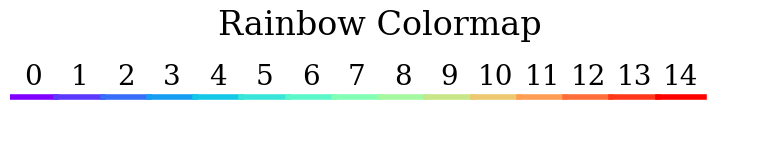

In [4]:
#make a list of 15 evenly spaced colours from the rainbow cmap to be used in all plots
cmap = plt.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 15)]
#show the colours
plt.figure(figsize=(8, 2))
for i, color in enumerate(colors):
    plt.plot([i, i + 1], [0, 0], color=color, lw=4)
#label each colour with its index
for i in range(len(colors)):
    plt.text(i + 0.5, 0.1, str(i), ha='center', va='bottom')
plt.xlim(0, len(colors) + 1)
plt.ylim(-1, 1)
plt.axis('off')
plt.title('Rainbow Colormap')
plt.tight_layout()

# Shared plot colors. Non-metallicity catalog-property plots use the green-to-red
# part of rainbow; metallicity plots use a separate blue-purple rainbow slice.
property_cmap = plt.get_cmap('rainbow')
property_color_positions = {
    'sum_A_V': 0.38,
    'L_Ha_sum_dered': 0.52,
    'ne_SII_cm3': 0.66,
    'logU_KK04': 0.76,
    'log_P_thermal_SII_over_k': 0.86,
    'radius_areaeq_pc': 0.94,
}
color_dic = {key: property_cmap(pos) for key, pos in property_color_positions.items()}
lf_comparison_colors = {
    'pre_dig': property_cmap(0.48),
    'dig_corrected': color_dic['L_Ha_sum_dered'],
}



In [5]:
# load in the latest HII region catalog
catalog_method = 'summed_map'  # options: integrated_spectrum, summed_map
catalog_dig_mode = 'dig_subtracted'  # options: dig_subtracted, no_dig
catalog_variant = 'combined'  # options: combined, metallicity, ionization_parameter, density, other_derived, clustering
primary_only = True
field_catalog_pattern = f"flux_catalogs/{catalog_method}/{catalog_dig_mode}/flux_catalog_{{FIELD}}.csv"

plot_root = Path("PAPER_PLOTS") / catalog_method / catalog_dig_mode
plot_root.mkdir(parents=True, exist_ok=True)

def paper_plot_path(filename, subdir=None):
    outdir = plot_root if subdir is None else plot_root / subdir
    outdir.mkdir(parents=True, exist_ok=True)
    return outdir / filename

def resolve_catalog_path(method, dig_mode, variant):
    base_dir = Path("CATALOGS") / "flux_catalogs" / method / dig_mode
    if variant == "combined":
        if hasattr(paths, "combined_catalog_csv"):
            return paths.combined_catalog_csv(method=method, dig_mode=dig_mode)
        return base_dir / "total_flux_catalog_combined.csv"
    if variant == "clustering":
        if hasattr(paths, "derived_catalog_csv"):
            return paths.derived_catalog_csv("clustering", method=method, dig_mode=dig_mode)
        return base_dir / "derived" / "total_flux_catalog_clustering.csv"
    if hasattr(paths, "derived_catalog_csv"):
        return paths.derived_catalog_csv(variant, method=method, dig_mode=dig_mode)
    return base_dir / "derived" / f"total_flux_catalog_{variant}.csv"

def load_catalog_with_field_fallback(method, dig_mode, variant):
    """Load the requested total catalog, or concatenate the available field catalogs."""
    cat_path = resolve_catalog_path(method, dig_mode, variant)
    if cat_path.exists():
        return pd.read_csv(cat_path), str(cat_path)

    base_dir = Path("CATALOGS") / "flux_catalogs" / method / dig_mode
    field_paths = sorted(base_dir.glob("flux_catalog_*.csv"))
    if not field_paths:
        raise FileNotFoundError(
            f"Could not find {cat_path} or any field catalogs in {base_dir}"
        )

    field_catalogs = []
    for field_path in field_paths:
        field_cat = pd.read_csv(field_path)
        if "field" not in field_cat.columns:
            field_cat["field"] = field_path.stem.removeprefix("flux_catalog_")
        field_catalogs.append(field_cat)

    source = f"{len(field_paths)} available field catalog(s) from {base_dir}"
    return pd.concat(field_catalogs, ignore_index=True, sort=False), source



def _sync_overlap_duplicate_flags_from_reference(df, method, selected_dig_mode, reference_dig_mode='dig_subtracted'):
    """Use one overlap-duplicate solution for all flux-correction catalog variants."""
    duplicate_cols = [
        'duplicate_group_id',
        'duplicate_group_size',
        'is_duplicate_overlap',
        'duplicate_peak_overlap',
        'duplicate_boundary_overlap',
        'duplicated',
        'primary',
        'primary_rank',
        'primary_region_id',
        'duplicate_score_sum_snr',
        'duplicate_score_min_snr',
        'duplicate_score_median_snr',
        'duplicate_score_finite_nlines',
    ]
    boundary_count = int(df.get('duplicate_boundary_overlap', pd.Series(False, index=df.index)).fillna(False).astype(bool).sum())
    if boundary_count > 0:
        return df
    if selected_dig_mode == reference_dig_mode:
        return df

    ref_path = Path('CATALOGS') / 'flux_catalogs' / method / reference_dig_mode / 'total_flux_catalog_combined.csv'
    if not ref_path.exists():
        print(f'Overlap duplicate reference catalog not found: {ref_path}')
        return df
    ref = pd.read_csv(ref_path)
    key_cols = ['field', 'region_id']
    if not set(key_cols).issubset(df.columns) or not set(key_cols).issubset(ref.columns):
        print('Cannot sync overlap duplicate flags because field/region_id keys are missing.')
        return df
    available_cols = [col for col in duplicate_cols if col in ref.columns]
    if not available_cols:
        print(f'No overlap duplicate columns found in reference catalog: {ref_path}')
        return df

    out = df.drop(columns=[col for col in available_cols if col in df.columns], errors='ignore')
    out = out.merge(ref[key_cols + available_cols], on=key_cols, how='left', validate='one_to_one')
    if 'primary' in out.columns:
        out['primary'] = out['primary'].fillna(True).astype(bool)
    new_boundary_count = int(out.get('duplicate_boundary_overlap', pd.Series(False, index=out.index)).fillna(False).astype(bool).sum())
    new_non_primary = int((~out['primary'].fillna(True).astype(bool)).sum()) if 'primary' in out.columns else 0
    print(
        f'Synced overlap duplicate flags from {ref_path}: '
        f'{new_boundary_count} boundary-overlap rows, {new_non_primary} non-primary rows.'
    )
    return out

cat, cat_source = load_catalog_with_field_fallback(catalog_method, catalog_dig_mode, catalog_variant)
cat = _sync_overlap_duplicate_flags_from_reference(cat, catalog_method, catalog_dig_mode)
cat_before_primary_filter = cat.copy()
pn_catalog_path = Path('CATALOGS/planetary_nebulae/M33_PNe_combined_deduplicated.csv')
if pn_catalog_path.exists():
    pn_catalog = pd.read_csv(pn_catalog_path)
    pn_hii_matches, cat = crossmatch_pne_to_hii_boundaries(cat, pn_catalog)
    pn_match_path = Path('CATALOGS/planetary_nebulae/M33_PNe_HII_region_crossmatch.csv')
    pn_match_path.parent.mkdir(parents=True, exist_ok=True)
    pn_hii_matches.to_csv(pn_match_path, index=False)
    pn_derived_path = Path('CATALOGS/flux_catalogs') / catalog_method / catalog_dig_mode / 'derived' / 'total_flux_catalog_pn_crossmatch.csv'
    pn_derived_path.parent.mkdir(parents=True, exist_ok=True)
    cat.to_csv(pn_derived_path, index=False)
    print(f'PN boundary crossmatch: {cat["has_pn_in_boundary"].sum()} HII regions contain at least one PN.')
else:
    pn_catalog = pd.DataFrame()
    print(f'PN catalog not found: {pn_catalog_path}')
if primary_only and 'primary' in cat.columns:
    n_before = len(cat)
    n_non_primary = int((~cat['primary'].fillna(True)).sum())
    cat = cat.loc[cat['primary'].fillna(True)].copy().reset_index(drop=True)
    print(f"Primary-only filtering enabled: removed {n_non_primary} non-primary duplicate rows; {len(cat)} / {n_before} rows kept.")
elif primary_only:
    print("Primary-only filtering requested, but no 'primary' column exists in this catalog.")

def positive_halpha_snr_catalog(df, label='catalog', quiet=False):
    snr_col = next((col for col in [
        'SNR_Halpha_sum',
        'SNR_Halpha_sum_nodig',
        'Halpha_SNR',
        'Halpha_SNR_raw',
        'Halpha_SNR_obs',
    ] if col in df.columns), None)
    if snr_col is None:
        raise KeyError('Cannot apply Halpha S/N > 0 catalog cut: no Halpha S/N column found.')
    snr_values = pd.to_numeric(df[snr_col], errors='coerce')
    out = df.loc[snr_values > 0].copy().reset_index(drop=True)
    if not quiet:
        print(f'Halpha S/N > 0 filtering for {label} using {snr_col}: kept {len(out)} / {len(df)} rows.')
    return out

# Keep only regions with positive observed Halpha signal-to-noise.
cat = positive_halpha_snr_catalog(cat, label='notebook 8a plotting catalog')

print(f"Catalog loaded from {cat_source} with {len(cat.columns)} columns.")
print(f"Plots will be saved under {plot_root}")
for col in cat.columns:
    print(col)


PN boundary crossmatch: 85 HII regions contain at least one PN.
Primary-only filtering enabled: removed 521 non-primary duplicate rows; 5902 / 6423 rows kept.
Halpha S/N > 0 filtering for notebook 8a plotting catalog using SNR_Halpha_sum: kept 5893 / 5902 rows.
Catalog loaded from /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/flux_catalogs/summed_map/dig_subtracted/total_flux_catalog_combined.csv with 493 columns.
Plots will be saved under PAPER_PLOTS/summed_map/dig_subtracted
region_id
npix_region
npix_dig_annulus
dig_annulus_inner_px
dig_annulus_width_px
dig_annulus_outer_px
dig_annulus_source
F_Halpha_sum_nodig
F_Halpha_e_sum_nodig
SNR_Halpha_sum_nodig
Halpha_dig_median
Halpha_dig_local_median
Halpha_dig_method
Halpha_dig_mad
Halpha_dig_clip_upper
Halpha_dig_npix
Halpha_dig_npix_used
Halpha_dig_model_sum
Halpha_dig_subtracted_sum
Halpha_dig_fraction_raw
Halpha_dig_background_smooth_sigma_px
Halpha_dig_max_subtraction_fraction
F_Halpha_sum_digsub
F_Hbeta_sum_nodig
F_Hbeta_e

In [6]:
# Star-forming region definition used throughout this notebook.
# Change this one block, then rerun the notebook to switch the selection.
#
# Examples:
#   STAR_FORMING_DEFINITION = {"mode": "bpt"}
#   STAR_FORMING_DEFINITION = {"mode": "sii_ha", "sii_ha_max": 0.4}
#
# For sii_ha mode, sii_ha_max is the linear ratio
# ([SII]6716 + [SII]6731) / Halpha.
STAR_FORMING_DEFINITION = {
    "mode": "bpt",             # options: "bpt", "sii_ha"
    "sii_ha_max": 0.4,      # used only when mode == "sii_ha"
}
STAR_FORMING_SNR_CUT = 3.0


def _first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _numeric_column(df, candidates):
    col = _first_present_column(df, candidates)
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float), col


def _selected_sii_ha_ratio(df):
    ha, ha_col = _numeric_column(df, [
        "F_Halpha_sum_dered",
        "F_Halpha_sum_digsub",
        "F_Halpha_sum",
        "F_Halpha_sum_nodig",
    ])
    sii6716, sii6716_col = _numeric_column(df, [
        "F_[SII]6716_sum_dered",
        "F_[SII]6716_sum_digsub",
        "F_[SII]6716_sum",
        "F_[SII]6716_sum_nodig",
    ])
    sii6731, sii6731_col = _numeric_column(df, [
        "F_[SII]6731_sum_dered",
        "F_[SII]6731_sum_digsub",
        "F_[SII]6731_sum",
        "F_[SII]6731_sum_nodig",
    ])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (sii6716 + sii6731) / ha
    ratio = np.where(np.isfinite(ratio) & (ha > 0) & (sii6716 > 0) & (sii6731 > 0), ratio, np.nan)
    return ratio, {"Halpha": ha_col, "SII6716": sii6716_col, "SII6731": sii6731_col}


def selected_star_forming_mask(df, definition=None):
    definition = dict(STAR_FORMING_DEFINITION if definition is None else definition)
    mode = str(definition.get("mode", "bpt")).strip().lower()
    if mode == "bpt":
        if "BPT_class_sum_dered" not in df.columns:
            return np.zeros(len(df), dtype=bool)
        return df["BPT_class_sum_dered"].astype(str).str.strip().eq("Star-forming").to_numpy(dtype=bool)
    if mode == "sii_ha":
        ratio, _ = _selected_sii_ha_ratio(df)
        max_ratio = float(definition.get("sii_ha_max", 0.4))
        return np.isfinite(ratio) & (ratio < max_ratio)
    raise ValueError(f"Unknown STAR_FORMING_DEFINITION mode: {mode!r}")


def selected_star_forming_snr_mask(df, snr_cut=None, definition=None):
    snr_cut = STAR_FORMING_SNR_CUT if snr_cut is None else snr_cut
    if "all_lines_snr_mask" in globals():
        snr_mask = all_lines_snr_mask(df, snr_cut=snr_cut)
    elif "_all_bpt_lines_snr_mask_for_plotting" in globals():
        snr_mask = _all_bpt_lines_snr_mask_for_plotting(df, snr_cut=snr_cut)
    else:
        snr_cols = [
            "SNR_Halpha_sum",
            "SNR_Hbeta_sum",
            "SNR_[OIII]5007_sum",
            "SNR_[SII]6716_sum",
            "SNR_[NII]6583_sum",
        ]
        snr_mask = np.ones(len(df), dtype=bool)
        for col in snr_cols:
            if col not in df.columns:
                snr_mask &= False
            else:
                snr_mask &= pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float) > snr_cut
    primary = df["primary"].fillna(True).astype(bool).to_numpy() if "primary" in df.columns else np.ones(len(df), dtype=bool)
    return selected_star_forming_mask(df, definition=definition) & snr_mask & primary


def star_forming_definition_label(definition=None):
    definition = dict(STAR_FORMING_DEFINITION if definition is None else definition)
    mode = str(definition.get("mode", "bpt")).strip().lower()
    if mode == "bpt":
        return "BPT star-forming"
    if mode == "sii_ha":
        return rf"[SII]/H$\alpha$ < {float(definition.get('sii_ha_max', 0.4)):.2f}"
    return mode

cat["selected_star_forming"] = selected_star_forming_mask(cat)
cat["selected_star_forming_snr"] = selected_star_forming_snr_mask(cat, snr_cut=STAR_FORMING_SNR_CUT)
print(f"Star-forming definition: {star_forming_definition_label()}")
print(f"Selected star-forming regions: {int(cat['selected_star_forming'].sum())} / {len(cat)}")
print(f"Selected star-forming regions with all-line S/N > {STAR_FORMING_SNR_CUT:g}: {int(cat['selected_star_forming_snr'].sum())} / {len(cat)}")



Star-forming definition: BPT star-forming
Selected star-forming regions: 5134 / 5893
Selected star-forming regions with all-line S/N > 3: 4578 / 5893


In [7]:
# Derived BPT diagnostic columns for testing alternate star-forming definitions.
# The high-OIII population is defined as primary, high-S/N, above the Kauffmann+03 line,
# and not currently BPT-classified as star-forming.
BPT_DIAGNOSTIC_SNR_CUT = 3.0
BPT_DIAGNOSTIC_SNR_LINES = [
    'Halpha',
    'Hbeta',
    '[OIII]5007',
    '[NII]6583',
    '[SII]6716',
    '[SII]6731',
    '[OII]3727',
]


def _diag_first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _diag_numeric_column(df, candidates):
    col = _diag_first_present_column(df, candidates)
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col


def _diag_flux(df, line_name):
    return _diag_numeric_column(df, [
        f'F_{line_name}_sum_dered',
        f'F_{line_name}_sum_digsub',
        f'F_{line_name}_sum',
        f'F_{line_name}_sum_nodig',
    ])


def _diag_snr(df, line_name):
    return _diag_numeric_column(df, [
        f'SNR_{line_name}_sum',
        f'SNR_{line_name}_sum_nodig',
    ])


def _diag_log_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.log10(num / den)
    return np.where(np.isfinite(out) & (num > 0) & (den > 0), out, np.nan)


def _diag_all_line_snr_mask(df, threshold, line_names=BPT_DIAGNOSTIC_SNR_LINES):
    masks = []
    snr_sources = {}
    for line_name in line_names:
        snr_values, snr_col = _diag_snr(df, line_name)
        snr_sources[line_name] = snr_col
        masks.append(np.isfinite(snr_values) & (snr_values > threshold))
    if not masks:
        return np.zeros(len(df), dtype=bool), snr_sources
    return np.logical_and.reduce(masks), snr_sources


def _category_counts(series):
    return series.value_counts(dropna=False).to_dict()


def add_bpt_diagnostic_columns(df, snr_cut=BPT_DIAGNOSTIC_SNR_CUT):
    out = df.copy()
    ha, _ = _diag_flux(out, 'Halpha')
    hb, _ = _diag_flux(out, 'Hbeta')
    oiii, _ = _diag_flux(out, '[OIII]5007')
    oii, _ = _diag_flux(out, '[OII]3727')
    nii, _ = _diag_flux(out, '[NII]6583')
    sii6716, _ = _diag_flux(out, '[SII]6716')
    sii6731, _ = _diag_flux(out, '[SII]6731')
    sii = sii6716 + sii6731

    out['sii_halpha_ratio'] = np.where(np.isfinite(sii / ha) & (sii > 0) & (ha > 0), sii / ha, np.nan)
    out['log_SII_Halpha'] = _diag_log_ratio(sii, ha)
    out['log_NII_Halpha'] = _diag_log_ratio(nii, ha)
    out['log_OIII_OII'] = _diag_log_ratio(oiii, oii)
    out['log_OIII_Halpha'] = _diag_log_ratio(oiii, ha)
    out['log_OIII_Hbeta'] = _diag_log_ratio(oiii, hb)

    with np.errstate(divide='ignore', invalid='ignore'):
        kauffmann_y = 0.61 / (out['log_NII_Halpha'].to_numpy(dtype=float) - 0.05) + 1.3
    x_nii = out['log_NII_Halpha'].to_numpy(dtype=float)
    y_oiii = out['log_OIII_Hbeta'].to_numpy(dtype=float)
    above_kauffmann = np.isfinite(x_nii) & np.isfinite(y_oiii) & ((x_nii >= 0.05) | (y_oiii > kauffmann_y))
    out['above_kauffmann_nii_bpt'] = above_kauffmann

    snr3_all, snr_sources = _diag_all_line_snr_mask(out, snr_cut)
    snr30_all, _ = _diag_all_line_snr_mask(out, 30.0)
    snr50_all, _ = _diag_all_line_snr_mask(out, 50.0)
    out['snr3_all_lines'] = snr3_all
    out['snr30_all_lines'] = snr30_all
    out['snr50_all_lines'] = snr50_all
    out['high_snr_nii_bpt'] = snr3_all

    primary = out['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in out.columns else np.ones(len(out), dtype=bool)
    bpt_sf = out['BPT_class_sum_dered'].astype(str).str.strip().eq('Star-forming').to_numpy() if 'BPT_class_sum_dered' in out.columns else np.zeros(len(out), dtype=bool)
    out['bpt_sf_snr3_all_lines'] = primary & snr3_all & bpt_sf
    out['snr3_non_bpt_sf'] = primary & snr3_all & ~bpt_sf
    out['snr50_non_bpt_sf'] = primary & snr50_all & ~bpt_sf
    out['high_snr_above_kauffmann_non_sf'] = primary & snr3_all & above_kauffmann & ~bpt_sf

    recovered_siiha = primary & snr30_all & ~bpt_sf & np.isfinite(out['sii_halpha_ratio']) & (out['sii_halpha_ratio'] < 0.6)
    out['custom_sf_bpt_or_siiha'] = out['bpt_sf_snr3_all_lines'] | recovered_siiha
    out['custom_sf_recovered_siiha'] = recovered_siiha

    out['class_snr3_only'] = np.where(primary & snr3_all, 'snr3_all_lines', 'low_snr')
    out['class_bpt_snr3_nonbpt'] = np.select(
        [out['bpt_sf_snr3_all_lines'], out['snr3_non_bpt_sf']],
        ['bpt_sf_snr3', 'snr3_non_bpt_sf'],
        default='low_snr',
    )
    out['class_bpt_snr3_nonbpt_snr50'] = np.select(
        [out['bpt_sf_snr3_all_lines'], out['snr50_non_bpt_sf'], out['snr3_non_bpt_sf']],
        ['bpt_sf_snr3', 'snr50_non_bpt_sf', 'snr3_non_bpt_sf'],
        default='low_snr',
    )
    out['class_custom_sf'] = np.select(
        [out['bpt_sf_snr3_all_lines'], out['custom_sf_recovered_siiha'], primary & snr3_all],
        ['bpt_sf_snr3', 'recovered_siiha_sf', 'snr3_non_custom_sf'],
        default='low_snr',
    )

    out.attrs['bpt_diagnostic_snr_sources'] = snr_sources
    return out


cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)
print(f"S/N>3 all-line regions: {int(cat['snr3_all_lines'].sum())}")
print(f"BPT SF with S/N>3 all lines: {int(cat['bpt_sf_snr3_all_lines'].sum())}")
print(f"S/N>3 all lines but not BPT SF: {int(cat['snr3_non_bpt_sf'].sum())}")
print(f"S/N>50 all lines and not BPT SF: {int(cat['snr50_non_bpt_sf'].sum())}")
print(f"Recovered SII/Halpha SF candidates: {int(cat['custom_sf_recovered_siiha'].sum())}")
print(f"High-S/N, above-Kauffmann, non-SF regions: {int(cat['high_snr_above_kauffmann_non_sf'].sum())}")
print('S/N columns used:', cat.attrs.get('bpt_diagnostic_snr_sources', {}))



S/N>3 all-line regions: 4417
BPT SF with S/N>3 all lines: 4030
S/N>3 all lines but not BPT SF: 387
S/N>50 all lines and not BPT SF: 53
Recovered SII/Halpha SF candidates: 76
High-S/N, above-Kauffmann, non-SF regions: 387
S/N columns used: {'Halpha': 'SNR_Halpha_sum', 'Hbeta': 'SNR_Hbeta_sum', '[OIII]5007': 'SNR_[OIII]5007_sum', '[NII]6583': 'SNR_[NII]6583_sum', '[SII]6716': 'SNR_[SII]6716_sum', '[SII]6731': 'SNR_[SII]6731_sum', '[OII]3727': 'SNR_[OII]3727_sum'}


In [8]:
# High-S/N above-Kauffmann regions with compact-object hosts removed.
# Used for the paper mosaic blue contours, BPT outlines, and S/N diagnostic scatter plots.
HIGH_BPT_HALPHA_SNR_CUT = 60.0
EXTRA_SF_COMPACT_DISTANCE_CUT_PIX = 40.0
EXTRA_SF_SIZE_PERCENTILE = 5.0
EXTRA_SF_SIGMA_PERCENTILE = 95.0
EXTRA_SF_COUNT_COMMAND = 'nExtraSFHighBPTClean'
EXTRA_SF_FINAL_COUNT_COMMAND = 'nSFFinal'
EXTRA_SF_CUTFLOW_COMMANDS = {
    'above_kauffmann': 'nExtraSFAboveKauffmann',
    'removed_low_halpha_snr': 'nExtraSFRemovedLowHalphaSNR',
    'removed_bpt_sf': 'nExtraSFRemovedBPTSF',
    'removed_boundary_compact': 'nExtraSFRemovedBoundaryCompact',
    'removed_near_compact_boundary': 'nExtraSFRemovedNearCompactBoundary',
    'removed_small_size': 'nExtraSFRemovedSmallSize',
    'removed_high_sigma': 'nExtraSFRemovedHighSigma',
}
HIGH_BPT_MAP_SCATTER_OUTPUT_DIR = Path('bpt_comparison') / 'high_bpt_regions'
HIGH_BPT_MAP_SCATTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HIGH_BPT_BLUE = 'dodgerblue'
M33_DISTANCE_PC = 840_000.0


def _high_bpt_bool_flag(df, col):
    if col not in df.columns:
        return np.zeros(len(df), dtype=bool)
    series = df[col]
    if series.dtype == bool:
        return series.fillna(False).to_numpy(dtype=bool)
    return series.fillna(False).astype(str).str.strip().str.lower().isin({'true', '1', 'yes', 'y'}).to_numpy(dtype=bool)


def _high_bpt_first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _high_bpt_numeric(df, col):
    if col is None or col not in df.columns:
        return np.full(len(df), np.nan, dtype=float)
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)


def _extra_sf_wr_coord_from_name(name):
    match = re.match(
        r'J(?P<rah>\d{2})(?P<ram>\d{2})(?P<ras>\d{2}(?:\.\d+)?)(?P<sign>[+-])(?P<decd>\d{2})(?P<decm>\d{2})(?P<decs>\d{2}(?:\.\d+)?)',
        str(name).strip(),
    )
    if match is None:
        return None
    ra = f"{match.group('rah')}h{match.group('ram')}m{match.group('ras')}s"
    dec = f"{match.group('sign')}{match.group('decd')}d{match.group('decm')}m{match.group('decs')}s"
    return SkyCoord(ra, dec, frame='icrs')


def _extra_sf_compact_coords(catalog, kind):
    if catalog is None or len(catalog) == 0:
        return None
    if kind == 'pn' and {'RA_deg', 'Dec_deg'}.issubset(catalog.columns):
        return SkyCoord(
            pd.to_numeric(catalog['RA_deg'], errors='coerce').to_numpy(dtype=float) * u.deg,
            pd.to_numeric(catalog['Dec_deg'], errors='coerce').to_numpy(dtype=float) * u.deg,
            frame='icrs',
        )
    if kind == 'snr' and {'RA', 'Dec'}.issubset(catalog.columns):
        valid = catalog['RA'].notna() & catalog['Dec'].notna()
        if not valid.any():
            return None
        return SkyCoord(
            catalog.loc[valid, 'RA'].astype(str).to_numpy(),
            catalog.loc[valid, 'Dec'].astype(str).to_numpy(),
            unit=(u.hourangle, u.deg),
            frame='icrs',
        )
    if kind == 'wr' and 'Name (star)' in catalog.columns:
        coords = [_extra_sf_wr_coord_from_name(name) for name in catalog['Name (star)']]
        coords = [coord for coord in coords if coord is not None]
        if not coords:
            return None
        return SkyCoord(coords)
    return None


def _extra_sf_min_projected_distance_pc(region_coords, compact_coords):
    if compact_coords is None or len(compact_coords) == 0:
        return np.full(len(region_coords), np.nan, dtype=float)
    _, sep2d, _ = region_coords.match_to_catalog_sky(compact_coords)
    return sep2d.radian * M33_DISTANCE_PC



def _extra_sf_boundary_compact_distance_pix(
    df,
    wr_catalog_for_distance=None,
    snr_catalog_for_distance=None,
    pn_catalog_for_distance=None,
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    wcs_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
):
    """Minimum pixel distance from any compact object to each region footprint.

    This uses the same per-field boundary label maps that are drawn on the mosaic.
    A compact object inside the region has distance 0; an object just outside the
    contour is measured to the nearest region pixel, which approximates distance
    to the plotted boundary in field pixels.
    """
    from scipy.spatial import cKDTree
    distances = np.full(len(df), np.nan, dtype=float)
    if len(df) == 0 or not {'field', 'region_id'}.issubset(df.columns):
        return distances

    coord_arrays = []
    for coords in [
        _extra_sf_compact_coords(wr_catalog_for_distance, 'wr'),
        _extra_sf_compact_coords(snr_catalog_for_distance, 'snr'),
        _extra_sf_compact_coords(pn_catalog_for_distance, 'pn'),
    ]:
        if coords is not None and len(coords) > 0:
            coord_arrays.extend(list(coords))
    if not coord_arrays:
        return distances
    compact_coords = SkyCoord(coord_arrays)

    for field in pd.Series(df['field']).dropna().astype(str).unique():
        field_rows = df.index[df['field'].astype(str) == field].to_numpy()
        if field_rows.size == 0:
            continue
        field_numeric = field[1:] if field.startswith('F') else field
        boundary_candidates = [
            Path(boundary_dir) / boundary_pattern.format(FIELD=field),
            Path(boundary_dir) / boundary_pattern.format(FIELD=field_numeric),
        ]
        wcs_candidates = [
            Path(wcs_dir) / wcs_pattern.format(FIELD=field),
            Path(wcs_dir) / wcs_pattern.format(FIELD=field_numeric),
        ]
        boundary_path = next((path for path in boundary_candidates if path.exists()), None)
        wcs_path = next((path for path in wcs_candidates if path.exists()), None)
        if boundary_path is None or wcs_path is None:
            continue

        label_map = fits.getdata(boundary_path)
        wcs = WCS(fits.getheader(wcs_path)).celestial
        xpix, ypix = wcs.world_to_pixel(compact_coords)
        compact_xy = np.column_stack([ypix, xpix])
        finite_compact = np.isfinite(compact_xy).all(axis=1)
        if not np.any(finite_compact):
            continue
        compact_xy = compact_xy[finite_compact]

        for row_idx in field_rows:
            try:
                region_id = int(df.at[row_idx, 'region_id'])
            except Exception:
                continue
            mask = label_map == region_id
            if not np.any(mask):
                continue
            y_region, x_region = np.nonzero(mask)
            region_xy = np.column_stack([y_region, x_region])
            tree = cKDTree(region_xy)
            dist_pix, _ = tree.query(compact_xy, k=1)
            if dist_pix.size:
                distances[row_idx] = float(np.nanmin(dist_pix))

    return distances


def add_high_bpt_no_compact_columns(
    df,
    halpha_snr_cut=HIGH_BPT_HALPHA_SNR_CUT,
    compact_distance_cut_pix=EXTRA_SF_COMPACT_DISTANCE_CUT_PIX,
    size_percentile=EXTRA_SF_SIZE_PERCENTILE,
    sigma_percentile=EXTRA_SF_SIGMA_PERCENTILE,
    wr_catalog_for_distance=None,
    snr_catalog_for_distance=None,
    pn_catalog_for_distance=None,
):
    out = df.copy()
    halpha_snr_col = _high_bpt_first_present_column(out, ['SNR_Halpha_sum', 'SNR_Halpha_sum_nodig', 'Halpha_SNR'])
    if halpha_snr_col is None:
        raise KeyError('No Halpha S/N column found for high-BPT diagnostics.')
    halpha_snr = _high_bpt_numeric(out, halpha_snr_col)
    compact_host = (
        _high_bpt_bool_flag(out, 'has_wr_in_boundary') |
        _high_bpt_bool_flag(out, 'has_snr_in_boundary') |
        _high_bpt_bool_flag(out, 'has_pn_in_boundary')
    )
    primary = out['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in out.columns else np.ones(len(out), dtype=bool)
    if 'above_kauffmann_nii_bpt' in out.columns:
        above_kauffmann = out['above_kauffmann_nii_bpt'].fillna(False).astype(bool).to_numpy()
    else:
        x = _high_bpt_numeric(out, 'log_NII_Halpha')
        y = _high_bpt_numeric(out, 'log_OIII_Hbeta')
        with np.errstate(divide='ignore', invalid='ignore'):
            kauffmann_y = 0.61 / (x - 0.05) + 1.3
        above_kauffmann = np.isfinite(x) & np.isfinite(y) & ((x >= 0.05) | (y > kauffmann_y))
    sf_mask = out['bpt_sf_snr3_all_lines'].fillna(False).astype(bool).to_numpy() if 'bpt_sf_snr3_all_lines' in out.columns else np.zeros(len(out), dtype=bool)
    high_mask = primary & (~compact_host) & (~sf_mask) & above_kauffmann & np.isfinite(halpha_snr) & (halpha_snr > halpha_snr_cut)

    if wr_catalog_for_distance is None:
        wr_catalog_for_distance = globals().get('wr_catalog', None)
        if wr_catalog_for_distance is None:
            try:
                wr_catalog_for_distance = load_wr_catalog()
            except Exception:
                wr_catalog_for_distance = pd.DataFrame()
    if snr_catalog_for_distance is None:
        snr_catalog_for_distance = globals().get('snr_catalog', None)
        if snr_catalog_for_distance is None:
            try:
                snr_catalog_for_distance = load_snr_catalog()
            except Exception:
                snr_catalog_for_distance = pd.DataFrame()
    if pn_catalog_for_distance is None:
        pn_catalog_for_distance = globals().get('pn_catalog', pd.DataFrame())

    if {'RA_deg', 'Dec_deg'}.issubset(out.columns):
        region_coords = SkyCoord(
            pd.to_numeric(out['RA_deg'], errors='coerce').to_numpy(dtype=float) * u.deg,
            pd.to_numeric(out['Dec_deg'], errors='coerce').to_numpy(dtype=float) * u.deg,
            frame='icrs',
        )
        wr_dist = _extra_sf_min_projected_distance_pc(region_coords, _extra_sf_compact_coords(wr_catalog_for_distance, 'wr'))
        snr_dist = _extra_sf_min_projected_distance_pc(region_coords, _extra_sf_compact_coords(snr_catalog_for_distance, 'snr'))
        pn_dist = _extra_sf_min_projected_distance_pc(region_coords, _extra_sf_compact_coords(pn_catalog_for_distance, 'pn'))
    else:
        wr_dist = snr_dist = pn_dist = np.full(len(out), np.nan, dtype=float)

    dist_stack = np.vstack([
        np.where(np.isfinite(wr_dist), wr_dist, np.inf),
        np.where(np.isfinite(snr_dist), snr_dist, np.inf),
        np.where(np.isfinite(pn_dist), pn_dist, np.inf),
    ])
    nearest_compact_pc = np.nanmin(dist_stack, axis=0)
    nearest_compact_pc = np.where(np.isfinite(nearest_compact_pc), nearest_compact_pc, np.nan)
    nearest_compact_boundary_pix = _extra_sf_boundary_compact_distance_pix(
        out,
        wr_catalog_for_distance=wr_catalog_for_distance,
        snr_catalog_for_distance=snr_catalog_for_distance,
        pn_catalog_for_distance=pn_catalog_for_distance,
    )
    far_from_compact = (~np.isfinite(nearest_compact_boundary_pix)) | (nearest_compact_boundary_pix >= compact_distance_cut_pix)

    size_col = _high_bpt_first_present_column(out, ['radius_areaeq_pc', 'Rc_pc', 'region_radius_pc', 'radius_pc'])
    sigma_col = _high_bpt_first_present_column(out, ['sigma_mean_kms', 'velocity_dispersion_kms', 'sigma_kms'])
    size = _high_bpt_numeric(out, size_col)
    sigma = _high_bpt_numeric(out, sigma_col)
    size_finite = np.isfinite(size)
    sigma_finite = np.isfinite(sigma)
    size_cut = np.nanpercentile(size[size_finite], size_percentile) if np.any(size_finite) else np.nan
    sigma_cut = np.nanpercentile(sigma[sigma_finite], sigma_percentile) if np.any(sigma_finite) else np.nan
    not_small = np.isfinite(size) & ((~np.isfinite(size_cut)) | (size >= size_cut))
    not_high_sigma = np.isfinite(sigma) & ((~np.isfinite(sigma_cut)) | (sigma <= sigma_cut))

    above_kauffmann_base = primary & above_kauffmann
    high_halpha_snr = np.isfinite(halpha_snr) & (halpha_snr > halpha_snr_cut)
    step_after_snr = above_kauffmann_base & high_halpha_snr
    step_after_not_bpt_sf = step_after_snr & (~sf_mask)
    step_after_boundary_compact = step_after_not_bpt_sf & (~compact_host)
    step_after_boundary_distance = step_after_boundary_compact & far_from_compact
    step_after_size = step_after_boundary_distance & not_small
    clean_high_mask = step_after_size & not_high_sigma
    high_mask = step_after_boundary_compact
    cutflow = {
        'above_kauffmann': int(above_kauffmann_base.sum()),
        'removed_low_halpha_snr': int((above_kauffmann_base & ~high_halpha_snr).sum()),
        'removed_bpt_sf': int((step_after_snr & sf_mask).sum()),
        'removed_boundary_compact': int((step_after_not_bpt_sf & compact_host).sum()),
        'removed_near_compact_boundary': int((step_after_boundary_compact & ~far_from_compact).sum()),
        'removed_small_size': int((step_after_boundary_distance & ~not_small).sum()),
        'removed_high_sigma': int((step_after_size & ~not_high_sigma).sum()),
    }

    out['high_bpt_no_compact'] = high_mask
    out['nearest_wr_pc'] = wr_dist
    out['nearest_snr_pc'] = snr_dist
    out['nearest_pn_pc'] = pn_dist
    out['nearest_compact_pc'] = nearest_compact_pc
    out['nearest_compact_boundary_pix'] = nearest_compact_boundary_pix
    out['extra_sf_high_bpt_clean'] = clean_high_mask
    out['extra_sf_region_size_col'] = size_col
    out['extra_sf_sigma_col'] = sigma_col
    out['extra_sf_region_size_p05_pc'] = size_cut
    out['extra_sf_sigma_p95_kms'] = sigma_cut
    out.attrs['extra_sf_cutflow'] = cutflow
    out['high_bpt_halpha_snr_col'] = halpha_snr_col
    out['mosaic_sf_high_bpt_category'] = np.select(
        [clean_high_mask, sf_mask],
        ['extra_sf_high_bpt_clean', 'bpt_sf_snr3'],
        default='other',
    )
    return out, halpha_snr_col


cat, high_bpt_halpha_snr_col = add_high_bpt_no_compact_columns(cat)
high_bpt_base_count = int(cat['high_bpt_no_compact'].sum())
extra_sf_high_bpt_clean_count = int(cat['extra_sf_high_bpt_clean'].sum())
extra_sf_cutflow_values = dict(cat.attrs.get('extra_sf_cutflow', {}))
extra_sf_bpt_sf_snr3_count = int(cat['bpt_sf_snr3_all_lines'].fillna(False).astype(bool).sum()) if 'bpt_sf_snr3_all_lines' in cat.columns else 0
extra_sf_final_sf_count = extra_sf_bpt_sf_snr3_count + extra_sf_high_bpt_clean_count
if 'values' in globals() and 'nStarformingSNRThree' in values:
    extra_sf_final_sf_count = int(values['nStarformingSNRThree']) + extra_sf_high_bpt_clean_count
extra_sf_size_cut_pc = float(cat['extra_sf_region_size_p05_pc'].iloc[0]) if len(cat) else np.nan
extra_sf_sigma_cut_kms = float(cat['extra_sf_sigma_p95_kms'].iloc[0]) if len(cat) else np.nan
print(
    f"High-S/N above-Kauffmann no-boundary-WR/SNR/PN regions: "
    f"{high_bpt_base_count} using {high_bpt_halpha_snr_col} > {HIGH_BPT_HALPHA_SNR_CUT:.0f}."
)
print(
    f"Clean extra-SF high-BPT subset: {extra_sf_high_bpt_clean_count} regions "
    f"after nearest compact object to region footprint >= {EXTRA_SF_COMPACT_DISTANCE_CUT_PIX:.0f} pixels, "
    f"size >= P{EXTRA_SF_SIZE_PERCENTILE:.0f} ({extra_sf_size_cut_pc:.2f} pc), "
    f"and sigma <= P{EXTRA_SF_SIGMA_PERCENTILE:.0f} ({extra_sf_sigma_cut_kms:.2f} km/s)."
)
if 'values' in globals() and 'formats' in globals():
    values[EXTRA_SF_COUNT_COMMAND] = extra_sf_high_bpt_clean_count
    formats[EXTRA_SF_COUNT_COMMAND] = 'd'
    extra_sf_final_sf_count = int(values.get('nStarformingSNRThree', extra_sf_bpt_sf_snr3_count)) + extra_sf_high_bpt_clean_count
    values[EXTRA_SF_FINAL_COUNT_COMMAND] = extra_sf_final_sf_count
    formats[EXTRA_SF_FINAL_COUNT_COMMAND] = 'd'
    for cut_name, command_name in EXTRA_SF_CUTFLOW_COMMANDS.items():
        values[command_name] = int(extra_sf_cutflow_values.get(cut_name, 0))
        formats[command_name] = 'd'
    write_number_command_files(values, formats, message='Updated clean extra-SF high-BPT count and cutflow')


High-S/N above-Kauffmann no-WR/SNR/PN regions: 330 using SNR_Halpha_sum > 30.


In [9]:
# save the catalog to a latex table

In [10]:
# load in the WR and SNR catalogs
wr_catalog = load_wr_catalog()
snr_catalog = load_snr_catalog()


In [11]:
# Initialize values that will be extended with fit results later in the notebook.
values, formats = build_catalog_number_values(cat, snr_cut=3)
duplicate_numbers_cat = positive_halpha_snr_catalog(
    cat_before_primary_filter,
    label='catalog_numbers duplicate-region catalog',
    quiet=True,
)
add_duplicate_region_values(values, duplicate_numbers_cat)
if 'extra_sf_high_bpt_clean' in cat.columns:
    values[EXTRA_SF_COUNT_COMMAND] = int(cat['extra_sf_high_bpt_clean'].fillna(False).astype(bool).sum())
    formats[EXTRA_SF_COUNT_COMMAND] = 'd'
    values[EXTRA_SF_FINAL_COUNT_COMMAND] = int(values.get('nStarformingSNRThree', 0)) + values[EXTRA_SF_COUNT_COMMAND]
    formats[EXTRA_SF_FINAL_COUNT_COMMAND] = 'd'
    for cut_name, command_name in EXTRA_SF_CUTFLOW_COMMANDS.items():
        values[command_name] = int(globals().get('extra_sf_cutflow_values', {}).get(cut_name, 0))
        formats[command_name] = 'd'


def write_number_command_files(values, formats, message=None):
    """Write the current paper number commands to both supported filenames."""
    catalog_numbers_path = paper_plot_path('catalog_numbers.tex')
    paper_numbers_path = paper_plot_path('paper_numbers.tex')
    write_latex_commands(catalog_numbers_path, values, formats)
    write_latex_commands(paper_numbers_path, values, formats)
    if message is None:
        message = f'Wrote {len(values)} auto-generated commands'
    print(f'{message}: {catalog_numbers_path}')
    print(f'{message}: {paper_numbers_path}')
    return catalog_numbers_path, paper_numbers_path
if {'has_snr_in_boundary', 'has_wr_in_boundary'}.issubset(cat.columns):
    snr_hosts = cat['has_snr_in_boundary'].fillna(False).astype(bool)
    wr_hosts = cat['has_wr_in_boundary'].fillna(False).astype(bool)
    values['nRegionsContainingSNR'] = int(snr_hosts.sum())
    values['nRegionsContainingWR'] = int(wr_hosts.sum())
    values['nRegionsContainingSNRAndWR'] = int((snr_hosts & wr_hosts).sum())
    values['nRegionsContainingSNROrWR'] = int((snr_hosts | wr_hosts).sum())
if 'n_pn_in_boundary' in cat.columns:
    values['nCrossMatchedPN'] = int(pd.to_numeric(cat['n_pn_in_boundary'], errors='coerce').fillna(0).sum())
radial_gradient_fit_results = {}

print("\nCatalog and peak-removal commands initialized:")
for k in values:
    print(f"\\{k} = {format_value(values[k], formats.get(k))}")



Catalog and peak-removal commands initialized:
\nregions = 5893
\nstarforming = 5134
\ncomposite = 288
\nagn = 248
\nUnclassified = 223
\nregionssnrthree = 5017
\nStarformingSNRThree = 4578
\nCompositeSNRThree = 252
\nAgnSNRThree = 187
\nregionsdensity = 3227
\nRegionsContainingSNR = 49
\nRegionsContainingWR = 24
\nRegionsContainingSNRAndWR = 3
\nRegionsContainingSNROrWR = 70
\nRegionsContainingPN = 81
\nCrossMatchedPN = 83
\nlogLHa = 5807
\medianlogLHa = 35.70
\pfivelogLHa = 34.85
\psixteenlogLHa = 35.18
\ptwentyfivelogLHa = 35.34
\pseventyfivelogLHa = 36.13
\peightyfourlogLHa = 36.38
\pninetyfivelogLHa = 36.96
\minlogLHa = 32.53
\maxlogLHa = 40.43
\nradiuspfifty = 5893
\medianradiuspfifty = 10.73
\pfiveradiuspfifty = 5.27
\psixteenradiuspfifty = 7.66
\ptwentyfiveradiuspfifty = 8.23
\pseventyfiveradiuspfifty = 13.78
\peightyfourradiuspfifty = 15.54
\pninetyfiveradiuspfifty = 19.44
\minradiuspfifty = 2.58
\maxradiuspfifty = 40.10
\nradiuspsixteen = 5893
\medianradiuspsixteen = 7.91
\p

In [12]:

# Functions to plot each map with boundaries colored by BPT class, and WR/SNR locations overlaid.

def field_to_fieldnum(field_label: str) -> str:
    """
    Map your plot field labels to WR catalog Field codes.
    Input examples: 'NE','NW','SE','SW','F5'...'F9'
    Output: 'F1'...'F9'
    """
    mapping = {"NE": "F1", "NW": "F2", "SE": "F3", "SW": "F4"}
    return mapping.get(field_label, field_label)  # F5->F5 etc.


def parse_name_to_coords(name: str) -> SkyCoord:
    # Example: 'J013307.80+302951.1'
    ra_h = name[1:3]
    ra_m = name[3:5]
    ra_s = name[5:10]
    dec_sign = name[10]
    dec_d = name[11:13]
    dec_m = name[13:15]
    dec_s = name[15:]
    ra_str = f"{ra_h}h{ra_m}m{ra_s}s"
    dec_str = f"{dec_sign}{dec_d}d{dec_m}m{dec_s}s"
    return SkyCoord(ra_str, dec_str, frame="icrs")

# ha_fits_path = "M33_Halpha.fits"
def load_halpha_log_and_wcs(wcs: str):
    with fits.open(wcs) as hdul:
        data = hdul[0].data
        hdr = hdul[0].header

    data = np.where(np.isfinite(data), data, np.nan)

    with np.errstate(divide="ignore", invalid="ignore"):
        ha_log = np.log10(data)
    ha_log = np.where(np.isfinite(ha_log), ha_log, np.nan)

    wcs = WCS(hdr)
    return ha_log, wcs


def try_load_boundary_map(field_label: str, boundary_dir="boundary_map"):
    """
    Tries boundary_map/Boundary_map_{FIELD}.fits where FIELD is e.g. NE, NW, SE, SW, F5...
    Returns array or None if missing/unreadable.
    """
    path = os.path.join(boundary_dir, f"Boundary_map_{field_label}.fits")
    if not os.path.exists(path):
        return None
    try:
        return fits.getdata(path)
    except Exception:
        return None


def get_wr_pixels_for_field(wr_catalog: pd.DataFrame, field_num: str, wcs: WCS):
    wr_field = wr_catalog[wr_catalog["Field"] == field_num]
    if len(wr_field) == 0:
        return np.array([]), np.array([])

    coords = [parse_name_to_coords(n) for n in wr_field["Name (star)"]]
    sky = SkyCoord(coords)
    x_wr, y_wr = wcs.world_to_pixel(sky)
    return np.array(x_wr), np.array(y_wr)


def get_snr_pixels_for_field(snr_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """
    Your snr_table.csv loaded with pd.read_csv.
    This assumes columns named exactly 'RA' and 'Dec' OR 'Dec'/'DEC' variants.
    """
    # Be forgiving about Dec column name
    if "Dec" in snr_catalog.columns:
        dec_col = "Dec"
    elif "DEC" in snr_catalog.columns:
        dec_col = "DEC"
    elif "dec" in snr_catalog.columns:
        dec_col = "dec"
    else:
        raise KeyError("SNR catalog must have a Dec/DEC column (plus RA).")

    if "RA" not in snr_catalog.columns:
        raise KeyError("SNR catalog must have an 'RA' column.")

    coords = SkyCoord(snr_catalog["RA"].astype(str),
                      snr_catalog[dec_col].astype(str),
                      unit=(u.hourangle, u.deg))

    x_snr, y_snr = wcs.world_to_pixel(coords)
    x_snr = np.array(x_snr)
    y_snr = np.array(y_snr)

    in_field = (x_snr > xlim[0]) & (x_snr < xlim[1]) & (y_snr > ylim[0]) & (y_snr < ylim[1])
    return x_snr[in_field], y_snr[in_field]


def get_pn_pixels_for_field(pn_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """Return all catalogued PN positions that fall inside the field image limits."""
    if pn_catalog is None or len(pn_catalog) == 0:
        return np.array([]), np.array([])
    if {"RA_deg", "Dec_deg"}.issubset(pn_catalog.columns):
        coords = SkyCoord(
            pn_catalog["RA_deg"].to_numpy(dtype=float) * u.deg,
            pn_catalog["Dec_deg"].to_numpy(dtype=float) * u.deg,
            frame="icrs",
        )
    elif {"RA", "Dec"}.issubset(pn_catalog.columns):
        coords = SkyCoord(pn_catalog["RA"].astype(str), pn_catalog["Dec"].astype(str), unit=(u.hourangle, u.deg))
    else:
        raise KeyError("PN catalog must have RA_deg/Dec_deg or RA/Dec columns.")

    x_pn, y_pn = wcs.world_to_pixel(coords)
    x_pn = np.array(x_pn)
    y_pn = np.array(y_pn)
    in_field = (x_pn > xlim[0]) & (x_pn < xlim[1]) & (y_pn > ylim[0]) & (y_pn < ylim[1])
    return x_pn[in_field], y_pn[in_field]


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _clean_bpt_class(val):
    if pd.isna(val):
        return "Unclassified"
    val = str(val).strip()
    if val == "" or val.lower() == "nan":
        return "Unclassified"
    return val


def _load_image_and_wcs_separately(image_path, wcs_path=None):
    """
    Load image data from image_path and WCS from wcs_path.
    If wcs_path is None, use the image header for WCS too.
    """
    image_data = np.squeeze(fits.getdata(image_path)).astype(float)

    if wcs_path is None:
        wcs_header = fits.getheader(image_path)
    else:
        wcs_header = fits.getheader(wcs_path)

    wcs = WCS(wcs_header)
    return image_data, wcs


def _safe_log10_image(data):
    """
    Take log10 safely: non-positive values become NaN.
    """
    out = np.full_like(data, np.nan, dtype=float)
    good = np.isfinite(data) & (data > 0)
    out[good] = np.log10(data[good])
    return out


def _finite_sum_mosaic(*arrays):
    """Sum mosaics while preserving pixels that are finite in at least one input."""
    arrays = [np.asarray(arr, dtype=float) for arr in arrays if arr is not None]
    if not arrays:
        return None
    finite_any = np.zeros(arrays[0].shape, dtype=bool)
    summed = np.zeros(arrays[0].shape, dtype=float)
    for arr in arrays:
        finite = np.isfinite(arr)
        finite_any |= finite
        summed += np.where(finite, arr, 0.0)
    summed[~finite_any] = np.nan
    return summed


def _plot_bpt_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    lw=0.5,
    alpha=0.9,
    zorder=3,
    valid_mask=None,
):
    """
    Faster boundary plotting:
    group region IDs by BPT class, then contour once per class.
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)

    if catalog is None:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors="k",
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )
        return

    if region_id_col not in catalog.columns:
        raise ValueError(f"'{region_id_col}' not found in catalog columns")
    if bpt_col not in catalog.columns:
        raise ValueError(f"'{bpt_col}' not found in catalog columns")

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors="coerce")
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    cat[bpt_col] = cat[bpt_col].apply(_clean_bpt_class)

    present_ids = set(np.unique(label_int))

    class_to_region_ids = {}
    for _, row in cat.iterrows():
        rid = row[region_id_col]
        if rid not in present_ids:
            continue
        bpt_class = row[bpt_col]
        class_to_region_ids.setdefault(bpt_class, []).append(rid)

    for bpt_class, region_ids in class_to_region_ids.items():
        if not region_ids:
            continue

        mask = np.isin(label_int, region_ids)
        if not np.any(mask):
            continue

        color = class_colors.get(bpt_class, class_colors["Unclassified"])
        #if BPT class is not star forming, make lw=1.0 and alpha=1.0 for better visibility
        if bpt_class != "Star-forming":
            lw = 1.0
            alpha = 1.0
            
        ax.contour(
            mask.astype(float),
            levels=[0.5],
            colors=[color],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )


def _plot_wr_snr_region_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col='region_id',
    wr_flag_col='has_wr_in_boundary',
    snr_flag_col='has_snr_in_boundary',
    pn_flag_col='has_pn_in_boundary',
    other_color='0.65',
    wr_color='darkviolet',
    snr_color='darkorange',
    both_color='crimson',
    pn_color='royalblue',
    lw=0.45,
    alpha=0.9,
    zorder=3,
):
    """Color region boundaries by whether they contain SNRs or WR stars."""
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    required = {region_id_col, wr_flag_col, snr_flag_col}
    missing = sorted(required.difference(catalog.columns))
    if missing:
        raise KeyError(f'Missing WR/SNR boundary columns: {missing}')

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors='coerce')
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    wr = cat[wr_flag_col].fillna(False).astype(bool)
    snr = cat[snr_flag_col].fillna(False).astype(bool)
    groups = [
        (~wr & ~snr, other_color, lw, 'Other region'),
        (snr & ~wr, snr_color, 1.6, 'Contains SNR'),
        (wr & ~snr, wr_color, 1.8, 'Contains WR star'),
        (wr & snr, both_color, 2.2, 'Contains SNR and WR star'),
    ]
    for select, color, group_lw, _ in groups:
        region_ids = cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if np.any(mask):
            ax.contour(
                mask.astype(float), levels=[0.5], colors=[color],
                linewidths=group_lw, alpha=alpha, origin='lower',
                zorder=zorder + (1 if group_lw > lw else 0),
            )
    if pn_flag_col in cat.columns:
        pn = cat[pn_flag_col].fillna(False).astype(bool)
        pn_region_ids = cat.loc[pn, region_id_col].to_numpy(dtype=int)
        pn_mask = np.isin(label_int, pn_region_ids)
        if np.any(pn_mask):
            ax.contour(
                pn_mask.astype(float), levels=[0.5], colors=[pn_color],
                linewidths=0.6, alpha=1.0, origin='lower', zorder=zorder + 3,
            )


def plot_m33_field_bpt(
    fld,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,
    plot_wr=True,
    plot_snr=True,
    plot_pn=False,
    wr_color="lime",
    snr_color="orange",
    pn_color="royalblue",
    figsize=(8, 8),
    show_legend=True,
    boundary_color_mode='bpt',
    wr_region_color='darkviolet',
    snr_region_color='darkorange',
    both_region_color='crimson',
    other_region_color='0.65',
    pn_region_color='royalblue',
    pn_catalog=None,
    combined_catalog=None,
):
    """
    Plot a single field and save it, explicitly using:
      - Ha+OIII file for the image
      - Halpha/WCS file for the WCS
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    fld_numeric = fld[1:] if fld.startswith("F") else None

    ha_candidates = [
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld)),
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    ha_path = _first_existing_path(ha_candidates)
    if ha_path is None:
        raise FileNotFoundError(f"Could not find Ha+OIII map for field {fld}")

    if wcs_pattern is None:
        wcs_path = ha_path
    else:
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        if wcs_path is None:
            raise FileNotFoundError(f"Could not find WCS file for field {fld}")

    cat_candidates = [
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    cat_path = _first_existing_path(cat_candidates)
    if cat_path is None:
        raise FileNotFoundError(f"Could not find catalog for field {fld}")

    bnd_candidates = [
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    bnd_path = _first_existing_path(bnd_candidates)
    if bnd_path is None:
        raise FileNotFoundError(f"Could not find boundary map for field {fld}")

    # --------------------------------------------------
    # CORRECTED PART:
    # image comes from Ha+OIII file
    # WCS comes from WCS file
    # --------------------------------------------------
    haoiii_data, wcs = _load_image_and_wcs_separately(ha_path, wcs_path)
    ha_log = _safe_log10_image(haoiii_data)

    catalog_processed = pd.read_csv(cat_path)
    if boundary_color_mode == 'wr_snr' and combined_catalog is not None:
        catalog_processed = combined_catalog.loc[combined_catalog['field'] == fld].copy()
    bnd_map = fits.getdata(bnd_path)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    cmap = cmap.copy()
    cmap.set_bad(color="white")

    im = ax.imshow(
        ha_log,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    if boundary_color_mode == 'wr_snr':
        _plot_wr_snr_region_boundaries_fast(
            ax=ax, label_map=bnd_map, catalog=catalog_processed,
            region_id_col=region_id_col, other_color=other_region_color,
            wr_color=wr_region_color, snr_color=snr_region_color,
            both_color=both_region_color, lw=boundary_lw,
            pn_color=pn_region_color,
            alpha=boundary_alpha, zorder=3,
        )
    else:
        _plot_bpt_boundaries_fast(
            ax=ax,
            label_map=bnd_map,
            catalog=catalog_processed,
            region_id_col=region_id_col,
            bpt_col=bpt_col,
            class_colors=class_colors,
            lw=boundary_lw,
            alpha=boundary_alpha,
            zorder=3,
        )

    if plot_wr:
        field_num = field_to_fieldnum(fld)
        x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
        if x_wr.size:
            ax.scatter(
                x_wr, y_wr,
                marker="*",
                s=50,
                color=wr_color,
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )

    if plot_snr:
        x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_snr.size:
            ax.scatter(
                x_snr, y_snr,
                marker="o",
                s=10,
                facecolors=snr_color,
                edgecolor="black",
                zorder=5,
            )

    if plot_pn:
        x_pn, y_pn = get_pn_pixels_for_field(pn_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_pn.size:
            ax.scatter(
                x_pn, y_pn,
                marker="P",
                s=28,
                facecolors=pn_color,
                edgecolor="black",
                linewidth=0.7,
                zorder=6,
            )

    ax.text(
        0.03, 0.97, fld,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=field_label_fontsize,
        color="k",
        bbox=dict(
            facecolor=field_label_box_fc,
            alpha=field_label_box_alpha,
            edgecolor="none",
            pad=3,
        ),
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.04)
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=14)

    if show_legend:
        if boundary_color_mode == 'wr_snr':
            legend_handles = [
                plt.Line2D([0], [0], color=other_region_color, lw=2, label='Other region'),
                plt.Line2D([0], [0], color=snr_region_color, lw=2, label='Region contains SNR'),
                plt.Line2D([0], [0], color=wr_region_color, lw=2, label='Region contains WR star'),
                plt.Line2D([0], [0], color=both_region_color, lw=2, label='Region contains both'),
                plt.Line2D([0], [0], color=pn_region_color, lw=2.6, label='Region contains PN'),
            ]
        else:
            legend_handles = [
                plt.Line2D([0], [0], color=class_colors["Star-forming"], lw=2, label="Star-forming"),
                plt.Line2D([0], [0], color=class_colors["Composite"], lw=2, label="Composite"),
                plt.Line2D([0], [0], color=class_colors["AGN/Shock"], lw=2, label="AGN/Shock"),
                plt.Line2D([0], [0], color=class_colors["Unclassified"], lw=2, label="Unclassified"),
            ]

        if plot_wr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="*",
                    linestyle="None",
                    markerfacecolor=wr_color,
                    markeredgecolor="black",
                    markersize=8,
                    label="WR Stars",
                )
            )

        if plot_snr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="None",
                    markerfacecolor=snr_color,
                    markeredgecolor="black",
                    markersize=6,
                    label="SNRs",
                )
            )

        if plot_pn:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="P",
                    linestyle="None",
                    markerfacecolor=pn_color,
                    markeredgecolor="black",
                    markersize=7,
                    label="PNe",
                )
            )

        ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=10)

    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.close()


def plot_all_m33_fields_separately(
    field_order,
    output_dir,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    plot_wr=True,
    plot_snr=True,
    plot_pn=False,
    wr_color="lime",
    snr_color="orange",
    pn_color="royalblue",
    figsize=(8, 8),
    filetype="pdf",
    skip_missing=True,
    boundary_color_mode='bpt',
    wr_region_color='darkviolet',
    snr_region_color='darkorange',
    both_region_color='crimson',
    other_region_color='0.65',
    pn_region_color='royalblue',
    filename_suffix='BPT_overlay',
    pn_catalog=None,
    combined_catalog=None,
):
    os.makedirs(output_dir, exist_ok=True)

    plotted_fields = []
    skipped_fields = {}
    for fld in field_order:
        print(f"Plotting {fld}...")
        savepath = os.path.join(output_dir, f"M33_{fld}_{filename_suffix}.{filetype}")

        try:
            plot_m33_field_bpt(
                fld=fld,
                ha_dir=ha_dir,
                ha_filename_pattern=ha_filename_pattern,
                catalog_dir=catalog_dir,
                catalog_pattern=catalog_pattern,
                boundary_dir=boundary_dir,
                boundary_pattern=boundary_pattern,
                wcs_pattern=wcs_pattern,
                xlim=xlim,
                ylim=ylim,
                savepath=savepath,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                region_id_col=region_id_col,
                bpt_col=bpt_col,
                class_colors=class_colors,
                boundary_lw=boundary_lw,
                boundary_alpha=boundary_alpha,
                plot_wr=plot_wr,
                plot_snr=plot_snr,
                plot_pn=plot_pn,
                wr_color=wr_color,
                snr_color=snr_color,
                pn_color=pn_color,
                figsize=figsize,
                show_legend=True,
                boundary_color_mode=boundary_color_mode,
                wr_region_color=wr_region_color,
                snr_region_color=snr_region_color,
                both_region_color=both_region_color,
                other_region_color=other_region_color,
                pn_region_color=pn_region_color,
                pn_catalog=pn_catalog,
                combined_catalog=combined_catalog,
            )
        except FileNotFoundError as exc:
            if not skip_missing:
                raise
            skipped_fields[fld] = str(exc)
            print(f"Skipping {fld}: {exc}")
            continue
        plotted_fields.append(fld)

    print(f"Plotted {len(plotted_fields)} available field(s): {plotted_fields}")
    if skipped_fields:
        print(f"Skipped {len(skipped_fields)} unavailable field(s): {list(skipped_fields)}")
    return plotted_fields, skipped_fields


def _plot_mask_contours_in_mosaic(
    ax,
    mask,
    field_wcs,
    mosaic_wcs,
    color='k',
    lw=0.35,
    alpha=0.85,
    zorder=3,
):
    """Find contours in a field image and plot them in mosaic pixel coordinates."""
    for contour in find_contours(mask.astype(float), 0.5):
        if len(contour) < 3:
            continue
        y_field = contour[:, 0]
        x_field = contour[:, 1]
        sky = field_wcs.pixel_to_world(x_field, y_field)
        x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
        good = np.isfinite(x_mosaic) & np.isfinite(y_mosaic)
        if np.sum(good) < 3:
            continue
        ax.plot(
            x_mosaic[good],
            y_mosaic[good],
            color=color,
            lw=lw,
            alpha=alpha,
            zorder=zorder,
        )


def _catalog_field_subset(catalog, field):
    if catalog is None or 'field' not in catalog.columns:
        return pd.DataFrame()
    return catalog.loc[catalog['field'].astype(str) == str(field)].copy()


def _field_valid_pixel_mask(shape, field_valid_bounds=(50, 2000, 50, 2000), field_edge_margin=None):
    ny, nx = shape
    if field_valid_bounds is not None:
        x0, x1, y0, y1 = field_valid_bounds
    else:
        margin = 50 if field_edge_margin is None else field_edge_margin
        x0, x1, y0, y1 = margin, nx - margin, margin, ny - margin
    x0 = max(0, int(np.floor(x0)))
    x1 = min(nx, int(np.ceil(x1)))
    y0 = max(0, int(np.floor(y0)))
    y1 = min(ny, int(np.ceil(y1)))
    mask = np.zeros((ny, nx), dtype=bool)
    if x1 > x0 and y1 > y0:
        mask[y0:y1, x0:x1] = True
    return mask, (x0, x1, y0, y1)


def _add_field_inner_footprint_to_mosaic_mask(mosaic_mask, field_wcs, mosaic_wcs, valid_bounds):
    from skimage.draw import polygon

    x0, x1, y0, y1 = valid_bounds
    corners = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float)
    sky_corners = field_wcs.pixel_to_world(corners[:, 0], corners[:, 1])
    xm, ym = mosaic_wcs.world_to_pixel(sky_corners)
    good = np.isfinite(xm) & np.isfinite(ym)
    if np.sum(good) < 3:
        return None
    rr, cc = polygon(ym[good], xm[good], shape=mosaic_mask.shape)
    mosaic_mask[rr, cc] = True
    return (np.nanmin(xm[good]), np.nanmax(xm[good]), np.nanmin(ym[good]), np.nanmax(ym[good]))


def _fill_mosaic_gaps_from_field_maps(
    mosaic_data,
    mosaic_wcs,
    field_order,
    ha_dir,
    wcs_pattern,
    oiii_pattern='M33-{FIELD}/M33{FIELD}-OIII5007flux.fits',
    halpha_only_fields=(),
    field_valid_bounds=None,
    field_edge_margin=0,
):
    filled_total = 0
    halpha_only_set = {str(fld).upper() for fld in halpha_only_fields}
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        ha_path = _first_existing_path([
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if ha_path is None:
            continue
        field_ha = np.squeeze(fits.getdata(ha_path)).astype(float)
        field_wcs = WCS(fits.getheader(ha_path))
        field_data = field_ha
        if str(fld).upper() not in halpha_only_set:
            oiii_path = _first_existing_path([
                os.path.join(ha_dir, oiii_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, oiii_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ])
            if oiii_path is not None:
                field_oiii = np.squeeze(fits.getdata(oiii_path)).astype(float)
                field_data = _finite_sum_mosaic(field_ha, field_oiii)

        _, valid_bounds = _field_valid_pixel_mask(
            field_data.shape,
            field_valid_bounds=field_valid_bounds,
            field_edge_margin=field_edge_margin,
        )
        field_footprint = np.zeros(mosaic_data.shape, dtype=bool)
        _add_field_inner_footprint_to_mosaic_mask(field_footprint, field_wcs, mosaic_wcs, valid_bounds)
        missing = field_footprint & (~np.isfinite(mosaic_data) | (mosaic_data <= 0))
        if not np.any(missing):
            continue
        y_mosaic, x_mosaic = np.nonzero(missing)
        sky = mosaic_wcs.pixel_to_world(x_mosaic, y_mosaic)
        x_field, y_field = field_wcs.world_to_pixel(sky)
        xi = np.rint(x_field).astype(int)
        yi = np.rint(y_field).astype(int)
        x0, x1, y0, y1 = valid_bounds
        in_field = (
            np.isfinite(x_field) & np.isfinite(y_field)
            & (xi >= x0) & (xi < x1)
            & (yi >= y0) & (yi < y1)
            & (xi >= 0) & (xi < field_data.shape[1])
            & (yi >= 0) & (yi < field_data.shape[0])
        )
        if not np.any(in_field):
            continue
        values = field_data[yi[in_field], xi[in_field]]
        good_values = np.isfinite(values) & (values > 0)
        if not np.any(good_values):
            continue
        y_fill = y_mosaic[in_field][good_values]
        x_fill = x_mosaic[in_field][good_values]
        mosaic_data[y_fill, x_fill] = values[good_values]
        filled_total += int(np.sum(good_values))
    return filled_total


def _add_field_label_to_mosaic(
    ax,
    field_label,
    field_wcs,
    mosaic_wcs,
    valid_bounds,
    mosaic_shape,
    corner='upper left',
    pad_pixels=70,
    fontsize=11,
    color='white',
):
    import matplotlib.patheffects as path_effects

    x0, x1, y0, y1 = valid_bounds
    x_left = x0 + pad_pixels
    x_right = x1 - pad_pixels
    y_bottom = y0 + pad_pixels
    y_top = y1 - pad_pixels
    corner_key = str(corner).lower().replace('_', ' ')
    x_field = x_right if 'right' in corner_key else x_left
    y_field = y_bottom if 'lower' in corner_key or 'bottom' in corner_key else y_top
    ha = 'right' if 'right' in corner_key else 'left'
    va = 'bottom' if 'lower' in corner_key or 'bottom' in corner_key else 'top'
    sky = field_wcs.pixel_to_world(x_field, y_field)
    x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
    if not (np.isfinite(x_mosaic) and np.isfinite(y_mosaic)):
        return None
    if x_mosaic < 0 or x_mosaic >= mosaic_shape[1] or y_mosaic < 0 or y_mosaic >= mosaic_shape[0]:
        return None
    text = ax.text(
        x_mosaic,
        y_mosaic,
        str(field_label),
        color=color,
        fontsize=fontsize,
        fontweight='bold',
        ha=ha,
        va=va,
        zorder=12,
    )
    text.set_path_effects([path_effects.withStroke(linewidth=2.8, foreground='black')])
    return text


def _apply_mosaic_display_mask(im, mosaic_log, valid_mask, percentile_vmin=1, percentile_vmax=99.7):
    display_log = np.where(valid_mask, mosaic_log, np.nan)
    finite = np.isfinite(display_log)
    if np.any(finite):
        im.set_data(display_log)
        im.set_clim(
            np.nanpercentile(display_log[finite], percentile_vmin),
            np.nanpercentile(display_log[finite], percentile_vmax),
        )
    else:
        im.set_data(display_log)
    return display_log


def _format_mosaic_wcs_axes(ax, axis_label_fontsize=10, tick_label_fontsize=8):
    ax.coords[0].set_axislabel('RA (J2000)', fontsize=axis_label_fontsize)
    ax.coords[1].set_axislabel('Dec (J2000)', fontsize=axis_label_fontsize)
    ax.coords[0].set_major_formatter('hh:mm:ss')
    ax.coords[1].set_major_formatter('dd:mm')
    ax.coords[0].set_ticks(spacing=5 * u.arcmin)
    ax.coords[1].set_ticks(spacing=5 * u.arcmin)
    ax.coords[0].set_ticklabel(size=tick_label_fontsize)
    ax.coords[1].set_ticklabel(size=tick_label_fontsize)
    ax.coords[0].display_minor_ticks(True)
    ax.coords[1].display_minor_ticks(True)


def _add_full_width_mosaic_colorbar(fig, ax, im, label, label_fontsize=10, tick_labelsize=8):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cax = inset_axes(
        ax, width='100%', height='2.5%', loc='lower center',
        bbox_to_anchor=(0, -0.085, 1, 1), bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_labelsize)
    return cbar


def _plot_bpt_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    class_colors=None,
    lw=0.35,
    alpha=0.85,
    zorder=3,
    valid_mask=None,
):
    if class_colors is None:
        class_colors = {
            'Star-forming': 'navy',
            'Composite': 'darkgreen',
            'AGN/Shock': 'maroon',
            'Unclassified': 'gray',
        }
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color='navy', lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    if bpt_col in field_cat.columns:
        field_cat[bpt_col] = field_cat[bpt_col].apply(_clean_bpt_class)
    else:
        field_cat[bpt_col] = 'Unclassified'

    present_ids = set(np.unique(label_int))
    for bpt_class, group in field_cat.groupby(bpt_col):
        region_ids = [rid for rid in group[region_id_col].to_numpy(dtype=int) if rid in present_ids]
        if not region_ids:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        color = class_colors.get(bpt_class, class_colors.get('Unclassified', 'gray'))
        class_lw = lw * (2.0 if bpt_class != 'Star-forming' else 1.0)
        class_alpha = 1.0 if bpt_class != 'Star-forming' else alpha
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=color, lw=class_lw, alpha=class_alpha, zorder=zorder,
        )



def _plot_wr_snr_pn_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    wr_flag_col='has_wr_in_boundary',
    snr_flag_col='has_snr_in_boundary',
    pn_flag_col='has_pn_in_boundary',
    other_color='0.55',
    wr_color='darkviolet',
    snr_color='darkorange',
    both_color='crimson',
    pn_color='royalblue',
    lw=0.35,
    alpha=0.9,
    zorder=4,
    valid_mask=None,
):
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    def _flag(col):
        if col not in field_cat.columns:
            return pd.Series(False, index=field_cat.index)
        return field_cat[col].fillna(False).astype(bool)

    wr = _flag(wr_flag_col)
    snr = _flag(snr_flag_col)
    pn = _flag(pn_flag_col)
    groups = [
        (~wr & ~snr & ~pn, other_color, lw, 'Other region'),
        (snr & ~wr, snr_color, lw * 2.2, 'Contains SNR'),
        (wr & ~snr, wr_color, lw * 2.4, 'Contains WR star'),
        (wr & snr, both_color, lw * 2.7, 'Contains SNR and WR star'),
        (pn, pn_color, lw * 2.4, 'Contains PN'),
    ]
    for select, color, group_lw, _ in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=color, lw=group_lw, alpha=1.0 if group_lw > lw else alpha,
            zorder=zorder + (2 if group_lw > lw else 0),
        )



def _all_bpt_lines_snr_mask_for_plotting(df, snr_cut=3.0):
    snr_cols = [
        'SNR_Halpha_sum',
        'SNR_Hbeta_sum',
        'SNR_[OIII]5007_sum',
        'SNR_[SII]6716_sum',
        'SNR_[NII]6583_sum',
    ]
    mask = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            return np.zeros(len(df), dtype=bool)
        mask &= pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float) > snr_cut
    return mask


def _plot_sf_snr3_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    if 'primary' in field_cat.columns:
        field_cat = field_cat.loc[field_cat['primary'].fillna(True).astype(bool)].copy()
        if field_cat.empty:
            return
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    primary = field_cat['primary'].fillna(True).astype(bool) if 'primary' in field_cat.columns else pd.Series(True, index=field_cat.index)
    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)


def _first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _halpha_snr_values_for_plotting(df):
    col = _first_present_column(df, ['SNR_Halpha_sum', 'SNR_Halpha_sum_nodig', 'SNR_Halpha_peak'])
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col


def _high_halpha_snr_non_sf_mask_for_plotting(df, snr_threshold=30.0, bpt_col='BPT_class_sum_dered'):
    if bpt_col not in df.columns:
        return np.zeros(len(df), dtype=bool)
    primary = df['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in df.columns else np.ones(len(df), dtype=bool)
    halpha_snr, _ = _halpha_snr_values_for_plotting(df)
    bpt_class = df[bpt_col].astype(str).str.strip().to_numpy()
    return primary & ~selected_star_forming_mask(df) & np.isfinite(halpha_snr) & (halpha_snr > snr_threshold)



def _high_oiii_non_sf_mask_for_plotting(df, snr_threshold=3.0, bpt_col='BPT_class_sum_dered'):
    if 'high_snr_above_kauffmann_non_sf' in df.columns:
        primary = df['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in df.columns else np.ones(len(df), dtype=bool)
        return primary & df['high_snr_above_kauffmann_non_sf'].fillna(False).astype(bool).to_numpy()

    required = {'log_NII_Halpha', 'log_OIII_Hbeta'}
    if not required.issubset(df.columns) or bpt_col not in df.columns:
        return np.zeros(len(df), dtype=bool)

    primary = df['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in df.columns else np.ones(len(df), dtype=bool)
    x_nii = pd.to_numeric(df['log_NII_Halpha'], errors='coerce').to_numpy(dtype=float)
    y_oiii = pd.to_numeric(df['log_OIII_Hbeta'], errors='coerce').to_numpy(dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        kauffmann_y = 0.61 / (x_nii - 0.05) + 1.3
    above_kauffmann = np.isfinite(x_nii) & np.isfinite(y_oiii) & ((x_nii >= 0.05) | (y_oiii > kauffmann_y))

    snr_cols = ['SNR_Halpha_sum', 'SNR_Hbeta_sum', 'SNR_[OIII]5007_sum', 'SNR_[NII]6583_sum']
    high_snr = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            high_snr &= False
        else:
            values = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)
            high_snr &= np.isfinite(values) & (values > snr_threshold)

    bpt_sf = df[bpt_col].astype(str).str.strip().eq('Star-forming').to_numpy()
    return primary & high_snr & above_kauffmann & ~bpt_sf


def _plot_sf_snr3_high_oiii_non_sf_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    highlight_color='dodgerblue',
    high_snr_threshold=3.0,
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    high_oiii_non_sf = _high_oiii_non_sf_mask_for_plotting(field_cat, snr_threshold=high_snr_threshold, bpt_col=bpt_col)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
        (high_oiii_non_sf, highlight_color, lw * 3.0, 1.0, zorder + 6),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)


def _plot_sf_snr3_high_halpha_snr_non_sf_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    highlight_color='dodgerblue',
    high_snr_threshold=30.0,
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    primary = field_cat['primary'].fillna(True).astype(bool) if 'primary' in field_cat.columns else pd.Series(True, index=field_cat.index)
    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    high_snr_non_sf = _high_halpha_snr_non_sf_mask_for_plotting(field_cat, snr_threshold=high_snr_threshold, bpt_col=bpt_col)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
        (high_snr_non_sf, highlight_color, lw * 2.5, 1.0, zorder + 5),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)



def _plot_catalog_category_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    category_col,
    category_styles,
    region_id_col='region_id',
    default_color='0.65',
    default_lw=0.35,
    default_alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if not field_cat.empty and 'primary' in field_cat.columns:
        field_cat = field_cat.loc[field_cat['primary'].fillna(True).astype(bool)].copy()
        if field_cat.empty:
            return
    if field_cat.empty or region_id_col not in field_cat.columns or category_col not in field_cat.columns:
        mask = label_int > 0
        if not field_cat.empty and region_id_col in field_cat.columns:
            primary_ids = pd.to_numeric(field_cat[region_id_col], errors='coerce').dropna().astype(int).to_numpy()
            mask &= np.isin(label_int, primary_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=default_color, lw=default_lw, alpha=default_alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    plotted_ids = set()
    for category, style in category_styles.items():
        select = field_cat[category_col].astype(str).eq(str(category))
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        plotted_ids.update(region_ids.tolist())
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=style.get('color', default_color),
            lw=style.get('lw', default_lw),
            alpha=style.get('alpha', default_alpha),
            zorder=style.get('zorder', zorder),
        )

    missing_ids = [rid for rid in present_ids if rid not in plotted_ids]
    if missing_ids:
        mask = np.isin(label_int, missing_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=default_color, lw=default_lw, alpha=default_alpha, zorder=zorder)



def _skycoord_from_wr_catalog(wr_catalog):
    if wr_catalog is None or len(wr_catalog) == 0:
        return None
    return SkyCoord([parse_name_to_coords(n) for n in wr_catalog['Name (star)']])


def _skycoord_from_snr_catalog(snr_catalog):
    if snr_catalog is None or len(snr_catalog) == 0:
        return None
    if 'Dec' in snr_catalog.columns:
        dec_col = 'Dec'
    elif 'DEC' in snr_catalog.columns:
        dec_col = 'DEC'
    elif 'dec' in snr_catalog.columns:
        dec_col = 'dec'
    else:
        raise KeyError('SNR catalog must have a Dec/DEC/dec column.')
    return SkyCoord(snr_catalog['RA'].astype(str), snr_catalog[dec_col].astype(str), unit=(u.hourangle, u.deg))


def _skycoord_from_pn_catalog(pn_catalog):
    if pn_catalog is None or len(pn_catalog) == 0:
        return None
    if {'RA_deg', 'Dec_deg'}.issubset(pn_catalog.columns):
        return SkyCoord(
            pn_catalog['RA_deg'].to_numpy(dtype=float) * u.deg,
            pn_catalog['Dec_deg'].to_numpy(dtype=float) * u.deg,
            frame='icrs',
        )
    if {'RA', 'Dec'}.issubset(pn_catalog.columns):
        return SkyCoord(pn_catalog['RA'].astype(str), pn_catalog['Dec'].astype(str), unit=(u.hourangle, u.deg))
    raise KeyError('PN catalog must have RA_deg/Dec_deg or RA/Dec columns.')


def _scatter_skycoord_on_mosaic(
    ax,
    coords,
    mosaic_wcs,
    shape,
    marker='o',
    color='k',
    size=20,
    label=None,
    zorder=8,
    valid_mask=None,
):
    if coords is None:
        return 0
    x, y = mosaic_wcs.world_to_pixel(coords)
    x = np.asarray(x)
    y = np.asarray(y)
    in_frame = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x < shape[1]) & (y >= 0) & (y < shape[0])
    if valid_mask is not None and np.any(in_frame):
        idx = np.where(in_frame)[0]
        xi = x[idx].astype(int)
        yi = y[idx].astype(int)
        in_frame[idx] &= valid_mask[yi, xi]
    if not np.any(in_frame):
        return 0
    ax.scatter(
        x[in_frame], y[in_frame], marker=marker, s=size,
        facecolors=color, edgecolors='black', linewidths=0.7,
        label=label, zorder=zorder,
    )
    return int(np.sum(in_frame))


def plot_m33_boundary_mosaic(
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path='../Final-Region-Identification/Mosaics/M33-OIII5007flux-Mosaic-WCS-aligned.fits',
    halpha_only_fields=(),
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    oiii_pattern='M33-{FIELD}/M33{FIELD}-OIII5007flux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    combined_catalog=None,
    pn_catalog=None,
    class_colors=None,
    boundary_color_mode='bpt',
    boundary_color='black',
    xlim=None,
    ylim=None,
    figsize=(12, 16),
    cmap='gray_r',
    percentile_vmin=1,
    percentile_vmax=99.7,
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=False,
    show_field_labels=False,
    field_label_corner='upper left',
    field_label_pad_pixels=75,
    field_label_fontsize=11,
    field_label_color='white',
    boundary_lw=0.35,
    boundary_alpha=0.85,
    wr_color='darkviolet',
    snr_color='darkorange',
    pn_color='royalblue',
    other_region_color='0.55',
    both_region_color='crimson',
    wr_marker_size=50,
    snr_marker_size=14,
    pn_marker_size=24,
    savepath=None,
    save_dpi=600,
    axis_label_fontsize=10,
    tick_label_fontsize=8,
    colorbar_fontsize=10,
    colorbar_tick_labelsize=8,
    boundary_category_col=None,
    boundary_category_styles=None,
    title=None,
    title_fontsize=16,
):
    """Plot all field boundaries and compact-object catalogs in the global mosaic WCS."""
    ha_data = np.squeeze(fits.getdata(ha_mosaic_path)).astype(float)
    mosaic_header = fits.getheader(ha_mosaic_path)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        oiii_data = np.squeeze(fits.getdata(oiii_mosaic_path)).astype(float)
        mosaic_data = _finite_sum_mosaic(ha_data, oiii_data)
    else:
        mosaic_data = ha_data
    mosaic_wcs = WCS(mosaic_header)
    if halpha_only_fields and oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        halpha_only_set = {str(fld).upper() for fld in halpha_only_fields}
        halpha_only_mask = np.zeros(ha_data.shape, dtype=bool)
        for fld in field_order:
            if str(fld).upper() not in halpha_only_set:
                continue
            fld_numeric = fld[1:] if str(fld).startswith('F') else None
            wcs_path = _first_existing_path([
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ])
            if wcs_path is None:
                print(f'Skipping Halpha-only replacement for {fld}: missing WCS map')
                continue
            field_wcs = WCS(fits.getheader(wcs_path))
            field_shape = np.squeeze(fits.getdata(wcs_path)).shape[-2:]
            _, valid_bounds = _field_valid_pixel_mask(
                field_shape,
                field_valid_bounds=display_field_valid_bounds,
                field_edge_margin=display_field_edge_margin,
            )
            _add_field_inner_footprint_to_mosaic_mask(halpha_only_mask, field_wcs, mosaic_wcs, valid_bounds)
        if np.any(halpha_only_mask):
            mosaic_data = mosaic_data.copy()
            mosaic_data[halpha_only_mask] = ha_data[halpha_only_mask]
    if fill_mosaic_gaps_from_field_maps:
        mosaic_data = mosaic_data.copy()
        n_filled = _fill_mosaic_gaps_from_field_maps(
            mosaic_data,
            mosaic_wcs,
            field_order,
            ha_dir,
            wcs_pattern,
            oiii_pattern=oiii_pattern,
            halpha_only_fields=halpha_only_fields,
            field_valid_bounds=display_field_valid_bounds,
            field_edge_margin=display_field_edge_margin,
        )
        print(f'Filled {n_filled} missing mosaic pixels from individual field maps.')
    mosaic_log = _safe_log10_image(mosaic_data)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': mosaic_wcs})
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')

    mosaic_valid_mask = np.zeros(mosaic_log.shape, dtype=bool)
    field_extents = []
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        boundary_path = _first_existing_path([
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if wcs_path is None or boundary_path is None:
            print(f'Skipping {fld}: missing WCS or boundary map')
            continue
        label_map = fits.getdata(boundary_path)
        field_wcs = WCS(fits.getheader(wcs_path))
        field_valid_mask, valid_bounds = _field_valid_pixel_mask(
            label_map.shape, field_valid_bounds=field_valid_bounds, field_edge_margin=field_edge_margin,
        )
        _, display_valid_bounds = _field_valid_pixel_mask(
            label_map.shape,
            field_valid_bounds=display_field_valid_bounds,
            field_edge_margin=display_field_edge_margin,
        )
        field_extent = _add_field_inner_footprint_to_mosaic_mask(mosaic_valid_mask, field_wcs, mosaic_wcs, display_valid_bounds)
        if field_extent is not None:
            field_extents.append(field_extent)
        if show_field_labels:
            _add_field_label_to_mosaic(
                ax, fld, field_wcs, mosaic_wcs, display_valid_bounds, mosaic_log.shape,
                corner=field_label_corner,
                pad_pixels=field_label_pad_pixels,
                fontsize=field_label_fontsize,
                color=field_label_color,
            )
        if boundary_color_mode == 'black':
            mask = (label_map > 0) & field_valid_mask
            _plot_mask_contours_in_mosaic(
                ax, mask, field_wcs, mosaic_wcs,
                color=boundary_color, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
            )
        elif boundary_color_mode == 'sf_snr3':
            _plot_sf_snr3_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'sf_snr3_high_halpha_snr_non_sf':
            _plot_sf_snr3_high_halpha_snr_non_sf_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                highlight_color='dodgerblue', high_snr_threshold=30.0,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'sf_snr3_high_oiii_non_sf':
            _plot_sf_snr3_high_oiii_non_sf_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                highlight_color='dodgerblue', high_snr_threshold=3.0,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'catalog_category':
            _plot_catalog_category_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                category_col=boundary_category_col,
                category_styles=boundary_category_styles or {},
                default_color=other_region_color, default_lw=boundary_lw,
                default_alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'wr_snr_pn':
            _plot_wr_snr_pn_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                other_color=other_region_color, wr_color=wr_color,
                snr_color=snr_color, both_color=both_region_color,
                pn_color=pn_color, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        else:
            _plot_bpt_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                class_colors=class_colors, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )

    if np.any(mosaic_valid_mask):
        display_log = _apply_mosaic_display_mask(im, mosaic_log, mosaic_valid_mask, percentile_vmin, percentile_vmax)
    else:
        display_log = mosaic_log
        mosaic_valid_mask = np.isfinite(mosaic_log)

    n_wr = _scatter_skycoord_on_mosaic(
        ax, _skycoord_from_wr_catalog(wr_catalog), mosaic_wcs, mosaic_log.shape,
        marker='*', color=wr_color, size=wr_marker_size, label='WR stars', zorder=9,
        valid_mask=mosaic_valid_mask,
    )
    n_snr = _scatter_skycoord_on_mosaic(
        ax, _skycoord_from_snr_catalog(snr_catalog), mosaic_wcs, mosaic_log.shape,
        marker='s', color=snr_color, size=snr_marker_size, label='SNRs', zorder=9,
        valid_mask=mosaic_valid_mask,
    )
    n_pn = _scatter_skycoord_on_mosaic(
        ax, _skycoord_from_pn_catalog(pn_catalog), mosaic_wcs, mosaic_log.shape,
        marker='P', color=pn_color, size=pn_marker_size, label='PNe', zorder=10,
        valid_mask=mosaic_valid_mask,
    )

    if xlim is not None:
        ax.set_xlim(*xlim)
    elif field_extents:
        xmin = min(e[0] for e in field_extents)
        xmax = max(e[1] for e in field_extents)
        pad = 150
        ax.set_xlim(max(0, xmin - pad), min(mosaic_log.shape[1], xmax + pad))
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif field_extents:
        ymin = min(e[2] for e in field_extents)
        ymax = max(e[3] for e in field_extents)
        pad = 150
        ax.set_ylim(max(0, ymin - pad), min(mosaic_log.shape[0], ymax + pad))

    _format_mosaic_wcs_axes(ax, axis_label_fontsize=axis_label_fontsize, tick_label_fontsize=tick_label_fontsize)
    ax.set_facecolor('white')
    _add_full_width_mosaic_colorbar(
        fig, ax, im, r'$\log_{10}$[H$\alpha$ + [OIII] flux (erg s$^{-1}$ cm$^{-2}$)]',
        label_fontsize=colorbar_fontsize, tick_labelsize=colorbar_tick_labelsize,
    )
    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, pad=12)

    if boundary_color_mode == 'black':
        boundary_handles = [plt.Line2D([0], [0], color=boundary_color, lw=2, label='HII region boundary')]
    elif boundary_color_mode == 'sf_snr3':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='Selected SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
        ]
    elif boundary_color_mode == 'sf_snr3_high_halpha_snr_non_sf':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='Selected SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
            plt.Line2D([0], [0], color='dodgerblue', lw=4.0, label=f'Non-SF, S/N $>$ {high_halpha_snr_threshold:.0f}'),
        ]
    elif boundary_color_mode == 'sf_snr3_high_oiii_non_sf':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='BPT SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
            plt.Line2D([0], [0], color='dodgerblue', lw=4.0, label='High S/N, above Kauffmann, non-SF'),
        ]
    elif boundary_color_mode == 'catalog_category':
        boundary_handles = [
            plt.Line2D([0], [0], color=style.get('color', other_region_color), lw=style.get('lw', boundary_lw) * 2.4, label=style.get('label', str(category)))
            for category, style in (boundary_category_styles or {}).items()
        ]
    elif boundary_color_mode == 'wr_snr_pn':
        boundary_handles = [
            plt.Line2D([0], [0], color=other_region_color, lw=2, label='Other region'),
            plt.Line2D([0], [0], color=snr_color, lw=2, label='Region contains SNR'),
            plt.Line2D([0], [0], color=wr_color, lw=2, label='Region contains WR star'),
            plt.Line2D([0], [0], color=both_region_color, lw=2, label='Region contains SNR and WR'),
            plt.Line2D([0], [0], color=pn_color, lw=2.4, label='Region contains PN'),
        ]
    else:
        boundary_handles = [
            plt.Line2D([0], [0], color=(class_colors or {}).get('Star-forming', 'navy'), lw=2, label='Star-forming boundary'),
            plt.Line2D([0], [0], color=(class_colors or {}).get('Composite', 'darkgreen'), lw=2, label='Composite boundary'),
            plt.Line2D([0], [0], color=(class_colors or {}).get('AGN/Shock', 'maroon'), lw=2, label='AGN/Shock boundary'),
        ]
    legend_handles = boundary_handles + [
        plt.Line2D([0], [0], marker='*', linestyle='None', markerfacecolor=wr_color, markeredgecolor='black', markersize=7, label='WR stars'),
        plt.Line2D([0], [0], marker='s', linestyle='None', markerfacecolor=snr_color, markeredgecolor='black', markersize=5, label='SNRs'),
        plt.Line2D([0], [0], marker='P', linestyle='None', markerfacecolor=pn_color, markeredgecolor='black', markersize=6, label='PNe'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', frameon=True, fontsize=12)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'Mosaic plotted with {n_wr} WR stars, {n_snr} SNRs, and {n_pn} PNe inside the valid field footprints.')
    return fig, ax


def plot_m33_peak_mosaic(
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path='../Final-Region-Identification/Mosaics/M33-OIII5007flux-Mosaic-WCS-aligned.fits',
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    peak_dir='CATALOGS',
    peak_pattern='final_peaks_{FIELD}.csv',
    xlim=None,
    ylim=None,
    figsize=(12, 16),
    cmap='rainbow',
    percentile_vmin=1,
    percentile_vmax=99.7,
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    peak_color='black',
    peak_size=1.2,
    savepath=None,
    save_dpi=600,
):
    """Plot all emission peak locations in the global mosaic WCS."""
    ha_data = np.squeeze(fits.getdata(ha_mosaic_path)).astype(float)
    mosaic_header = fits.getheader(ha_mosaic_path)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        oiii_data = np.squeeze(fits.getdata(oiii_mosaic_path)).astype(float)
        mosaic_data = ha_data + oiii_data
    else:
        mosaic_data = ha_data
    mosaic_wcs = WCS(mosaic_header)
    mosaic_log = _safe_log10_image(mosaic_data)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': mosaic_wcs})
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')

    mosaic_valid_mask = np.zeros(mosaic_log.shape, dtype=bool)
    field_extents = []
    total_peaks = 0
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        wcs_path = _first_existing_path([
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        peak_path = _first_existing_path([
            os.path.join(peak_dir, peak_pattern.format(FIELD=fld)),
            os.path.join(peak_dir, peak_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if wcs_path is None or peak_path is None:
            print(f'Skipping {fld}: missing WCS or peak catalog')
            continue
        field_wcs = WCS(fits.getheader(wcs_path))
        peaks = pd.read_csv(peak_path)
        if not {'x', 'y'}.issubset(peaks.columns):
            print(f'Skipping {fld}: peak catalog lacks x/y columns')
            continue
        x_field = pd.to_numeric(peaks['x'], errors='coerce').to_numpy(dtype=float)
        y_field = pd.to_numeric(peaks['y'], errors='coerce').to_numpy(dtype=float)
        if len(x_field) == 0:
            continue
        peak_shape = (int(np.nanmax(y_field)) + 1 if np.any(np.isfinite(y_field)) else 0,
                      int(np.nanmax(x_field)) + 1 if np.any(np.isfinite(x_field)) else 0)
        if peak_shape[0] <= 0 or peak_shape[1] <= 0:
            continue
        # Use the field WCS footprint rather than the peak table extent for the background crop.
        field_header = fits.getheader(wcs_path)
        field_shape = (int(field_header['NAXIS2']), int(field_header['NAXIS1']))
        _, valid_bounds = _field_valid_pixel_mask(
            field_shape, field_valid_bounds=field_valid_bounds, field_edge_margin=field_edge_margin,
        )
        field_extent = _add_field_inner_footprint_to_mosaic_mask(mosaic_valid_mask, field_wcs, mosaic_wcs, valid_bounds)
        if field_extent is not None:
            field_extents.append(field_extent)
        x0, x1, y0, y1 = valid_bounds
        good = np.isfinite(x_field) & np.isfinite(y_field) & (x_field >= x0) & (x_field < x1) & (y_field >= y0) & (y_field < y1)
        if not np.any(good):
            continue
        sky = field_wcs.pixel_to_world(x_field[good], y_field[good])
        x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
        in_frame = np.isfinite(x_mosaic) & np.isfinite(y_mosaic) & (x_mosaic >= 0) & (x_mosaic < mosaic_log.shape[1]) & (y_mosaic >= 0) & (y_mosaic < mosaic_log.shape[0])
        if np.any(in_frame):
            xi = x_mosaic[in_frame].astype(int)
            yi = y_mosaic[in_frame].astype(int)
            in_valid = mosaic_valid_mask[yi, xi]
            x_plot = x_mosaic[in_frame][in_valid]
            y_plot = y_mosaic[in_frame][in_valid]
            if len(x_plot) == 0:
                continue
            ax.scatter(x_plot, y_plot, s=peak_size, c=peak_color, marker='o', linewidths=0, zorder=6)
            total_peaks += len(x_plot)
            field_extents.append((np.nanmin(x_plot), np.nanmax(x_plot), np.nanmin(y_plot), np.nanmax(y_plot)))

    if np.any(mosaic_valid_mask):
        display_log = _apply_mosaic_display_mask(im, mosaic_log, mosaic_valid_mask, percentile_vmin, percentile_vmax)
    else:
        display_log = mosaic_log

    if xlim is not None:
        ax.set_xlim(*xlim)
    elif field_extents:
        xmin = min(e[0] for e in field_extents)
        xmax = max(e[1] for e in field_extents)
        pad = 150
        ax.set_xlim(max(0, xmin - pad), min(mosaic_log.shape[1], xmax + pad))
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif field_extents:
        ymin = min(e[2] for e in field_extents)
        ymax = max(e[3] for e in field_extents)
        pad = 150
        ax.set_ylim(max(0, ymin - pad), min(mosaic_log.shape[0], ymax + pad))

    _format_mosaic_wcs_axes(ax)
    _add_full_width_mosaic_colorbar(fig, ax, im, r'$\log_{10}$(H$\alpha$ + [OIII])')
    ax.legend(
        handles=[plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=peak_color, markeredgecolor='none', markersize=4, label='Emission peaks')],
        loc='lower right', frameon=True, fontsize=15,
    )
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'Peak mosaic plotted with {total_peaks} emission peaks inside the valid field footprints.')
    return fig, ax






/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_8052/2914506700.py:330: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_8052/2914506700.py:603: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


In [13]:
# plot each of the 9 fields separately, with the same settings and save them

plot_all_m33_fields_separately(
    field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    output_dir=str(paper_plot_path("individual_fields", subdir="field_maps")),
    ha_dir="../M33-Maps",
    ha_filename_pattern="M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits",
    catalog_dir="CATALOGS",
    catalog_pattern=field_catalog_pattern,
    boundary_dir="Boundary_maps/Boundary_map_100pc",
    boundary_pattern="Boundary_map_{FIELD}.fits",   # use the true label map
    wcs_pattern="M33-{FIELD}/M33{FIELD}-Haflux.fits",
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors={
        "Star-forming": "navy",
        "Composite": "darkgreen",
        "AGN/Shock": "maroon",
        "Unclassified": "gray",
    },
    boundary_lw=0.5,
    boundary_alpha=0.9,
    plot_pn=True,
    pn_color="royalblue",
    pn_catalog=pn_catalog,
    figsize=(9, 9),
    filetype="pdf",
    
)


# Separate grayscale field overlays highlighting regions that contain SNRs or WR stars.
plot_all_m33_fields_separately(
    field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    output_dir=str(paper_plot_path("individual_fields_wr_snr", subdir="field_maps")),
    ha_dir="../M33-Maps",
    ha_filename_pattern="M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits",
    catalog_dir="CATALOGS",
    catalog_pattern=field_catalog_pattern,
    boundary_dir="Boundary_maps/Boundary_map_100pc",
    boundary_pattern="Boundary_map_{FIELD}.fits",
    wcs_pattern="M33-{FIELD}/M33{FIELD}-Haflux.fits",
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("gray_r").copy(),
    vmin=-18,
    vmax=-15.0,
    region_id_col="region_id",
    boundary_color_mode="wr_snr",
    combined_catalog=cat,
    wr_region_color="darkviolet",
    snr_region_color="darkorange",
    both_region_color="crimson",
    pn_region_color="royalblue",
    other_region_color="navy",
    plot_wr=True,
    plot_snr=True,
    plot_pn=True,
    wr_color="darkviolet",
    snr_color="yellow",
    pn_color="royalblue",
    boundary_lw=0.4,
    boundary_alpha=0.95,
    figsize=(9, 9),
    filename_suffix="WR_SNR_PN_overlay_grayscale",
    pn_catalog=pn_catalog,
    filetype="pdf",
)


Plotting NE...


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_8052/73412807.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


Plotting NW...
Plotting F5...
Plotting SE...
Plotting SW...
Plotting F7...
Plotting F6...
Plotting F8...
Plotting F9...
Plotted 9 available field(s): ['NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9']
Plotting NE...


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_8052/73412807.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("gray_r").copy(),


Plotting NW...
Plotting F5...
Plotting SE...
Plotting SW...
Plotting F7...
Plotting F6...
Plotting F8...
Plotting F9...
Plotted 9 available field(s): ['NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9']


(['NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'], {})

In [14]:

# WCS-aware all-field mosaics with boundaries and compact-object point catalogs.
mosaic_field_order = ("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9")


plot_m33_boundary_mosaic(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode="catalog_category",
    boundary_category_col="mosaic_sf_high_bpt_category",
    boundary_category_styles={
        "other": {"color": "0.62", "lw": 0.35, "alpha": 0.72, "zorder": 4, "label": "Other region"},
        "bpt_sf_snr3": {"color": "black", "lw": 0.70, "alpha": 0.92, "zorder": 6, "label": "BPT SF, S/N > 3"},
        "extra_sf_high_bpt_clean": {"color": HIGH_BPT_BLUE, "lw": 0.85, "alpha": 0.95, "zorder": 8, "label": rf"Extra SF candidates"},
    },
    boundary_color="black",
    other_region_color="0.62",
    cmap="rainbow",
    boundary_lw=0.35,
    boundary_alpha=0.80,
    wr_color="darkviolet",
    snr_color="yellow",
    pn_color="royalblue",
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    savepath=str(paper_plot_path("M33_all_fields_boundary_mosaic_SF_SNRthree_black_other_gray.png", subdir="field_maps")),
    save_dpi=500,
)
save_for_paper(
    paper_plot_path("M33_all_fields_boundary_mosaic_SF_SNRthree_black_other_gray.png", subdir="field_maps"),
    "M33_HaOIII_Mosaic_boundaries.png",
)

# plot_m33_boundary_mosaic(
#     field_order=mosaic_field_order,
#     halpha_only_fields=("F9",),
#     combined_catalog=cat,
#     pn_catalog=pn_catalog,
#     boundary_color_mode="black",
#     boundary_color="black",
#     cmap="rainbow",
#     boundary_lw=0.18,
#     boundary_alpha=0.75,
#     wr_color="darkviolet",
#     snr_color="yellow",
#     pn_color="royalblue",
#     wr_marker_size=28,
#     snr_marker_size=8,
#     pn_marker_size=14,
#     savepath=str(paper_plot_path("M33_all_fields_boundary_mosaic_black_boundaries_WR_SNR_PN.png", subdir="field_maps")),
#     save_dpi=600,
# )

# plot_m33_boundary_mosaic(
#     field_order=mosaic_field_order,
#     halpha_only_fields=("F9",),
#     combined_catalog=cat,
#     pn_catalog=pn_catalog,
#     boundary_color_mode="wr_snr_pn",
#     cmap="gray_r",
#     boundary_lw=0.26,
#     boundary_alpha=0.95,
#     other_region_color="0.45",
#     wr_color="darkviolet",
#     snr_color="yellow",
#     both_region_color="crimson",
#     pn_color="royalblue",
#     wr_marker_size=28,
#     snr_marker_size=8,
#     pn_marker_size=14,
#     savepath=str(paper_plot_path("M33_all_fields_boundary_mosaic_WR_SNR_PN_colored_boundaries.png", subdir="field_maps")),
#     save_dpi=600,
# )

# plot_m33_boundary_mosaic(
#     field_order=mosaic_field_order,
#     halpha_only_fields=("F9",),
#     combined_catalog=cat,
#     pn_catalog=pn_catalog,
#     boundary_color_mode="bpt",
#     cmap="gray_r",
#     class_colors={
#         "Star-forming": "deepskyblue",
#         "Composite": "limegreen",
#         "AGN/Shock": "red",
#         "Unclassified": "gold",
#     },
#     boundary_lw=0.35,
#     boundary_alpha=1.0,
#     wr_color="darkviolet",
#     snr_color="yellow",
#     pn_color="royalblue",
#     wr_marker_size=28,
#     snr_marker_size=8,
#     pn_marker_size=14,
#     savepath=str(paper_plot_path("M33_all_fields_boundary_mosaic_BPT_colored_boundaries_WR_SNR_PN.png", subdir="field_maps")),
#     save_dpi=600,
# )

# plot_m33_peak_mosaic(
#     field_order=mosaic_field_order,
#     cmap="rainbow",
#     peak_color="black",
#     peak_size=1.0,
#     savepath=str(paper_plot_path("M33_all_fields_emission_peak_mosaic.png", subdir="field_maps")),
#     save_dpi=600,
# )



Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Saved paper draft figure: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/PAPER_PLOTS_DRAFT1/M33_HaOIII_Mosaic_boundaries.png


PosixPath('/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/PAPER_PLOTS_DRAFT1/M33_HaOIII_Mosaic_boundaries.png')

In [15]:
# Scatter diagnostics for high-S/N above-Kauffmann regions.
# All non-highlighted regions are light grey; highlighted regions match the blue map contours.


def plot_high_bpt_snr_scatter_diagnostic(df, xcol, xlabel, filename, *, xscale=None, yscale='log'):
    if high_bpt_halpha_snr_col not in df.columns:
        raise KeyError(f'Missing Halpha S/N column: {high_bpt_halpha_snr_col}')
    x = pd.to_numeric(df[xcol], errors='coerce').to_numpy(dtype=float)
    y = pd.to_numeric(df[high_bpt_halpha_snr_col], errors='coerce').to_numpy(dtype=float)
    high = df['extra_sf_high_bpt_clean'].fillna(False).astype(bool).to_numpy()
    valid = np.isfinite(x) & np.isfinite(y) & (y > 0)
    other = valid & ~high
    highlighted = valid & high

    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    ax.scatter(x[other], y[other], s=14, c='0.78', edgecolors='none', alpha=0.65, zorder=1)
    ax.scatter(
        x[highlighted], y[highlighted], s=42, c=HIGH_BPT_BLUE,
        edgecolors='black', linewidths=0.45, alpha=0.98, zorder=3,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'H$\alpha$ S/N')
    if xscale is not None:
        ax.set_xscale(xscale)
    if yscale is not None:
        ax.set_yscale(yscale)
    ax.minorticks_on()
    ax.tick_params(direction='in', which='both', top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)
    fig.tight_layout()
    outpath = HIGH_BPT_MAP_SCATTER_OUTPUT_DIR / filename
    fig.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f'Wrote {outpath}')
    return outpath


high_bpt_size_col = _high_bpt_first_present_column(cat, ['radius_areaeq_pc', 'R_c_pc', 'radius_p50_pc', 'npix_region', 'N_spaxels'])
high_bpt_sigma_col = _high_bpt_first_present_column(cat, ['sigma_mean_kms', 'sigma_kms', 'sigma_mean', 'veldisp_mean_kms'])
if high_bpt_size_col is None:
    raise KeyError('No region-size column found for high-BPT scatter diagnostics.')
if high_bpt_sigma_col is None:
    raise KeyError('No velocity-dispersion column found for high-BPT scatter diagnostics.')

scatter_specs = [
    (high_bpt_size_col, r'$R_c$ (pc)' if 'pc' in high_bpt_size_col else high_bpt_size_col, 'HalphaSNR_vs_region_size.png', None),
    (high_bpt_sigma_col, r'$\sigma$ (km s$^{-1}$)' if 'kms' in high_bpt_sigma_col else high_bpt_sigma_col, 'HalphaSNR_vs_velocity_dispersion.png', None),
    ('sii_halpha_ratio', r'[S II]/H$\alpha$', 'HalphaSNR_vs_SII_Halpha.png', None),
    ('log_OIII_Hbeta', r'$\log$([O III]/H$\beta$)', 'HalphaSNR_vs_logOIII_Hbeta.png', None),
    ('log_NII_Halpha', r'$\log$([N II]/H$\alpha$)', 'HalphaSNR_vs_logNII_Halpha.png', None),
]
for xcol, xlabel, filename, xscale in scatter_specs:
    if xcol not in cat.columns:
        print(f'Skipping {filename}: missing {xcol}')
        continue
    plot_high_bpt_snr_scatter_diagnostic(cat, xcol, xlabel, filename, xscale=xscale)


Wrote bpt_comparison/high_bpt_regions/HalphaSNR_vs_region_size.png
Wrote bpt_comparison/high_bpt_regions/HalphaSNR_vs_velocity_dispersion.png
Wrote bpt_comparison/high_bpt_regions/HalphaSNR_vs_SII_Halpha.png
Wrote bpt_comparison/high_bpt_regions/HalphaSNR_vs_logOIII_Hbeta.png
Wrote bpt_comparison/high_bpt_regions/HalphaSNR_vs_logNII_Halpha.png


In [16]:
# BPT + mosaic diagnostic for high-Halpha-S/N non-star-forming regions.
# These are regions that are not classified as star-forming but have Halpha S/N > 30.

high_halpha_snr_threshold = 50.0
bpt_high_snr_blue = 'dodgerblue'


def _flux_values_for_bpt(df, line_name):
    col = _first_present_column(df, [
        f'F_{line_name}_sum_dered',
        f'F_{line_name}_sum_digsub',
        f'F_{line_name}_sum',
        f'F_{line_name}_sum_nodig',
    ])
    if col is None:
        raise KeyError(f'No flux column found for {line_name}')
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col


def _bpt_log_ratio(num, den):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.asarray(num, dtype=float) / np.asarray(den, dtype=float)
        out = np.log10(ratio)
    return np.where(np.isfinite(out) & (np.asarray(num) > 0) & (np.asarray(den) > 0), out, np.nan)


def _draw_nii_bpt_lines(ax):
    x_vals = np.linspace(-2.0, 0.45, 500)
    kauff_mask = x_vals < 0.05
    kewley_mask = x_vals < 0.47
    ax.plot(x_vals[kauff_mask], 0.61 / (x_vals[kauff_mask] - 0.05) + 1.3, 'g--', lw=2.2, label='Kauffmann+03')
    ax.plot(x_vals[kewley_mask], 0.61 / (x_vals[kewley_mask] - 0.47) + 1.19, 'g-', lw=2.2, label='Kewley+01')
    ax.set_xlim(-1.75, 0.0)
    ax.set_ylim(-1.5, 1.5)


def _draw_sii_bpt_lines(ax):
    x_vals = np.linspace(-2.0, 0.3, 500)
    kewley_mask = x_vals < 0.32
    ax.plot(x_vals[kewley_mask], 0.72 / (x_vals[kewley_mask] - 0.32) + 1.30, 'g-', lw=2.2, label='Kewley+01')
    ax.set_xlim(-1.75, 0.2)
    ax.set_ylim(-1.5, 1.5)


def plot_bpt_high_halpha_snr_non_sf(df, snr_threshold=30.0, savepath=None):
    work = df.copy()
    primary = work['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in work.columns else np.ones(len(work), dtype=bool)
    sf_snr3 = selected_star_forming_snr_mask(work, snr_cut=3.0)
    high_snr_non_sf = _high_halpha_snr_non_sf_mask_for_plotting(work, snr_threshold=snr_threshold)
    halpha_snr, halpha_snr_col = _halpha_snr_values_for_plotting(work)

    ha, _ = _flux_values_for_bpt(work, 'Halpha')
    hb, _ = _flux_values_for_bpt(work, 'Hbeta')
    nii, _ = _flux_values_for_bpt(work, '[NII]6583')
    oiii, _ = _flux_values_for_bpt(work, '[OIII]5007')
    sii6716, _ = _flux_values_for_bpt(work, '[SII]6716')
    sii6731, _ = _flux_values_for_bpt(work, '[SII]6731')
    sii = sii6716 + sii6731

    x_nii = _bpt_log_ratio(nii, ha)
    x_sii = _bpt_log_ratio(sii, ha)
    y_oiii = _bpt_log_ratio(oiii, hb)

    panel_specs = [
        (x_nii, y_oiii, r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_nii_bpt_lines),
        (x_sii, y_oiii, r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_sii_bpt_lines),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4), sharey=True)
    for ax, (x, y, xlabel, ylabel, draw_lines) in zip(axes, panel_specs):
        valid = np.isfinite(x) & np.isfinite(y)
        other = valid & ~sf_snr3 & ~high_snr_non_sf
        sf = valid & sf_snr3
        blue = valid & high_snr_non_sf

        ax.scatter(x[other], y[other], s=16, c='0.68', edgecolors='none', alpha=0.85, label='Other regions', zorder=2)
        ax.scatter(x[sf], y[sf], s=18, c='black', edgecolors='none', alpha=0.95, label='Selected SF, S/N>3', zorder=3)
        ax.scatter(x[blue], y[blue], s=34, c=bpt_high_snr_blue, edgecolors='black', linewidths=0.35, alpha=1.0,
                   label=rf'Non-SF, H$\alpha$ S/N $>$ {snr_threshold:.0f}', zorder=5)
        draw_lines(ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.minorticks_on()
        ax.tick_params(direction='in', which='both', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    handles, labels = axes[0].get_legend_handles_labels()
    # Keep one entry per label while preserving plotted order.
    unique = dict(zip(labels, handles))
    axes[0].legend(unique.values(), unique.keys(), frameon=False, loc='lower left', fontsize=11)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(
        f"High-Halpha-S/N non-SF regions: {int(high_snr_non_sf.sum())} "
        f"using {halpha_snr_col} > {snr_threshold:.0f}."
    )
    return fig, axes, work.loc[high_snr_non_sf].copy()


bpt_high_halpha_snr_path = paper_plot_path(
    f'M33_allfields_BPT_SNR_non_SF_blue_SNRgt{int(high_halpha_snr_threshold)}.png',
    subdir='bpt',
)
fig_bpt_high_snr, axes_bpt_high_snr, high_halpha_snr_non_sf_regions = plot_bpt_high_halpha_snr_non_sf(
    cat,
    snr_threshold=high_halpha_snr_threshold,
    savepath=str(bpt_high_halpha_snr_path),
)

plot_m33_boundary_mosaic(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode='sf_snr3_high_halpha_snr_non_sf',
    boundary_color='black',
    other_region_color='0.62',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    savepath=str(paper_plot_path(
        f'M33_all_fields_boundary_mosaic_SNR_non_SF_blue_SNRgt{int(high_halpha_snr_threshold)}.png',
        subdir='field_maps',
    )),
    save_dpi=500,
)


High-Halpha-S/N non-SF regions: 354 using SNR_Halpha_sum > 50.
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.


(<Figure size 1200x1600 with 2 Axes>, <WCSAxes: >)

In [17]:
# Mosaic map highlighting high-S/N, above-Kauffmann, non-SF candidates in blue.
# This uses the same high_snr_above_kauffmann_non_sf flag as the 8b BPT/histogram diagnostics.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)
print(f"High-S/N, above-Kauffmann, non-SF regions: {int(cat['high_snr_above_kauffmann_non_sf'].sum())}")

plot_m33_boundary_mosaic(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode='sf_snr3_high_oiii_non_sf',
    boundary_color='black',
    other_region_color='0.62',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    savepath=str(paper_plot_path(
        'M33_all_fields_boundary_mosaic_highSNR_aboveKauffmann_nonSF_blue.png',
        subdir='field_maps',
    )),
    save_dpi=500,
)



High-S/N, above-Kauffmann, non-SF regions: 387
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.


(<Figure size 1200x1600 with 2 Axes>, <WCSAxes: >)

In [18]:
# All-field mosaic versions for BPT/SNR/SII-Halpha classification experiments.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)

COMMON_MOSAIC_KWARGS = dict(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode='catalog_category',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    save_dpi=500,
)

classification_map_specs = [
    dict(
        category_col='class_snr3_only',
        filename='M33_all_fields_boundaries_snr3_all_lines_black_low_snr_gray.png',
        styles={
            'low_snr': {'color': '0.68', 'lw': 0.45, 'alpha': 0.70, 'zorder': 4, 'label': 'Low S/N'},
            'snr3_all_lines': {'color': 'black', 'lw': 0.85, 'alpha': 1.0, 'zorder': 6, 'label': 'S/N > 3 in all lines'},
        },
    ),
    dict(
        category_col='class_bpt_snr3_nonbpt',
        filename='M33_all_fields_boundaries_bpt_sf_black_snr3_nonbpt_blue_low_snr_gray.png',
        styles={
            'low_snr': {'color': '0.68', 'lw': 0.45, 'alpha': 0.70, 'zorder': 4, 'label': 'Low S/N'},
            'bpt_sf_snr3': {'color': 'black', 'lw': 0.90, 'alpha': 1.0, 'zorder': 6, 'label': 'BPT SF, S/N > 3'},
            'snr3_non_bpt_sf': {'color': 'dodgerblue', 'lw': 1.30, 'alpha': 1.0, 'zorder': 7, 'label': 'S/N > 3, not BPT SF'},
        },
    ),
    dict(
        category_col='class_bpt_snr3_nonbpt_snr50',
        filename='M33_all_fields_boundaries_bpt_sf_black_snr3_blue_snr50_purple_low_snr_gray.png',
        styles={
            'low_snr': {'color': '0.68', 'lw': 0.45, 'alpha': 0.70, 'zorder': 4, 'label': 'Low S/N'},
            'bpt_sf_snr3': {'color': 'black', 'lw': 0.90, 'alpha': 1.0, 'zorder': 6, 'label': 'BPT SF, S/N > 3'},
            'snr3_non_bpt_sf': {'color': 'dodgerblue', 'lw': 1.10, 'alpha': 0.95, 'zorder': 7, 'label': 'S/N > 3, not BPT SF'},
            'snr50_non_bpt_sf': {'color': 'purple', 'lw': 1.80, 'alpha': 1.0, 'zorder': 8, 'label': 'S/N > 50, not BPT SF'},
        },
    ),
    dict(
        category_col='class_custom_sf',
        filename='M33_all_fields_boundaries_custom_sf_bpt_or_siiha.png',
        styles={
            'low_snr': {'color': '0.75', 'lw': 0.40, 'alpha': 0.65, 'zorder': 4, 'label': 'Low S/N'},
            'snr3_non_custom_sf': {'color': '0.50', 'lw': 0.55, 'alpha': 0.80, 'zorder': 5, 'label': 'S/N > 3, not custom SF'},
            'bpt_sf_snr3': {'color': 'black', 'lw': 1.00, 'alpha': 1.0, 'zorder': 7, 'label': 'BPT SF, S/N > 3'},
            'recovered_siiha_sf': {'color': 'dodgerblue', 'lw': 1.60, 'alpha': 1.0, 'zorder': 8, 'label': r'Added SF: S/N > 30, [SII]/H$\alpha$ < 0.6'},
        },
    ),
]

for spec in classification_map_specs:
    print(f"Plotting {spec['category_col']}:", cat[spec['category_col']].value_counts().to_dict())
    plot_m33_boundary_mosaic(
        **COMMON_MOSAIC_KWARGS,
        boundary_category_col=spec['category_col'],
        boundary_category_styles=spec['styles'],
        savepath=str(paper_plot_path(spec['filename'], subdir='field_maps')),
    )



Plotting class_snr3_only: {'snr3_all_lines': 4417, 'low_snr': 1476}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Plotting class_bpt_snr3_nonbpt: {'bpt_sf_snr3': 4030, 'low_snr': 1476, 'snr3_non_bpt_sf': 387}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Plotting class_bpt_snr3_nonbpt_snr50: {'bpt_sf_snr3': 4030, 'low_snr': 1476, 'snr3_non_bpt_sf': 334, 'snr50_non_bpt_sf': 53}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Plotting class_custom_sf: {'bpt_sf_snr3': 4030, 'low_snr': 1476, 'snr3_non_custom_sf': 311, 'recovered_siiha_sf': 76}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside th

H$\alpha$ S/N < 0: grey=0, black=5893
S/N columns used: {'Halpha': 'SNR_Halpha_sum'}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
H$\alpha$ and H$\beta$ S/N < 0: grey=0, black=5893
S/N columns used: {'Halpha': 'SNR_Halpha_sum', 'Hbeta': 'SNR_Hbeta_sum'}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Any line S/N < 0: grey=291, black=5602
S/N columns used: {'Halpha': 'SNR_Halpha_sum', 'Hbeta': 'SNR_Hbeta_sum', '[OIII]5007': 'SNR_[OIII]5007_sum', '[NII]6583': 'SNR_[NII]6583_sum', '[SII]6716': 'SNR_[SII]6716_sum', '[SII]6731': 'SNR_[SII]6731_sum', '[OII]3727': 'SNR_[OII]3727_sum'}
Filled 1296524 missing mosaic pixels from individual field maps.


KeyboardInterrupt: 

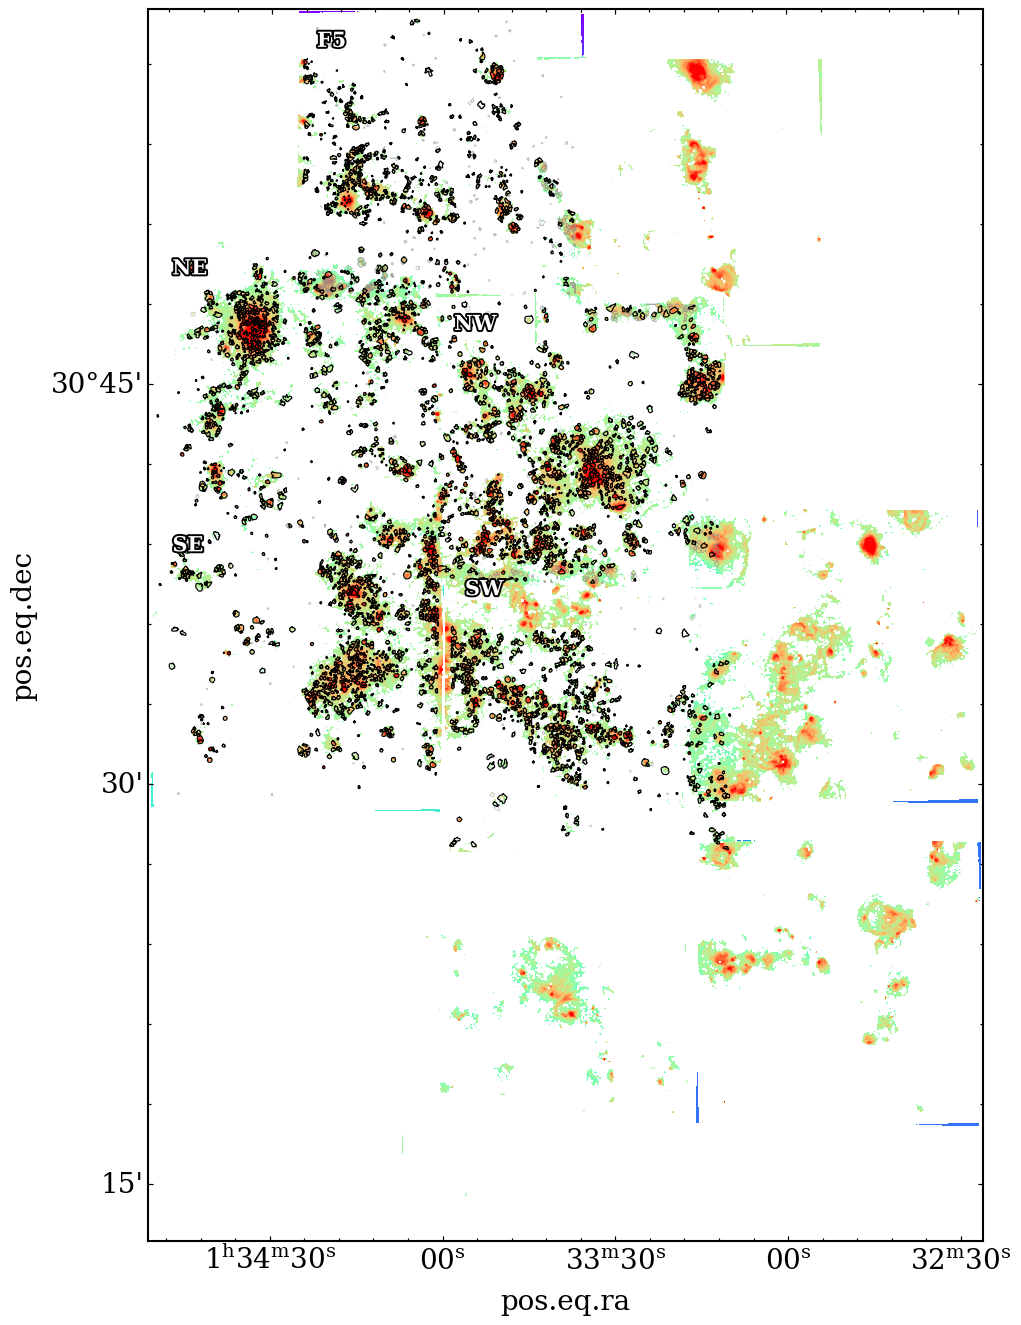

In [19]:
# All-field mosaic versions highlighting regions that fail S/N cuts.
# Grey contours are the failed regions; black contours are everything else.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)

SN_FAILURE_LINES = [
    'Halpha',
    'Hbeta',
    '[OIII]5007',
    '[NII]6583',
    '[SII]6716',
    '[SII]6731',
    '[OII]3727',
]


def _snr_values_for_line(df, line_name):
    values, col = _diag_snr(df, line_name)
    if col is None:
        raise KeyError(f'Could not find S/N column for {line_name}')
    return values, col


def _sn_failure_mask(df, mode):
    sources = {}
    if mode == 'halpha_lt0':
        values, col = _snr_values_for_line(df, 'Halpha')
        sources['Halpha'] = col
        return np.isfinite(values) & (values < 0), sources
    if mode == 'halpha_hbeta_lt0':
        ha, ha_col = _snr_values_for_line(df, 'Halpha')
        hb, hb_col = _snr_values_for_line(df, 'Hbeta')
        sources.update({'Halpha': ha_col, 'Hbeta': hb_col})
        return np.isfinite(ha) & np.isfinite(hb) & (ha < 0) & (hb < 0), sources
    if mode == 'any_line_lt0':
        masks = []
        for line in SN_FAILURE_LINES:
            values, col = _snr_values_for_line(df, line)
            sources[line] = col
            masks.append(np.isfinite(values) & (values < 0))
        return np.logical_or.reduce(masks), sources
    if mode == 'any_line_lt3':
        masks = []
        for line in SN_FAILURE_LINES:
            values, col = _snr_values_for_line(df, line)
            sources[line] = col
            masks.append(~np.isfinite(values) | (values < 3))
        return np.logical_or.reduce(masks), sources
    raise ValueError(mode)


def _add_sn_failure_category(df, mode, column):
    failed, sources = _sn_failure_mask(df, mode)
    out = df.copy()
    primary = out['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in out.columns else np.ones(len(out), dtype=bool)
    failed = failed & primary
    out[column] = np.where(failed, 'failed', 'passed')
    counts = out.loc[primary, column].value_counts().to_dict()
    return out, counts, sources

SN_FAILURE_STYLES = {
    'failed': {'color': '0.68', 'lw': 0.50, 'alpha': 0.75, 'zorder': 4, 'label': 'Failed S/N cut'},
    'passed': {'color': 'black', 'lw': 0.85, 'alpha': 1.0, 'zorder': 6, 'label': 'All other regions'},
}

COMMON_SN_FAILURE_MOSAIC_KWARGS = dict(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    pn_catalog=pn_catalog,
    boundary_color_mode='catalog_category',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    save_dpi=500,
)

sn_failure_map_specs = [
    ('halpha_lt0', 'class_snr_halpha_lt0', r'H$\alpha$ S/N < 0', 'M33_all_fields_boundaries_Halpha_SNRlt0_gray_other_black.png'),
    ('halpha_hbeta_lt0', 'class_snr_halpha_hbeta_lt0', r'H$\alpha$ and H$\beta$ S/N < 0', 'M33_all_fields_boundaries_Halpha_Hbeta_SNRlt0_gray_other_black.png'),
    ('any_line_lt0', 'class_snr_any_line_lt0', 'Any line S/N < 0', 'M33_all_fields_boundaries_any_line_SNRlt0_gray_other_black.png'),
    ('any_line_lt3', 'class_snr_any_line_lt3', 'Any line S/N < 3', 'M33_all_fields_boundaries_any_line_SNRlt3_gray_other_black.png'),
]

for mode, column, title_prefix, filename in sn_failure_map_specs:
    plot_cat, counts, sources = _add_sn_failure_category(cat, mode, column)
    n_grey = int(counts.get('failed', 0))
    n_black = int(counts.get('passed', 0))
    title = f'{title_prefix}: grey={n_grey}, black={n_black}'
    print(title)
    print('S/N columns used:', sources)
    plot_m33_boundary_mosaic(
        **COMMON_SN_FAILURE_MOSAIC_KWARGS,
        combined_catalog=plot_cat,
        boundary_category_col=column,
        boundary_category_styles=SN_FAILURE_STYLES,
        title=title,
        savepath=str(paper_plot_path(filename, subdir='field_maps')),
    )



In [ ]:
# #plot the NW halpha flux map
# ha_flux_nw = 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm, patches

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def get_wr_pixels_for_field(wr_catalog: pd.DataFrame, field_num: str, wcs: WCS):
    wr_field = wr_catalog[wr_catalog["Field"] == 'F2']
    if len(wr_field) == 0:
        return np.array([]), np.array([])

    coords = [parse_name_to_coords(n) for n in wr_field["Name (star)"]]
    sky = SkyCoord(coords)
    x_wr, y_wr = wcs.world_to_pixel(sky)
    return np.array(x_wr), np.array(y_wr)


def get_snr_pixels_for_field(snr_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """
    Assumes columns named 'RA' and one of 'Dec'/'DEC'/'dec'.
    """
    if "Dec" in snr_catalog.columns:
        dec_col = "Dec"
    elif "DEC" in snr_catalog.columns:
        dec_col = "DEC"
    elif "dec" in snr_catalog.columns:
        dec_col = "dec"
    else:
        raise KeyError("SNR catalog must have a Dec/DEC/dec column.")

    if "RA" not in snr_catalog.columns:
        raise KeyError("SNR catalog must have an 'RA' column.")

    coords = SkyCoord(
        snr_catalog["RA"].astype(str),
        snr_catalog[dec_col].astype(str),
        unit=(u.hourangle, u.deg)
    )

    x_snr, y_snr = wcs.world_to_pixel(coords)
    x_snr = np.array(x_snr)
    y_snr = np.array(y_snr)

    in_field = (
        (x_snr > xlim[0]) & (x_snr < xlim[1]) &
        (y_snr > ylim[0]) & (y_snr < ylim[1])
    )
    return x_snr[in_field], y_snr[in_field]


def _coerce_xy_to_array(data, x_col="x", y_col="y", name="data"):
    if data is None:
        return np.empty((0, 2), dtype=float)

    if isinstance(data, pd.DataFrame):
        if not {x_col, y_col}.issubset(data.columns):
            raise ValueError(f"{name} DataFrame must contain columns '{x_col}' and '{y_col}'.")
        arr = data[[x_col, y_col]].to_numpy(dtype=float)
    else:
        arr = np.asarray(data, dtype=float)
        if arr.ndim == 1 and len(arr) == 2:
            arr = arr[None, :]
        if arr.ndim != 2 or arr.shape[1] != 2:
            raise ValueError(
                f"{name} must be either a DataFrame with columns '{x_col}' and '{y_col}' "
                f"or an array-like of shape (N, 2)."
            )

    good = np.isfinite(arr).all(axis=1)
    return arr[good]


def _points_in_box(points, xmin, xmax, ymin, ymax):
    if len(points) == 0:
        return np.empty((0, 2), dtype=float)

    mask = (
        (points[:, 0] >= xmin) & (points[:, 0] <= xmax) &
        (points[:, 1] >= ymin) & (points[:, 1] <= ymax)
    )
    return points[mask]


def _label_edges(label_map):
    """
    Boundary pixels are:
      - between two different nonzero labels, or
      - between a nonzero label and background/invalid.
    """
    lab = np.asarray(label_map)
    valid = np.isfinite(lab) & (lab > 0)

    edges = np.zeros(lab.shape, dtype=bool)

    # x-neighbors
    v1 = valid[:, :-1]
    v2 = valid[:, 1:]
    l1 = lab[:, :-1]
    l2 = lab[:, 1:]
    boundary_x = (v1 != v2) | (v1 & v2 & (l1 != l2))
    edges[:, :-1] |= boundary_x
    edges[:, 1:]  |= boundary_x

    # y-neighbors
    v1 = valid[:-1, :]
    v2 = valid[1:, :]
    l1 = lab[:-1, :]
    l2 = lab[1:, :]
    boundary_y = (v1 != v2) | (v1 & v2 & (l1 != l2))
    edges[:-1, :] |= boundary_y
    edges[1:, :]  |= boundary_y

    return edges


def _make_rgba_edge_overlay(edge_mask, color="white", alpha=1.0):
    rgba = np.zeros(edge_mask.shape + (4,), dtype=float)
    rgb = mcolors.to_rgb(color)
    rgba[..., 0] = rgb[0]
    rgba[..., 1] = rgb[1]
    rgba[..., 2] = rgb[2]
    rgba[..., 3] = edge_mask.astype(float) * alpha
    return rgba


def _dilate_mask(mask, n_iter=1):
    out = mask.copy()
    for _ in range(n_iter):
        padded = np.pad(out, 1, mode="constant", constant_values=False)
        out = (
            padded[1:-1, 1:-1] |
            padded[:-2, 1:-1] | padded[2:, 1:-1] |
            padded[1:-1, :-2] | padded[1:-1, 2:] |
            padded[:-2, :-2] | padded[:-2, 2:] |
            padded[2:, :-2] | padded[2:, 2:]
        )
    return out


def _label_region_ids(ax, label_map, x_slice=None, y_slice=None,
                      color="white", fontsize=8, alpha=0.95, zorder=6,
                      max_regions=None):
    if x_slice is None:
        x_slice = slice(0, label_map.shape[1])
    if y_slice is None:
        y_slice = slice(0, label_map.shape[0])

    sub = label_map[y_slice, x_slice]
    region_ids = np.unique(sub[np.isfinite(sub)])
    region_ids = region_ids[region_ids > 0]

    if max_regions is not None and len(region_ids) > max_regions:
        return

    for rid in region_ids:
        yy, xx = np.where(sub == rid)
        if len(xx) == 0:
            continue
        xc = np.median(xx)
        yc = np.median(yy)
        ax.text(
            xc, yc, f"{int(rid)}",
            color=color, fontsize=fontsize,
            ha="center", va="center",
            alpha=alpha, zorder=zorder,
            bbox=dict(boxstyle="round,pad=0.15", fc="black", ec="none", alpha=0.35),
        )


def _build_class_edge_overlays(label_map, catalog, region_id_col="region_id",
                               bpt_col="BPT_class_sum_dered",
                               class_colors=None,
                               x_slice=None, y_slice=None,
                               alpha=0.95, dilate_iter=0):
    if class_colors is None:
        class_colors = {
            "Star-forming": "navy",
            "Composite": "darkgreen",
            "AGN/Shock": "maroon",
            "Unclassified": "gray",
        }

    if x_slice is None:
        x_slice = slice(0, label_map.shape[1])
    if y_slice is None:
        y_slice = slice(0, label_map.shape[0])

    sub = label_map[y_slice, x_slice]

    tmp = catalog[[region_id_col, bpt_col]].drop_duplicates().copy()
    tmp = tmp.dropna(subset=[region_id_col, bpt_col])
    tmp[region_id_col] = tmp[region_id_col].astype(int)

    region_to_class = dict(zip(tmp[region_id_col], tmp[bpt_col]))
    overlays = {}

    for class_name, color in class_colors.items():
        class_region_ids = [
            rid for rid, cls in region_to_class.items()
            if cls == class_name
        ]
        if len(class_region_ids) == 0:
            continue

        class_map = np.where(np.isin(sub, class_region_ids), sub, 0)
        edges = _label_edges(class_map)

        if dilate_iter > 0:
            edges = _dilate_mask(edges, n_iter=dilate_iter)

        overlays[class_name] = _make_rgba_edge_overlay(edges, color=color, alpha=alpha)

    return overlays




def _bpt_snrthree_mask_for_zoom(df, snr_cut=3.0):
    snr_cols = [
        'SNR_Halpha_sum',
        'SNR_Hbeta_sum',
        'SNR_[OIII]5007_sum',
        'SNR_[SII]6716_sum',
        'SNR_[NII]6583_sum',
    ]
    mask = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            return np.zeros(len(df), dtype=bool)
        mask &= pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float) > snr_cut
    return mask


def _build_sf_snr3_edge_overlays(label_map, catalog, region_id_col='region_id',
                                 bpt_col='BPT_class_sum_dered', x_slice=None,
                                 y_slice=None, alpha=0.95, dilate_iter=0,
                                 sf_color='black', other_color='0.65'):
    if x_slice is None:
        x_slice = slice(0, label_map.shape[1])
    if y_slice is None:
        y_slice = slice(0, label_map.shape[0])
    sub = label_map[y_slice, x_slice]
    needed = [region_id_col, bpt_col]
    tmp = catalog[[col for col in needed if col in catalog.columns]].copy()
    if len(tmp.columns) < 2:
        return {}
    tmp = tmp.dropna(subset=[region_id_col, bpt_col])
    tmp[region_id_col] = pd.to_numeric(tmp[region_id_col], errors='coerce')
    tmp = tmp.dropna(subset=[region_id_col])
    tmp[region_id_col] = tmp[region_id_col].astype(int)
    primary = tmp['primary'].fillna(True).astype(bool) if 'primary' in tmp.columns else pd.Series(True, index=tmp.index)
    sf_snr3 = selected_star_forming_snr_mask(catalog.loc[tmp.index], snr_cut=3.0)
    sf_ids = tmp.loc[sf_snr3, region_id_col].to_numpy(dtype=int)
    other_ids = tmp.loc[~sf_snr3, region_id_col].to_numpy(dtype=int)
    overlays = {}
    for name, ids, color in [('other', other_ids, other_color), ('sf_snr3', sf_ids, sf_color)]:
        if ids.size == 0:
            continue
        class_map = np.where(np.isin(sub, ids), sub, 0)
        edges = _label_edges(class_map)
        if dilate_iter > 0:
            edges = _dilate_mask(edges, n_iter=dilate_iter)
        overlays[name] = _make_rgba_edge_overlay(edges, color=color, alpha=alpha)
    return overlays


def plot_nw_field_zoom_with_zoi_bpt_wr_snr(
    zoom_box,
    emission_peaks,
    wr_catalog,
    snr_catalog,
    pn_catalog=None,
    output_path=None,
    ha_dir="../M33-Maps",
    ha_filename_pattern="M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits",
    boundary_dir="Boundary_maps/Boundary_map_100pc",
    boundary_pattern="Boundary_map_{FIELD}.fits",
    zoi_dir="ZoI_maps/ZoI_map_100pc",
    zoi_pattern="ZoI_map_{FIELD}.fits",
    catalog_dir="CATALOGS",
    catalog_pattern=field_catalog_pattern,
    wcs_dir="../M33-Maps",
    wcs_pattern="M33-{FIELD}/M33{FIELD}-Haflux.fits",
    field="NW",
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_alpha=0.95,
    boundary_dilate_iter=0,
    zoi_color="black",
    zoi_alpha=1.0,
    zoi_dilate_iter=0,
    peak_x_col="x",
    peak_y_col="y",
    peak_marker="x",
    peak_ms=35,
    peak_color="gold",
    peak_lw=1.2,
    wr_marker="*",
    wr_size=80,
    wr_color="cyan",
    wr_edgecolor="black",
    wr_lw=0.6,
    snr_marker="s",
    snr_size=45,
    snr_facecolor="yellow",
    snr_edgecolor="black",
    snr_lw=0.7,
    pn_marker="P",
    pn_size=50,
    pn_facecolor="royalblue",
    pn_edgecolor="black",
    pn_lw=0.7,
    annotate_region_ids=True,
    region_id_fontsize=8,
    max_labeled_regions=1000,
    show_full_field_boundaries=True,
    show_wr_on_full=True,
    show_snr_on_full=True,
    show_zoi_on_full=True,
    show_peaks_on_full=True,
    sf_snr3_gray_mode=False,
    figsize=(18, 9),
    dpi=200,
    annotate_peak_id=None,
    peak_id_col="peak_id",
    peak_label_offset=(10, 10),
    peak_label_color="white",
    peak_label_fontsize=9,
    ):
    """
    Full NW field on left, zoomed inset panel on right.
    WR and SNR positions are computed with the field WCS using the same
    approach as your existing code.
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "navy",
            "Composite": "darkgreen",
            "AGN/Shock": "maroon",
            "Unclassified": "gray",
        }

    # file paths
    ha_path = os.path.join(ha_dir, ha_filename_pattern.format(FIELD=field))
    boundary_path = os.path.join(boundary_dir, boundary_pattern.format(FIELD=field))
    zoi_path = os.path.join(zoi_dir, zoi_pattern.format(FIELD=field))
    catalog_path = os.path.join(catalog_dir, catalog_pattern.format(FIELD=field))
    wcs_path = os.path.join(wcs_dir, wcs_pattern.format(FIELD=field))

    # load image / maps
    ha_data = fits.getdata(ha_path)
    boundary_map = fits.getdata(boundary_path)
    zoi_map = fits.getdata(zoi_path)
    catalog = pd.read_csv(catalog_path)

    # WCS load for WR/SNR conversion
    with fits.open(wcs_path) as hdul:
        wcs = WCS(hdul[0].header)

    # Halpha image prep
    ha_plot = np.array(ha_data, dtype=float)
    ha_plot[~np.isfinite(ha_plot) | (ha_plot <= 0)] = np.nan
    log_ha = np.log10(ha_plot)

    # zoom box
    xmin, xmax, ymin, ymax = map(int, zoom_box)
    x_slice = slice(xmin, xmax)
    y_slice = slice(ymin, ymax)

    # emission peaks from pixel dataframe
    peaks = _coerce_xy_to_array(
        emission_peaks, x_col=peak_x_col, y_col=peak_y_col, name="emission_peaks"
    )

    # WR / SNR from WCS-based conversion
    x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field, wcs)
    wr = np.column_stack([x_wr, y_wr]) if len(x_wr) > 0 else np.empty((0, 2))

    x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
    snr = np.column_stack([x_snr, y_snr]) if len(x_snr) > 0 else np.empty((0, 2))

    pn_coords = _skycoord_from_pn_catalog(pn_catalog) if pn_catalog is not None else None
    if pn_coords is not None:
        x_pn, y_pn = wcs.world_to_pixel(pn_coords)
        pn = np.column_stack([np.asarray(x_pn, dtype=float), np.asarray(y_pn, dtype=float)])
        pn = _points_in_box(pn, xlim[0], xlim[1], ylim[0], ylim[1])
    else:
        pn = np.empty((0, 2), dtype=float)

    # zoom subsets
    peaks_zoom = _points_in_box(peaks, xmin, xmax, ymin, ymax).copy()
    wr_zoom = _points_in_box(wr, xmin, xmax, ymin, ymax).copy()
    snr_zoom = _points_in_box(snr, xmin, xmax, ymin, ymax).copy()
    pn_zoom = _points_in_box(pn, xmin, xmax, ymin, ymax).copy()

    for arr in (peaks_zoom, wr_zoom, snr_zoom, pn_zoom):
        if len(arr) > 0:
            arr[:, 0] -= xmin
            arr[:, 1] -= ymin

    # boundary overlays
    if show_full_field_boundaries:
        if sf_snr3_gray_mode:
            full_class_overlays = _build_sf_snr3_edge_overlays(
                boundary_map, catalog, region_id_col=region_id_col, bpt_col=bpt_col,
                alpha=boundary_alpha, dilate_iter=boundary_dilate_iter,
                sf_color='black', other_color='0.65',
            )
        else:
            full_class_overlays = _build_class_edge_overlays(
                boundary_map, catalog, region_id_col=region_id_col, bpt_col=bpt_col,
                class_colors=class_colors, alpha=boundary_alpha, dilate_iter=boundary_dilate_iter,
            )

    if sf_snr3_gray_mode:
        zoom_class_overlays = _build_sf_snr3_edge_overlays(
            boundary_map, catalog, region_id_col=region_id_col, bpt_col=bpt_col,
            x_slice=x_slice, y_slice=y_slice, alpha=boundary_alpha,
            dilate_iter=boundary_dilate_iter, sf_color='black', other_color='0.65',
        )
    else:
        zoom_class_overlays = _build_class_edge_overlays(
            boundary_map, catalog, region_id_col=region_id_col, bpt_col=bpt_col,
            class_colors=class_colors, x_slice=x_slice, y_slice=y_slice,
            alpha=boundary_alpha, dilate_iter=boundary_dilate_iter,
        )

    # ZoI overlay
    zoi_sub = zoi_map[y_slice, x_slice]
    zoi_edges_zoom = _label_edges(zoi_sub)
    if zoi_dilate_iter > 0:
        zoi_edges_zoom = _dilate_mask(zoi_edges_zoom, n_iter=zoi_dilate_iter)
    zoi_rgba_zoom = _make_rgba_edge_overlay(
        zoi_edges_zoom, color=zoi_color, alpha=zoi_alpha
    )

    # figure
    fig, (ax0, ax1) = plt.subplots(
        1, 2, figsize=figsize, dpi=dpi,
        gridspec_kw=dict(width_ratios=[1, 1], wspace=0.08)
    )

    # left panel
    im0 = ax0.imshow(
        log_ha,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    if show_zoi_on_full:
        zoi_edges_full = _label_edges(zoi_map)
        if zoi_dilate_iter > 0:
            zoi_edges_full = _dilate_mask(zoi_edges_full, n_iter=zoi_dilate_iter)
        ax0.imshow(_make_rgba_edge_overlay(zoi_edges_full, color=zoi_color, alpha=zoi_alpha),
                   origin='lower', interpolation='nearest', zorder=3)

    if show_full_field_boundaries:
        for class_name, overlay in full_class_overlays.items():
            ax0.imshow(
                    overlay,
                    origin="lower",
                    interpolation="nearest",
                    zorder=5,
                )

    if show_peaks_on_full and len(peaks) > 0:
        ax0.scatter(peaks[:, 0], peaks[:, 1], s=max(1, peak_ms * 0.45), marker=peak_marker,
                    c=peak_color, linewidths=max(0.4, peak_lw * 0.7), zorder=5)

    if show_wr_on_full and len(wr) > 0:
        ax0.scatter(
            wr[:, 0], wr[:, 1],
            s=wr_size, marker=wr_marker,
            c=wr_color, edgecolors=wr_edgecolor,
            linewidths=wr_lw, zorder=0
        )

    if show_snr_on_full and len(snr) > 0:
        ax0.scatter(
            snr[:, 0], snr[:, 1],
            s=snr_size, marker=snr_marker,
            facecolors=snr_facecolor, edgecolors=snr_edgecolor,
            linewidths=snr_lw, zorder=0
        )

    if len(pn) > 0:
        ax0.scatter(
            pn[:, 0], pn[:, 1],
            s=pn_size, marker=pn_marker,
            facecolors=pn_facecolor, edgecolors=pn_edgecolor,
            linewidths=pn_lw, zorder=0
        )

    rect = patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False, ec="black", lw=2, zorder=10
    )
    ax0.add_patch(rect)

    ax0.set_xlim(*xlim)
    ax0.set_ylim(*ylim)
    
    #remove ticks
    ax0.set_xticks([])
    ax0.set_yticks([])


    # right panel
    zoom_img = log_ha[y_slice, x_slice]
    ax1.imshow(
        zoom_img,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    
    #remove ticks
    ax1.set_xticks([])
    ax1.set_yticks([])

    ax1.imshow(
        zoi_rgba_zoom,
        origin="lower",
        interpolation="nearest",
        zorder=3,
    )

    for class_name, overlay in zoom_class_overlays.items():
        ax1.imshow(
                overlay,
                origin="lower",
                interpolation="nearest",
                zorder=5,
            )

    if len(peaks_zoom) > 0:
        ax1.scatter(
            peaks_zoom[:, 0], peaks_zoom[:, 1],
            s=peak_ms,
            marker=peak_marker,
            c=peak_color,
            linewidths=peak_lw,
            zorder=1,
        )

    if len(wr_zoom) > 0:
        ax1.scatter(
            wr_zoom[:, 0], wr_zoom[:, 1],
            s=wr_size, marker=wr_marker,
            c=wr_color, edgecolors=wr_edgecolor,
            linewidths=wr_lw, zorder=7,
        )

    if len(snr_zoom) > 0:
        ax1.scatter(
            snr_zoom[:, 0], snr_zoom[:, 1],
            s=snr_size, marker=snr_marker,
            facecolors=snr_facecolor, edgecolors=snr_edgecolor,
            linewidths=snr_lw, zorder=7,
        )

    if len(pn_zoom) > 0:
        ax1.scatter(
            pn_zoom[:, 0], pn_zoom[:, 1],
            s=pn_size, marker=pn_marker,
            facecolors=pn_facecolor, edgecolors=pn_edgecolor,
            linewidths=pn_lw, zorder=7,
        )
    if annotate_peak_id is not None and isinstance(emission_peaks, pd.DataFrame):
        print(f"Annotating peak ID {annotate_peak_id}...")
        if peak_id_col not in emission_peaks.columns:
            raise ValueError(f"Peak DataFrame must contain column '{peak_id_col}' to annotate a specific peak.")
        # print(emission_peaks[peak_id_col].head())
        # print(emission_peaks[peak_id_col].dtype)
        # print(emission_peaks[peak_id_col].unique()[:20])
        peak_row = emission_peaks.loc[emission_peaks[peak_id_col] == annotate_peak_id]
        
        if len(peak_row) > 0:
            print(f"Annotating peak ID {annotate_peak_id} at position ({peak_row.iloc[0][peak_x_col]}, {peak_row.iloc[0][peak_y_col]})")
            px = float(peak_row.iloc[0][peak_x_col])
            py = float(peak_row.iloc[0][peak_y_col])

            # only annotate if the peak is inside the zoom box
            if (xmin <= px <= xmax) and (ymin <= py <= ymax):
                px_zoom = px - xmin
                py_zoom = py - ymin
                
                ax1.annotate(
                    f"{annotate_peak_id}",
                    xy=(px_zoom, py_zoom),
                    xytext=peak_label_offset,
                    textcoords="offset points",
                    color=peak_label_color,
                    fontsize=peak_label_fontsize,
                    ha="left",
                    va="bottom",
                    zorder=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6),
                    arrowprops=dict(arrowstyle="-", color=peak_label_color, lw=0.8),
                )
                
    if annotate_region_ids:
        _label_region_ids(
            ax1, boundary_map,
            x_slice=x_slice, y_slice=y_slice,
            color="white",
            fontsize=region_id_fontsize,
            zorder=8,
            max_regions=max_labeled_regions,
        )
        
    
    ax1.set_xlim(0, xmax - xmin)
    ax1.set_ylim(0, ymax - ymin)

    # legend
    if sf_snr3_gray_mode:
        handles = [
            plt.Line2D([0], [0], color='black', lw=3, label='SF, SNR>3'),
            plt.Line2D([0], [0], color='0.65', lw=3, label='Other region'),
        ]
    else:
        handles = [
            plt.Line2D([0], [0], color=class_colors[k], lw=3, label=k)
            for k in class_colors
        ]
    handles += [
        plt.Line2D([0], [0], color=zoi_color, lw=2, label="ZoI"),
        plt.Line2D([0], [0], color=peak_color, marker=peak_marker,
                   linestyle="None", markersize=7, label="Emission peak"),
        plt.Line2D([0], [0], marker=wr_marker, color="none",
                   markerfacecolor=wr_color, markeredgecolor=wr_edgecolor,
                   markersize=10, linestyle="None", label="WR star"),
        plt.Line2D([0], [0], marker=snr_marker, color="none",
                   markerfacecolor=snr_facecolor, markeredgecolor=snr_edgecolor,
                   markersize=8, linestyle="None", label="SNR"),
        plt.Line2D([0], [0], marker=pn_marker, color="none",
                   markerfacecolor=pn_facecolor, markeredgecolor=pn_edgecolor,
                   markersize=8, linestyle="None", label="PN"),
    ]
    
    leg = ax0.legend(handles=handles, loc="upper right", fontsize=15, frameon=True,
                     facecolor="white", edgecolor="black", framealpha=1)
    # for text in leg.get_texts():
    #     text.set_color("white")

    cbar = fig.colorbar(im0, ax=[ax0, ax1], fraction=0.023, pad=0.02)
    cbar.set_label(r"log [H$\alpha +$ [O III]$\lambda$5007) amplitude (erg s$^{-1}$ cm$^{-2}$]", fontsize=20)

    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight", dpi=dpi)

    plt.show()
    return fig, (ax0, ax1)


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_7785/2431448820.py:301: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


In [ ]:
# example
v = 'v2'

if v == 'v1':
    zoom_box = (500, 600, 1150, 1250)
elif v == 'v2':
    zoom_box = (150, 750, 1000, 1600)
elif v == 'v3':
    zoom_box = (650, 950, 650, 950)

peaks_NW = pd.read_csv("CATALOGS/final_peaks_NW.csv")
peaks_NW['id'] = (peaks_NW.index+1).astype(str)
peaks_NW

plot_nw_field_zoom_with_zoi_bpt_wr_snr(
    zoom_box=zoom_box,
    annotate_region_ids=False,
    peak_color='k',
    peak_marker='x',
    wr_color='darkviolet',
    peak_ms=10,
    zoi_color='lightgrey',
    annotate_peak_id='850',
    peak_id_col='id',
    vmax = -15,
    peak_label_offset = (-35, -6),
    peak_label_fontsize = 20,
    peak_label_color = 'k',
    emission_peaks=peaks_NW,  
    wr_catalog=wr_catalog,    
    snr_catalog=snr_catalog,  
    pn_catalog=pn_catalog,
    snr_facecolor='yellow',
    snr_edgecolor='black',
    boundary_dilate_iter=1,
    sf_snr3_gray_mode=True,
    show_zoi_on_full=True,
    show_peaks_on_full=True,
    dpi=300,
    output_path=str(paper_plot_path(f"NW_zoom_with_zoi_{v}.pdf", subdir="zoom_maps")),
    zoi_dir="ZoI_maps/ZoI_map_100pc",
    zoi_pattern="ZoI_map_{FIELD}.fits",
    class_colors={
        "Star-forming": "black",
        "Composite": "0.65",
        "AGN/Shock": "0.65",
        "Unclassified": "0.65",
    },
)
save_for_paper(
    paper_plot_path(f"NW_zoom_with_zoi_{v}.pdf", subdir="zoom_maps"),
    "M33_NW_zoom_regions.pdf",
)


Annotating peak ID 850...
Annotating peak ID 850 at position (359, 1206)


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_7785/2431448820.py:675: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


KeyboardInterrupt: 

In [ ]:
# number of selected star-forming regions
sf_count = int(selected_star_forming_mask(cat).sum())
print(f"Star-forming definition: {star_forming_definition_label()}")
print(f'Number of selected star-forming regions: {sf_count} out of {len(cat)}')

Star-forming definition: BPT star-forming
Number of selected star-forming regions: 5134 out of 5893


In [ ]:
np.nanmin(cat['SNR_Halpha_sum'])

#how many regions have SNR_Halpha_sum <= 3.0?
low_snr_count = np.sum(cat['SNR_Halpha_sum'] <= 3.0)
print(f"Number of regions with SNR_Halpha_sum <= 3.0: {low_snr_count}")

Number of regions with SNR_Halpha_sum <= 3.0: 35


In [ ]:
# min(cat['area_px_after_carve'])

#how many regions have area_px_after_carve <= 20 and low Halpha flux?
small_region_count = np.sum((cat['area_px_after_carve'] <= 20))
print(f"Number of regions with area_px_after_carve <= 20 and F_Halpha <= 10.0: {small_region_count}")
#which field are these regions in?
small_regions = cat[(cat['area_px_after_carve'] <= 20)]
print(small_regions[['field', 'area_px_after_carve', 'F_Halpha_sum_dered']])

Number of regions with area_px_after_carve <= 20 and F_Halpha <= 10.0: 0
Empty DataFrame
Columns: [field, area_px_after_carve, F_Halpha_sum_dered]
Index: []


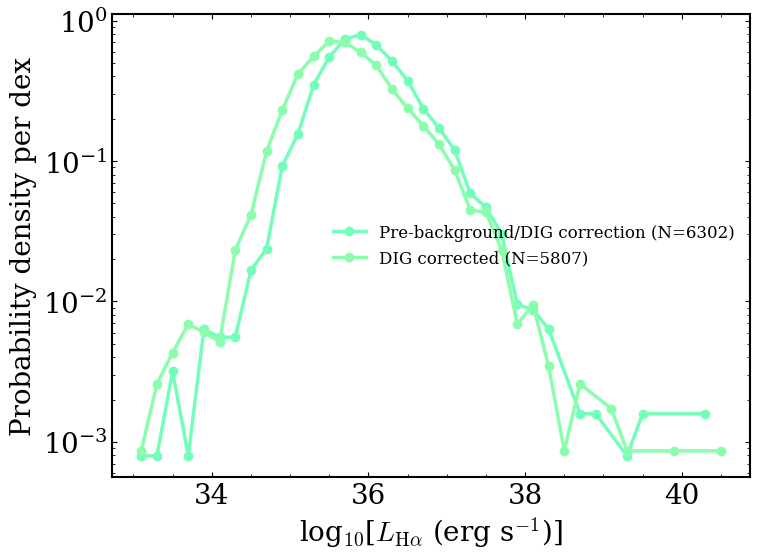

DIG comparison source, no_dig: CATALOGS/flux_catalogs/summed_map/no_dig/total_flux_catalog_combined.csv
DIG comparison source, dig_subtracted: CATALOGS/flux_catalogs/summed_map/dig_subtracted/total_flux_catalog_combined.csv


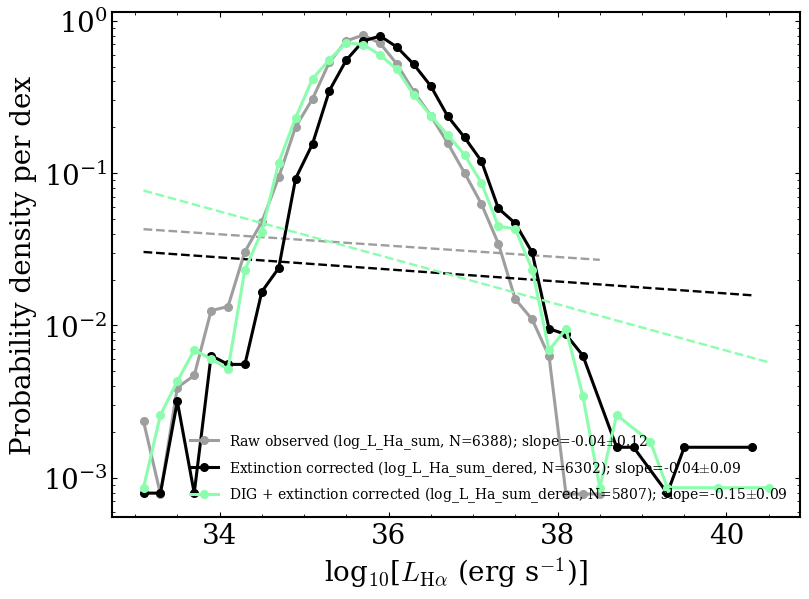

In [ ]:
def load_available_flux_catalog(method, dig_mode, primary_only=True):
    base_dir = Path('CATALOGS') / 'flux_catalogs' / method / dig_mode
    preferred_paths = [
        base_dir / 'total_flux_catalog_combined.csv',
        base_dir / 'total_flux_catalog.csv',
    ]

    df = None
    source = None
    for path in preferred_paths:
        if path.exists():
            df = pd.read_csv(path)
            source = str(path)
            break

    if df is None:
        field_paths = sorted(base_dir.glob('flux_catalog_*.csv'))
        if not field_paths:
            raise FileNotFoundError(f'No available flux catalogs found in {base_dir}')
        df = pd.concat((pd.read_csv(path) for path in field_paths), ignore_index=True, sort=False)
        source = f'{len(field_paths)} field catalogs from {base_dir}'

    if primary_only and 'primary' in df.columns:
        df = df.loc[df['primary'].fillna(True)].copy().reset_index(drop=True)

    return df, source


cat_nodig, nodig_source = load_available_flux_catalog(catalog_method, 'no_dig', primary_only=primary_only)
cat_digsub, digsub_source = load_available_flux_catalog(catalog_method, 'dig_subtracted', primary_only=primary_only)

dig_before = cat_nodig['log_L_Ha_sum_dered'].to_numpy(dtype=float)
dig_after = cat_digsub['log_L_Ha_sum_dered'].to_numpy(dtype=float)

dig_before = dig_before[np.isfinite(dig_before)]
dig_after = dig_after[np.isfinite(dig_after)]

def luminosity_function_pdf_points(logL, bins):
    logL = np.asarray(logL, dtype=float)
    logL = logL[np.isfinite(logL)]
    if len(logL) == 0:
        return np.array([]), np.array([]), np.array([])
    counts, edges = np.histogram(logL, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    pdf = counts / (np.sum(counts) * widths)
    detected = counts > 0
    return centers[detected], pdf[detected], counts[detected]

logL_bins = np.arange(33.0, 40.6, 0.2)
fig, ax = plt.subplots(figsize=(8, 6))

lf_specs = [
    (dig_before, lf_comparison_colors['pre_dig'], 'Pre-background/DIG correction'),
    (dig_after, lf_comparison_colors['dig_corrected'], 'DIG corrected'),
]

for logL_values, color, label in lf_specs:
    centers, pdf, counts = luminosity_function_pdf_points(logL_values, logL_bins)
    if len(centers) == 0:
        continue
    ax.plot(
        centers,
        pdf,
        marker='o',
        markersize=6,
        linewidth=2.5,
        color=color,
        label=f'{label} (N={len(logL_values)})',
    )

ax.set_xlabel(r'log$_{10}$[$L_{\rm H\alpha}$ (erg s$^{-1}$)]')
ax.set_ylabel(r'Probability density per dex')
ax.set_yscale('log')
ax.minorticks_on()
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
fig.savefig(
    paper_plot_path(
        f'M33_HII_Halpha_luminosity_function_corrections_{catalog_method}.png',
        subdir='luminosity_functions'
    ),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print(f'DIG comparison source, no_dig: {nodig_source}')
print(f'DIG comparison source, dig_subtracted: {digsub_source}')


# Three-version luminosity function: raw observed, extinction corrected, and DIG+extinction corrected.
def _first_log_luminosity(df, candidates):
    for col in candidates:
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)
            if col.startswith('L_'):
                with np.errstate(divide='ignore', invalid='ignore'):
                    vals = np.log10(vals)
            return vals, col
    raise KeyError(f'None of these luminosity columns are present: {candidates}')


def _fit_lf_pdf_slope(logL_values, bins, min_points=4):
    centers, pdf, counts = luminosity_function_pdf_points(logL_values, bins)
    mask = np.isfinite(centers) & np.isfinite(pdf) & (pdf > 0) & (counts > 0)
    if mask.sum() < min_points:
        return centers, pdf, counts, None
    fit = linregress(centers[mask], np.log10(pdf[mask]))
    return centers, pdf, counts, fit

lf_three_specs = []
raw_logL, raw_col = _first_log_luminosity(cat_nodig, ['log_L_Ha_sum', 'L_Ha_sum', 'log_L_Ha_observed', 'L_Ha_observed'])
ext_logL, ext_col = _first_log_luminosity(cat_nodig, ['log_L_Ha_sum_dered', 'L_Ha_sum_dered'])
final_logL, final_col = _first_log_luminosity(cat_digsub, ['log_L_Ha_sum_dered', 'L_Ha_sum_dered'])
lf_three_specs = [
    (raw_logL, '0.62', 'Raw observed', raw_col, 1),
    (ext_logL, 'black', 'Extinction corrected', ext_col, 2),
    (final_logL, color_dic['L_Ha_sum_dered'], 'DIG + extinction corrected', final_col, 3),
]

fig, ax = plt.subplots(figsize=(8.5, 6.4))
for logL_values, color, label, col, zorder in lf_three_specs:
    logL_values = np.asarray(logL_values, dtype=float)
    logL_values = logL_values[np.isfinite(logL_values)]
    centers, pdf, counts, fit = _fit_lf_pdf_slope(logL_values, logL_bins)
    if len(centers) == 0:
        continue
    fit_label = f'{label} ({col}, N={len(logL_values)})'
    if fit is not None:
        fit_label += rf'; slope={fit.slope:.2f}$\pm${fit.stderr:.2f}'
    ax.plot(centers, pdf, marker='o', markersize=5.5, linewidth=2.2, color=color, label=fit_label, zorder=zorder)
    if fit is not None:
        xfit = np.linspace(np.nanmin(centers), np.nanmax(centers), 200)
        yfit = 10 ** (fit.slope * xfit + fit.intercept)
        ax.plot(xfit, yfit, linestyle='--', linewidth=1.7, color=color, zorder=zorder)

ax.set_xlabel(r'log$_{10}$[$L_{\rm H\alpha}$ (erg s$^{-1}$)]')
ax.set_ylabel(r'Probability density per dex')
ax.set_yscale('log')
ax.minorticks_on()
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(
    paper_plot_path('M33_HII_Halpha_luminosity_function_raw_extcorr_digextcorr.png', subdir='luminosity_functions'),
    dpi=300,
    bbox_inches='tight',
)
plt.show()


In [ ]:
# Shared color dictionaries are initialized near the top of the notebook so early plots can use them.
# Recompute here as a harmless refresh before the radial-gradient section.
property_cmap = plt.get_cmap('rainbow')
property_color_positions = {
    'sum_A_V': 0.38,
    'L_Ha_sum_dered': 0.52,
    'ne_SII_cm3': 0.66,
    'logU_KK04': 0.76,
    'log_P_thermal_SII_over_k': 0.86,
    'radius_areaeq_pc': 0.94,
}
color_dic = {key: property_cmap(pos) for key, pos in property_color_positions.items()}
lf_comparison_colors = {
    'pre_dig': property_cmap(0.48),
    'dig_corrected': color_dic['L_Ha_sum_dered'],
}


In [ ]:
for col in cat.columns:
    print(col)

region_id
npix_region
npix_dig_annulus
dig_annulus_inner_px
dig_annulus_width_px
dig_annulus_outer_px
dig_annulus_source
F_Halpha_sum_nodig
F_Halpha_e_sum_nodig
SNR_Halpha_sum_nodig
Halpha_dig_median
Halpha_dig_local_median
Halpha_dig_method
Halpha_dig_mad
Halpha_dig_clip_upper
Halpha_dig_npix
Halpha_dig_npix_used
Halpha_dig_model_sum
Halpha_dig_subtracted_sum
Halpha_dig_fraction_raw
Halpha_dig_background_smooth_sigma_px
Halpha_dig_max_subtraction_fraction
F_Halpha_sum_digsub
F_Hbeta_sum_nodig
F_Hbeta_e_sum_nodig
SNR_Hbeta_sum_nodig
Hbeta_dig_median
Hbeta_dig_local_median
Hbeta_dig_method
Hbeta_dig_mad
Hbeta_dig_clip_upper
Hbeta_dig_npix
Hbeta_dig_npix_used
Hbeta_dig_model_sum
Hbeta_dig_subtracted_sum
Hbeta_dig_fraction_raw
Hbeta_dig_background_smooth_sigma_px
Hbeta_dig_max_subtraction_fraction
F_Hbeta_sum_digsub
F_[OIII]5007_sum_nodig
F_[OIII]5007_e_sum_nodig
SNR_[OIII]5007_sum_nodig
[OIII]5007_dig_median
[OIII]5007_dig_local_median
[OIII]5007_dig_method
[OIII]5007_dig_mad
[OIII]5007_

In [ ]:

# --- helper: parse "Paper (Year)" out of your existing label strings ---
_paper_re = re.compile(r"\(([^()]+?\d{4})\)\s*$")  # grabs content in last "(...)" that ends with a year


def extract_paper_id(label: str) -> str:
    """
    Returns something stable like:
      'Kobulnicky & Kewley 2004'
      'Dopita et al. 2016'
    Falls back to full label if it can't parse.
    """
    m = _paper_re.search(label)
    return m.group(1).strip() if m else str(label).strip()


METALLICITY_COLUMN_INFO = {
    'Z_12logOH': ('KK04 iterative', 'R23/O32'),
    'Z_N2_Brazzini2024': ('Brazzini et al. 2024', 'N2'),
    'Z_O3N2_Brazzini2024': ('Brazzini et al. 2024', 'O3N2'),
    'Z_N2S2Halpha_Brazzini2024': ('Brazzini et al. 2024', 'N2S2Halpha'),
    'Z_R3_Brazzini2024': ('Brazzini et al. 2024', 'R3'),
    'Z_R23_Maiolino2008': ('Maiolino et al. 2008', 'R23'),
    'Z_N2_Maiolino2008': ('Maiolino et al. 2008', 'N2'),
    'Z_R23_Curti2017': ('Curti et al. 2017', 'R23'),
    'Z_R3_Curti2017': ('Curti et al. 2017', 'R3'),
    'Z_N2_Curti2017': ('Curti et al. 2017', 'N2'),
    'Z_O3N2_Curti2017': ('Curti et al. 2017', 'O3N2'),
    'Z_R_Pilyugin2016_highN2': ('Pilyugin et al. 2016 high N2', 'R'),
    'Z_R_Pilyugin2016_lowN2': ('Pilyugin et al. 2016 low N2', 'R'),
    'Z_S_Pilyugin2016_highN2': ('Pilyugin et al. 2016 high N2', 'S'),
    'Z_S_Pilyugin2016_lowN2': ('Pilyugin et al. 2016 low N2', 'S'),
    'Z_R23_KK2004': ('Kobulnicky & Kewley 2004', 'R23'),
    'Z_NII_KD2002': ('Kewley & Dopita 2002', 'NII'),
    'Z_D2016': ('Dopita et al. 2016', 'N2S2Halpha'),
    'Z_O3N2_M2013': ('Marino et al. 2013', 'O3N2'),
    'Z_N2_M2013': ('Marino et al. 2013', 'N2'),
    'Z_C2001': ('Charlot & Longhetti 2001', 'CL01'),
    'Z_N2_PP2004': ('Pettini \\& Pagel 2004', 'N2'),
    'Z_O3N2_PP2004': ('Pettini \\& Pagel 2004', 'O3N2'),
    'Z_N2_Brown2016': ('Brown et al. 2016', 'N2'),
    'Z_O3N2_Brown2016': ('Brown et al. 2016', 'O3N2'),
    'Z_N2O2_Brown2016': ('Brown et al. 2016', 'N2O2'),
    'Z_N2O2_KD2002': ('Kewley & Dopita 2002', 'N2O2'),
}


def _infer_metallicity_column_info(col):
    stem = col.removeprefix('Z_')
    parts = stem.split('_')
    if len(parts) == 1:
        return (parts[0], parts[0])
    indicator = parts[0]
    reference = ' '.join(parts[1:])
    return (reference, indicator)


def build_metallicity_calibrations(df, include_all=True):
    """Build the calibration registry for every saved metallicity column in the catalog."""
    nan_series = lambda: pd.Series(np.nan, index=df.index)
    cols = [
        col for col in df.columns
        if col.startswith('Z_') and not col.endswith('_e') and f'{col}_e' in df.columns
    ]
    if not include_all:
        cols = [col for col in METALLICITY_COLUMN_INFO if col in df.columns]
    ordered = [col for col in METALLICITY_COLUMN_INFO if col in cols]
    ordered += sorted(col for col in cols if col not in METALLICITY_COLUMN_INFO)
    calibrations = []
    for col in ordered:
        label, line_group = METALLICITY_COLUMN_INFO.get(col, _infer_metallicity_column_info(col))
        calibrations.append((df[col], df.get(f'{col}_e', nan_series()), label, line_group, col))
    return calibrations


# --- unified calibration registry ---
# Each entry: (data_array, error_array, label, line_group, column_name)
calibrations = build_metallicity_calibrations(cat)


In [ ]:
from itertools import cycle

def build_style_map(calibrations):
    paper_ids = []
    for item in calibrations:
        label = item[2]
        pid = extract_paper_id(label)
        if pid not in paper_ids:
            paper_ids.append(pid)
    print(len(paper_ids), "unique papers found.")
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, 8))
    marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8'])

    style_map = {}
    for i, pid in enumerate(paper_ids):
        style_map[pid] = {
            "color": colors[i % len(colors)],
            "marker": next(marker_cycle),
        }
    return style_map

style_map = build_style_map(calibrations)


13 unique papers found.


In [ ]:
for col in cat.columns:
    print(col)

region_id
npix_region
npix_dig_annulus
dig_annulus_inner_px
dig_annulus_width_px
dig_annulus_outer_px
dig_annulus_source
F_Halpha_sum_nodig
F_Halpha_e_sum_nodig
SNR_Halpha_sum_nodig
Halpha_dig_median
Halpha_dig_local_median
Halpha_dig_method
Halpha_dig_mad
Halpha_dig_clip_upper
Halpha_dig_npix
Halpha_dig_npix_used
Halpha_dig_model_sum
Halpha_dig_subtracted_sum
Halpha_dig_fraction_raw
Halpha_dig_background_smooth_sigma_px
Halpha_dig_max_subtraction_fraction
F_Halpha_sum_digsub
F_Hbeta_sum_nodig
F_Hbeta_e_sum_nodig
SNR_Hbeta_sum_nodig
Hbeta_dig_median
Hbeta_dig_local_median
Hbeta_dig_method
Hbeta_dig_mad
Hbeta_dig_clip_upper
Hbeta_dig_npix
Hbeta_dig_npix_used
Hbeta_dig_model_sum
Hbeta_dig_subtracted_sum
Hbeta_dig_fraction_raw
Hbeta_dig_background_smooth_sigma_px
Hbeta_dig_max_subtraction_fraction
F_Hbeta_sum_digsub
F_[OIII]5007_sum_nodig
F_[OIII]5007_e_sum_nodig
SNR_[OIII]5007_sum_nodig
[OIII]5007_dig_median
[OIII]5007_dig_local_median
[OIII]5007_dig_method
[OIII]5007_dig_mad
[OIII]5007_

In [ ]:
# print(np.nanmean(cat['Z_O3N2_PP2004_e']))
# print(np.nanmean(cat['Z_O3N2_Brown2016_e']))
# print(np.nanmean(cat['Z_N2O2_Brown2016_e']))


In [ ]:
def fit_line_and_plot(
    x, y, label, *,
    yerr=None,
    do_plot=True,
    alpha=0.1,
    s=30,
    color=None,
    marker='o',
    shade_alpha=0.25,
    outline_lw=5,
    line_lw=3,
    bins=None,
    plot_bins=True,
    bin_min_count=1,
    bin_stat='median',
    bin_percentiles=(16, 84),
    bin_marker='h',
    bin_s=180,
    bin_edgecolor='k',
    bin_lw=1.5,
    capsize=4,
    capthick=1.5,
    fit_all_points=True,
    fit_binned=False,
    fit_range=None,
    fit_binned_range=None,
    fit_logy_points=False,
    fit_logy_bins=False,
    log_base=10,
    scatter_hollow=True,
    show_band=True,
    show_point_errors=False,
    legend=True,
    legend_loc='upper right',
    legend_frame=True,
):
    import numpy as np
    import matplotlib.pyplot as plt

    x = np.asarray(x, float)
    y = np.asarray(y, float)
    if yerr is None:
        yerr = np.full_like(y, np.nan, dtype=float)
    else:
        yerr = np.asarray(yerr, float)

    def _apply_log(arr, log_base=10):
        if log_base == 10:
            return np.log10(arr)
        elif log_base in ['e', np.e]:
            return np.log(arr)
        raise ValueError("log_base must be 10 or 'e'")

    def _transform_yerr(yf, yerrf, fit_logy=False, log_base=10):
        if not fit_logy:
            return yerrf
        with np.errstate(divide='ignore', invalid='ignore'):
            if log_base == 10:
                return yerrf / (np.log(10.0) * yf)
            return yerrf / yf

    def _fit_linear(xf, yf, yerrf=None, fit_logy=False, log_base=10):
        xf = np.asarray(xf, float)
        yf = np.asarray(yf, float)
        if yerrf is None:
            yerrf = np.full_like(yf, np.nan, dtype=float)
        else:
            yerrf = np.asarray(yerrf, float)

        ok = np.isfinite(xf) & np.isfinite(yf)
        xf = xf[ok]
        yf = yf[ok]
        yerrf = yerrf[ok]

        if fit_logy:
            pos = yf > 0
            xf = xf[pos]
            yerrf = yerrf[pos]
            yf = yf[pos]
            if len(yf) < 2:
                return np.nan, np.nan, xf, yf, yerrf
            yerrf = _transform_yerr(yf, yerrf, fit_logy=True, log_base=log_base)
            yf = _apply_log(yf, log_base=log_base)

        if len(xf) < 2:
            return np.nan, np.nan, xf, yf, yerrf

        good_err = np.isfinite(yerrf) & (yerrf > 0)
        if good_err.sum() >= 2:
            m, b = np.polyfit(xf[good_err], yf[good_err], 1, w=1.0 / yerrf[good_err])
        else:
            m, b = np.polyfit(xf, yf, 1)
        return m, b, xf, yf, yerrf

    def _eval_fit(m, b, xgrid, fit_logy=False, log_base=10):
        if fit_logy:
            y_model = m * xgrid + b
            if log_base == 10:
                return 10**y_model
            elif log_base in ['e', np.e]:
                return np.exp(y_model)
        return m * xgrid + b

    def _fit_label(m, b, which='points', fit_logy=False, log_base=10, weighted=False):
        suffix = "weighted" if weighted else which
        if fit_logy:
            if log_base == 10:
                return fr'$\log(y) = {m:.2f}x {b:+.2f}$ ({suffix})'
            return fr'$\ln(y) = {m:.2f}x {b:+.2f}$ ({suffix})'
        return fr'$y = {m:.2f}x {b:+.2f}$ ({suffix})'

    msk = np.isfinite(x) & np.isfinite(y)
    if msk.sum() < 2:
        if do_plot:
            plt.scatter(x, y, alpha=alpha, s=s, color=color)
        return {
            'point_fit': (np.nan, np.nan),
            'binned_fit': (np.nan, np.nan),
            'bin_centers': None,
            'bin_values': None,
            'bin_yerr_low': None,
            'bin_yerr_high': None,
            'bin_counts': None,
        }

    xf = x[msk]
    yf = y[msk]
    yef = yerr[msk]

    bin_centers = None
    bin_values = None
    bin_yerr_low = None
    bin_yerr_high = None
    bin_counts = None
    binned_fit = (np.nan, np.nan)

    if bins is not None and plot_bins:
        bins = np.asarray(bins, float)
        bin_centers_ = 0.5 * (bins[:-1] + bins[1:])
        vals, lo, hi, cnt = [], [], [], []
        for i in range(len(bins) - 1):
            in_bin = (xf >= bins[i]) & (xf < bins[i + 1])
            nbin = np.sum(in_bin)
            cnt.append(nbin)
            if nbin >= bin_min_count:
                yb = yf[in_bin]
                yeb = yef[in_bin]
                if bin_stat == 'median':
                    y0 = np.median(yb)
                else:
                    raise ValueError("Currently only bin_stat='median' is supported.")
                p_lo, p_hi = np.percentile(yb, bin_percentiles)
                base_lo = y0 - p_lo
                base_hi = p_hi - y0
                finite_yeb = yeb[np.isfinite(yeb) & (yeb > 0)]
                med_err = np.median(finite_yeb) if finite_yeb.size else 0.0
                vals.append(y0)
                lo.append(np.sqrt(base_lo**2 + med_err**2))
                hi.append(np.sqrt(base_hi**2 + med_err**2))
            else:
                vals.append(np.nan)
                lo.append(np.nan)
                hi.append(np.nan)
        bin_centers = np.asarray(bin_centers_)
        bin_values = np.asarray(vals)
        bin_yerr_low = np.asarray(lo)
        bin_yerr_high = np.asarray(hi)
        bin_counts = np.asarray(cnt)

    if do_plot and show_point_errors:
        valid_err = np.isfinite(yef) & (yef > 0)
        if np.any(valid_err):
            plt.errorbar(xf[valid_err], yf[valid_err], yerr=yef[valid_err], fmt='none', ecolor=color, alpha=max(alpha, 0.15), elinewidth=0.8, capsize=0, zorder=0)

    if do_plot:
        scatter_kwargs = dict(alpha=alpha, s=s, marker=marker, zorder=1)
        if scatter_hollow:
            scatter_kwargs.update(facecolors='none', edgecolors=color, linewidths=1.0)
        else:
            scatter_kwargs.update(c=color, edgecolors=color, linewidths=0.1)
        plt.scatter(xf, yf, **scatter_kwargs)

    point_fit = (np.nan, np.nan)
    if fit_all_points:
        xfit_data = xf.copy()
        yfit_data = yf.copy()
        yerr_data = yef.copy()
        if fit_range is not None:
            xmin, xmax = fit_range
            keep = (xfit_data >= xmin) & (xfit_data <= xmax)
            xfit_data = xfit_data[keep]
            yfit_data = yfit_data[keep]
            yerr_data = yerr_data[keep]
        m, b, xfit_use, yfit_use, yerr_use = _fit_linear(xfit_data, yfit_data, yerr_data, fit_logy=fit_logy_points, log_base=log_base)
        point_fit = (m, b)
        if do_plot and np.isfinite(m) and np.isfinite(b):
            xline = np.linspace(np.nanmin(xfit_data if len(xfit_data) else xf), np.nanmax(xfit_data if len(xfit_data) else xf), 300)
            yline = _eval_fit(m, b, xline, fit_logy=fit_logy_points, log_base=log_base)
            if show_band and (not fit_logy_points) and len(xfit_use) > 2:
                n = len(xfit_use)
                xbar = np.mean(xfit_use)
                yfit_pts = m * xfit_use + b
                s_err = np.sqrt(np.sum((yfit_use - yfit_pts) ** 2) / (n - 2))
                Sxx = np.sum((xfit_use - xbar) ** 2)
                if Sxx > 0:
                    y_err = s_err * np.sqrt(1 / n + (xline - xbar) ** 2 / Sxx)
                    plt.fill_between(xline, yline - y_err, yline + y_err, color=color, alpha=shade_alpha, zorder=2)
            plt.plot(xline, yline, color='black', linewidth=outline_lw, linestyle='-', zorder=3)
            weighted = np.isfinite(yerr_use).sum() >= 2
            plt.plot(xline, yline, color=color, linewidth=line_lw, linestyle='-', label=_fit_label(m, b, which='points', fit_logy=fit_logy_points, log_base=log_base, weighted=weighted), zorder=4)

    if do_plot and (bin_centers is not None):
        valid_bins = np.isfinite(bin_centers) & np.isfinite(bin_values) & np.isfinite(bin_yerr_low) & np.isfinite(bin_yerr_high)
        if np.any(valid_bins):
            plt.errorbar(bin_centers[valid_bins], bin_values[valid_bins], yerr=[bin_yerr_low[valid_bins], bin_yerr_high[valid_bins]], fmt='none', ecolor='k', elinewidth=1.5, capsize=capsize, capthick=capthick, zorder=5)
            plt.scatter(bin_centers[valid_bins], bin_values[valid_bins], s=bin_s, marker=bin_marker, facecolors=color, edgecolors=bin_edgecolor, linewidths=bin_lw, zorder=6, label=f'{label} bins')

    if fit_binned and (bin_centers is not None) and (bin_values is not None):
        valid_bins = np.isfinite(bin_centers) & np.isfinite(bin_values)
        xb = bin_centers[valid_bins]
        yb = bin_values[valid_bins]
        yeb = 0.5 * (bin_yerr_low[valid_bins] + bin_yerr_high[valid_bins]) if bin_yerr_low is not None else np.full_like(yb, np.nan)
        if fit_binned_range is not None:
            xmin, xmax = fit_binned_range
            keep = (xb >= xmin) & (xb <= xmax)
            xb = xb[keep]
            yb = yb[keep]
            yeb = yeb[keep]
        mb, bb, xb_use, yb_use, yeb_use = _fit_linear(xb, yb, yeb, fit_logy=fit_logy_bins, log_base=log_base)
        binned_fit = (mb, bb)
        if do_plot and np.isfinite(mb) and np.isfinite(bb):
            xline_b = np.linspace(np.nanmin(xb if len(xb) else bin_centers[valid_bins]), np.nanmax(xb if len(xb) else bin_centers[valid_bins]), 300)
            yline_b = _eval_fit(mb, bb, xline_b, fit_logy=fit_logy_bins, log_base=log_base)
            weighted = np.isfinite(yeb_use).sum() >= 2
            plt.plot(xline_b, yline_b, color='k', linestyle='--', linewidth=2.5, label=_fit_label(mb, bb, which='bins', fit_logy=fit_logy_bins, log_base=log_base, weighted=weighted), zorder=7)

    if do_plot and legend:
        leg = plt.legend(loc=legend_loc, frameon=legend_frame, framealpha=1.0, edgecolor='k')
        if leg is not None:
            leg.get_frame().set_linewidth(1.5)

    return {
        'point_fit': point_fit,
        'binned_fit': binned_fit,
        'bin_centers': bin_centers,
        'bin_values': bin_values,
        'bin_yerr_low': bin_yerr_low,
        'bin_yerr_high': bin_yerr_high,
        'bin_counts': bin_counts,
    }


In [ ]:
# Literature M33 gradients overplotted on metallicity calibration panels.
literature_gradients = [
    dict(label='Rosolowsky+2008', m=-0.027, b=8.36, ls='-'),
    dict(label='Magrini+2010', m=-0.044, b=8.447, ls='--'),
    dict(label='Rogers+2022', m=-0.037, b=8.59, ls='-.'),
]

PAPER_METALLICITY_SELECTION = [
    'Z_O3N2_M2013',
    'Z_N2S2Halpha_Brazzini2024',
    'Z_N2_M2013',
    'Z_R3_Brazzini2024',
    'Z_N2O2_Brown2016',
]


def _calibration_col(item):
    return item[4] if len(item) > 4 else None


def _select_calibrations(calibrations, selected_columns=None):
    if selected_columns is None:
        return list(calibrations)
    selected = []
    wanted = list(selected_columns)
    for col in wanted:
        match = [item for item in calibrations if _calibration_col(item) == col]
        if match:
            selected.append(match[0])
        else:
            print(f'Warning: requested metallicity calibration column not found: {col}')
    return selected


def _metallicity_fit_with_covariance(x, y, yerr=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is None:
        yerr = np.full_like(y, np.nan, dtype=float)
    else:
        yerr = np.asarray(yerr, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    yerr = yerr[ok]
    if len(x) < 2:
        return np.nan, np.nan, np.nan, np.nan

    good_err = np.isfinite(yerr) & (yerr > 0)
    x_fit = x[good_err] if good_err.sum() >= 2 else x
    y_fit = y[good_err] if good_err.sum() >= 2 else y
    weights = 1.0 / yerr[good_err] if good_err.sum() >= 2 else None
    if len(x_fit) < 2:
        return np.nan, np.nan, np.nan, np.nan

    m, b = np.polyfit(x_fit, y_fit, 1, w=weights)
    m_err = np.nan
    b_err = np.nan
    if len(x_fit) > 2:
        try:
            _, cov = np.polyfit(x_fit, y_fit, 1, w=weights, cov=True)
            m_err = float(np.sqrt(cov[0, 0]))
            b_err = float(np.sqrt(cov[1, 1]))
        except Exception:
            reg = linregress(x_fit, y_fit)
            m_err = reg.stderr
            b_err = reg.intercept_stderr
    return float(m), float(b), float(m_err), float(b_err)


def _metallicity_binned_stats(x, y, yerr, bins, min_count=5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)
    centers = 0.5 * (bins[:-1] + bins[1:])
    med = np.full(len(centers), np.nan)
    lo = np.full(len(centers), np.nan)
    hi = np.full(len(centers), np.nan)
    counts = np.zeros(len(centers), dtype=int)

    for i in range(len(centers)):
        in_bin = np.isfinite(x) & np.isfinite(y) & (x >= bins[i]) & (x < bins[i + 1])
        counts[i] = int(in_bin.sum())
        if counts[i] < min_count:
            continue
        yb = y[in_bin]
        yeb = yerr[in_bin]
        y0 = np.nanmedian(yb)
        p16 = np.nanpercentile(yb, 16)
        p84 = np.nanpercentile(yb, 84)
        finite_err = yeb[np.isfinite(yeb) & (yeb > 0)]
        med_err = np.nanmedian(finite_err) if finite_err.size else 0.0
        med[i] = y0
        lo[i] = np.sqrt((y0 - p16) ** 2 + med_err ** 2)
        hi[i] = np.sqrt((p84 - y0) ** 2 + med_err ** 2)
    return centers, med, lo, hi, counts


def _average_metallicity_error(yerr):
    yerr = np.asarray(yerr, dtype=float)
    good = yerr[np.isfinite(yerr) & (yerr > 0)]
    return float(np.nanmedian(good)) if len(good) else np.nan


def _calibration_display_name(label, line_group):
    clean = _clean_calibration_label(label) if '_clean_calibration_label' in globals() else str(label).replace('\\&', '&')
    return f'{line_group}: {clean}'


def _metallicity_color_map(calibrations):
    cmap = plt.get_cmap('rainbow')
    # Use only the blue-purple portion of rainbow, kept separate from the green-red property palette.
    colors = cmap(np.linspace(0.02, 0.30, max(len(calibrations), 2)))
    return {_calibration_col(item) or f'{item[3]}_{item[2]}': colors[i] for i, item in enumerate(calibrations)}


def plot_metallicity_calibration_multipanel(
    calibrations,
    style_map,
    R_gal,
    save_subdir='metallicity_calibrations',
    filename='M33_metallicity_calibrations_multipanel.png',
    fit_range=(0, 8),
    bins=None,
    ylim=(8, 9),
    selected_columns=None,
    show_histograms=True,
    show=True,
):
    """Plot one wide stacked metallicity-gradient panel per calibration with side histograms."""
    mpl.rcParams['text.usetex'] = False
    if bins is None:
        bins = np.arange(fit_range[0], fit_range[1] + 0.5, 0.5)

    selected_calibrations = _select_calibrations(calibrations, selected_columns)
    if not selected_calibrations:
        raise RuntimeError('No metallicity calibrations were selected for plotting.')

    x = np.asarray(R_gal, dtype=float)
    xgrid = np.linspace(fit_range[0], fit_range[1], 300)
    available = []
    for item in selected_calibrations:
        arr, err, label, grp = item[:4]
        col = _calibration_col(item)
        y = np.asarray(arr, dtype=float)
        yerr = np.asarray(err, dtype=float) if err is not None else np.full_like(y, np.nan, dtype=float)
        mask = np.isfinite(x) & np.isfinite(y) & (x >= fit_range[0]) & (x <= fit_range[1])
        if mask.sum() < 2:
            continue
        available.append((y, yerr, label, grp, col, mask))

    if not available:
        raise RuntimeError('No metallicity calibrations have enough finite data to plot.')

    if selected_columns is None:
        group_order = ['R23/O32', 'R23', 'R', 'S', 'O3N2', 'N2S2Halpha', 'N2', 'R3', 'N2O2', 'NII', 'CL01']
        group_rank = {grp: i for i, grp in enumerate(group_order)}
        available.sort(key=lambda item: (group_rank.get(item[3], 99), item[2]))

    color_by_col = _metallicity_color_map([(None, None, label, grp, col) for _, _, label, grp, col, _ in available])

    fig_height = max(2.45 * len(available), 8.5)
    fig = plt.figure(figsize=(13.8, fig_height))
    gs = fig.add_gridspec(
        nrows=len(available), ncols=2,
        width_ratios=[5.6, 1.08],
        hspace=0.06, wspace=0.025,
    )
    main_axes = []
    hist_axes = []

    for i, (y, yerr, label, grp, col, mask) in enumerate(available):
        ax = fig.add_subplot(gs[i, 0], sharex=main_axes[0] if main_axes else None, sharey=main_axes[0] if main_axes else None)
        hax = fig.add_subplot(gs[i, 1], sharey=ax)
        main_axes.append(ax)
        hist_axes.append(hax)

        color = color_by_col[col]
        pid = extract_paper_id(label)
        marker = style_map.get(pid, {}).get('marker', 'o')

        ax.scatter(
            x[mask], y[mask],
            s=11, alpha=0.14, facecolors='none', edgecolors=color,
            linewidths=0.5, marker=marker, zorder=1,
        )

        centers, med, lo, hi, counts = _metallicity_binned_stats(x[mask], y[mask], yerr[mask], bins, min_count=5)
        valid = np.isfinite(med)
        ax.errorbar(
            centers[valid], med[valid],
            yerr=[lo[valid], hi[valid]],
            fmt='none', ecolor='k', elinewidth=1.0, capsize=2.5, capthick=1.0,
            zorder=3,
        )
        ax.scatter(
            centers[valid], med[valid],
            s=44, marker='D', facecolors=color, edgecolors='k', linewidths=0.75,
            zorder=4,
        )

        slope, intercept, slope_err, _ = _metallicity_fit_with_covariance(x[mask], y[mask], yerr[mask])
        if np.isfinite(slope) and np.isfinite(intercept):
            ax.plot(xgrid, slope * xgrid + intercept, color=color, lw=2.4, zorder=5)

        for lit in literature_gradients:
            ax.plot(
                xgrid, lit['b'] + lit['m'] * xgrid,
                color='k', linestyle=lit['ls'], linewidth=1.05, alpha=0.75,
                zorder=2,
            )

        slope_text = f'slope = {slope:.3f}'
        if np.isfinite(slope_err):
            slope_text += f' $\\pm$ {slope_err:.3f}'
        slope_text += r' dex kpc$^{-1}$'
        ax.text(
            0.02, 0.91,
            f'{_calibration_display_name(label, grp)}\n{slope_text}',
            transform=ax.transAxes,
            ha='left', va='top', fontsize=12.5,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.72),
            zorder=8,
        )

        avg_err = _average_metallicity_error(yerr[mask])
        if np.isfinite(avg_err):
            xerr_pt = fit_range[1] - 0.45
            yerr_pt = ylim[1] - 0.16
            ax.errorbar(
                [xerr_pt], [yerr_pt], yerr=[[avg_err], [avg_err]],
                fmt='o', ms=4.5, color=color, ecolor='k', elinewidth=1.0,
                capsize=2.5, zorder=8,
            )
            ax.text(
                0.965, 0.84, r'$\tilde{\sigma}_Z$=' + f'{avg_err:.2g}',
                transform=ax.transAxes, ha='right', va='center', fontsize=10.5,
                bbox=dict(boxstyle='round,pad=0.16', facecolor='white', edgecolor='none', alpha=0.65),
                zorder=8,
            )

        data = y[mask]
        data = data[np.isfinite(data)]
        if show_histograms and len(data):
            hax.hist(data, bins=np.linspace(ylim[0], ylim[1], 34), orientation='horizontal', color=color, alpha=0.24, edgecolor='k', linewidth=0.45)
            median = np.nanmedian(data)
            p16 = np.nanpercentile(data, 16)
            p84 = np.nanpercentile(data, 84)
            handles = [
                hax.axhline(median, color=color, linestyle='-', lw=1.5, label=f'Med. {median:.2f}'),
                hax.axhline(p16, color=color, linestyle='--', lw=1.1, label=f'16th {p16:.2f}'),
                hax.axhline(p84, color=color, linestyle='--', lw=1.1, label=f'84th {p84:.2f}'),
            ]
            hax.legend(handles=handles, loc='upper right', frameon=False, fontsize=7.2, handlelength=1.25, borderpad=0.15, labelspacing=0.12)
        hax.set_xlabel('$N$', fontsize=9.5)
        hax.tick_params(axis='x', labelsize=8.5)
        hax.tick_params(axis='y', labelleft=False, labelright=False)
        hax.set_ylim(*ylim)
        hax.minorticks_on()

        ax.set_xlim(*fit_range)
        ax.set_ylim(*ylim)
        ax.minorticks_on()
        ax.tick_params(axis='both', labelsize=10.5)
        ax.set_ylabel('12 + log(O/H)', fontsize=12)
        if i < len(available) - 1:
            ax.tick_params(labelbottom=False)

    main_axes[-1].set_xlabel('Galactocentric Radius (kpc)', fontsize=13)

    calibration_handles = [
        mpl.lines.Line2D([], [], color=color_by_col[col], marker='D', linestyle='none', markersize=7, label=_calibration_display_name(label, grp))
        for _, _, label, grp, col, _ in available
    ]
    literature_handles = [
        mpl.lines.Line2D([], [], color='k', linestyle=lit['ls'], linewidth=1.4, label=lit['label'])
        for lit in literature_gradients
    ]
    max_handles = 12 if len(calibration_handles) > 8 else len(calibration_handles)
    legend_handles = calibration_handles[:max_handles] + literature_handles
    if len(calibration_handles) > max_handles:
        legend_handles.insert(max_handles, mpl.lines.Line2D([], [], linestyle='none', label=f'+ {len(calibration_handles) - max_handles} more calibrations'))
    fig.legend(
        handles=legend_handles,
        loc='upper center', bbox_to_anchor=(0.5, 0.996),
        ncol=4,
        frameon=False, fontsize=11.5,
    )
    fig.subplots_adjust(top=0.965 if len(available) > 8 else 0.93)

    outpath = paper_plot_path(filename, subdir=save_subdir)
    fig.savefig(outpath, dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return outpath, main_axes, hist_axes


# Backwards-compatible wrapper name; now writes one stacked multi-panel figure per catalog subset.
def plot_calibration_panel(line_group, calibrations, style_map, R_gal, save_subdir='metallicity_calibrations', filename_prefix='', show=True):
    return plot_metallicity_calibration_multipanel(
        calibrations,
        style_map,
        R_gal,
        save_subdir=save_subdir,
        filename=f'{filename_prefix}M33_metallicity_calibrations_multipanel.png',
        show=show,
    )


def plot_metallicity_vs_ionization_pressure_grid(
    df,
    calibrations,
    style_map,
    selected_columns=None,
    save_subdir='metallicity_calibrations',
    filename='M33_metallicity_vs_logU_pressure_grid.png',
    show=True,
):
    """Plot metallicity calibrations versus logU and log(P/k) in a two-column grid."""
    mpl.rcParams['text.usetex'] = False
    selected_calibrations = _select_calibrations(calibrations, selected_columns)
    selected_calibrations = [item for item in selected_calibrations if _calibration_col(item) in df.columns]
    if not selected_calibrations:
        raise RuntimeError('No metallicity calibrations were selected for the logU/pressure grid.')

    # Match the purple-blue colour assignment used by the metallicity radial-gradient panels.
    color_by_col = _metallicity_color_map(selected_calibrations)

    x_specs = [
        ('logU_KK04', r'$\log U$'),
        ('log_P_thermal_SII_over_k', r'$\log_{10}(P/k\,[{\rm K\,cm}^{-3}])$'),
    ]
    nrows = len(selected_calibrations)
    fig, axes = plt.subplots(nrows, 2, figsize=(13.5, max(2.2 * nrows, 5.5)), sharex='col', sharey=True)
    axes = np.atleast_2d(axes)

    for row, item in enumerate(selected_calibrations):
        y_arr, y_err, label, grp = item[:4]
        col = _calibration_col(item)
        display = _calibration_display_name(label, grp)
        color = color_by_col.get(col, 'C0')
        y = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)
        for j, (xcol, xlabel) in enumerate(x_specs):
            ax = axes[row, j]
            if xcol not in df.columns:
                ax.text(0.5, 0.5, f'Missing {xcol}', transform=ax.transAxes, ha='center', va='center')
                ax.set_axis_off()
                continue
            x = pd.to_numeric(df[xcol], errors='coerce').to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y) & (y >= 8.0) & (y <= 9.0)
            ax.scatter(x[mask], y[mask], s=9, alpha=0.18, color=color, edgecolors='none')
            if mask.sum() >= 3:
                fit = linregress(x[mask], y[mask])
                xgrid = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 200)
                ax.plot(xgrid, fit.slope * xgrid + fit.intercept, color='k', lw=2.0,
                        label=rf'slope={fit.slope:.3f}$\pm${fit.stderr:.3f}')
                ax.legend(frameon=False, fontsize=10, loc='upper right')
            ax.set_ylim(8, 9)
            ax.minorticks_on()
            if row == nrows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(r'$12+\log({\rm O/H})$')
                ax.text(0.02, 0.93, display, transform=ax.transAxes, ha='left', va='top', fontsize=11,
                        bbox=dict(facecolor='white', alpha=0.70, edgecolor='none', pad=2))
    fig.tight_layout()
    outpath = paper_plot_path(filename, subdir=save_subdir)
    fig.savefig(outpath, dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return outpath, axes


In [ ]:
# Multi-panel cutout plot for one example region with configurable line-ratio / line-map panels.

INTRINSIC_HA_HB_MAP = 2.86
R_V_MAP = 3.1


def ccm89_k_lambda_map(wave_angstrom, R_V=3.1):
    wave_micron = wave_angstrom * 1e-4
    x = 1.0 / wave_micron
    y = x - 1.82
    a = (
        1
        + 0.17699 * y
        - 0.50447 * y**2
        - 0.02427 * y**3
        + 0.72085 * y**4
        + 0.01979 * y**5
        - 0.77530 * y**6
        + 0.32999 * y**7
    )
    b = (
        1.41338 * y
        + 2.28305 * y**2
        + 1.07233 * y**3
        - 5.38434 * y**4
        - 0.62251 * y**5
        + 5.30260 * y**6
        - 2.09002 * y**7
    )
    return a * R_V + b


LINE_WAVELENGTHS_REGION = {
    'Hbflux': 4861.0,
    'OIII4959flux': 4959.0,
    'OIII5007flux': 5007.0,
    'Haflux': 6563.0,
    'NII6548flux': 6548.0,
    'NII6584flux': 6584.0,
    'NII6583flux': 6584.0,
    'SII6716flux': 6716.0,
    'SII6731flux': 6731.0,
    'OII3727flux': 3727.0,
}


def _normalize_region_identifier(field, region_id):
    field = str(field)
    if isinstance(region_id, str):
        rid = region_id.strip()
        if '_' in rid:
            region_label = int(rid.split('_')[-1])
            return rid, region_label
        region_label = int(float(rid))
        return f"{field}_{region_label:04d}", region_label
    region_label = int(region_id)
    return f"{field}_{region_label:04d}", region_label



def _sum_maps_from_spec(field, line_names, maps_dir, scale=1e-17, cache=None):
    if isinstance(line_names, (str, bytes)):
        line_names = [line_names]
    else:
        line_names = list(line_names)

    arrays = []
    for line_name in line_names:
        key = (field, line_name, scale)
        if cache is not None and key in cache:
            data = cache[key]
        else:
            map_path = Path(maps_dir) / f"M33-{field}" / f"M33{field}-{line_name}.fits"
            if not map_path.exists():
                raise FileNotFoundError(f"Missing map for {field} {line_name}: {map_path}")
            data = fits.getdata(map_path).astype(float)
            data = np.where(np.isfinite(data), data / scale, np.nan)
            if cache is not None:
                cache[key] = data
        arrays.append(data)

    return np.nansum(np.stack(arrays, axis=0), axis=0)



def _compute_ebv_map(field, maps_dir, cache=None, intrinsic_ha_hb=INTRINSIC_HA_HB_MAP, R_V=R_V_MAP):
    cache_key = ('EBV', field, intrinsic_ha_hb, R_V)
    if cache is not None and cache_key in cache:
        return cache[cache_key]

    ha = _sum_maps_from_spec(field, 'Haflux', maps_dir=maps_dir, cache=cache)
    hb = _sum_maps_from_spec(field, 'Hbflux', maps_dir=maps_dir, cache=cache)

    k_ha = ccm89_k_lambda_map(6563.0, R_V=R_V)
    k_hb = ccm89_k_lambda_map(4861.0, R_V=R_V)
    delta_k = k_hb - k_ha

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = ha / hb
        ebv = (2.5 / delta_k) * np.log10(ratio / intrinsic_ha_hb)

    good = np.isfinite(ha) & np.isfinite(hb) & (ha > 0) & (hb > 0)
    ebv = np.where(good, ebv, np.nan)
    ebv = np.where(np.isfinite(ebv), np.clip(ebv, 0, None), np.nan)

    if cache is not None:
        cache[cache_key] = ebv
    return ebv



def _deredden_single_line_map(field, line_name, maps_dir, cache=None, scale=1e-17, intrinsic_ha_hb=INTRINSIC_HA_HB_MAP, R_V=R_V_MAP):
    wave = LINE_WAVELENGTHS_REGION.get(line_name)
    if wave is None:
        raise KeyError(f"No wavelength mapping configured for line {line_name}")

    flux_map = _sum_maps_from_spec(field, line_name, maps_dir=maps_dir, scale=scale, cache=cache)
    ebv_map = _compute_ebv_map(field, maps_dir=maps_dir, cache=cache, intrinsic_ha_hb=intrinsic_ha_hb, R_V=R_V)
    k_line = ccm89_k_lambda_map(wave, R_V=R_V)
    correction = 10.0 ** (0.4 * ebv_map * k_line)

    with np.errstate(invalid='ignore'):
        flux_map_dered = flux_map * correction
    flux_map_dered = np.where(np.isfinite(flux_map), flux_map_dered, np.nan)
    return flux_map_dered



def _sum_dereddened_maps(field, line_names, maps_dir, cache=None, scale=1e-17, intrinsic_ha_hb=INTRINSIC_HA_HB_MAP, R_V=R_V_MAP):
    if isinstance(line_names, (str, bytes)):
        line_names = [line_names]
    else:
        line_names = list(line_names)

    arrays = [
        _deredden_single_line_map(
            field,
            line_name,
            maps_dir=maps_dir,
            cache=cache,
            scale=scale,
            intrinsic_ha_hb=intrinsic_ha_hb,
            R_V=R_V,
        )
        for line_name in line_names
    ]
    return np.nansum(np.stack(arrays, axis=0), axis=0)



def _build_flux_map(field, line_names, maps_dir, cache=None, scale=1e-17, deredden=False, intrinsic_ha_hb=INTRINSIC_HA_HB_MAP, R_V=R_V_MAP):
    if deredden:
        return _sum_dereddened_maps(
            field,
            line_names,
            maps_dir=maps_dir,
            cache=cache,
            scale=scale,
            intrinsic_ha_hb=intrinsic_ha_hb,
            R_V=R_V,
        )
    return _sum_maps_from_spec(field, line_names, maps_dir=maps_dir, scale=scale, cache=cache)



def _make_region_panel_map(field, panel_spec, maps_dir, cache=None):
    kind = panel_spec.get('kind', 'ratio').lower()
    use_deredden = panel_spec.get('deredden', False)
    intrinsic_ha_hb = panel_spec.get('intrinsic_ha_hb', INTRINSIC_HA_HB_MAP)
    R_V = panel_spec.get('R_V', R_V_MAP)

    if kind == 'ratio':
        numerator = _build_flux_map(
            field,
            panel_spec['numerator_lines'],
            maps_dir=maps_dir,
            scale=panel_spec.get('numerator_scale', 1e-17),
            cache=cache,
            deredden=use_deredden,
            intrinsic_ha_hb=intrinsic_ha_hb,
            R_V=R_V,
        )
        denominator = _build_flux_map(
            field,
            panel_spec['denominator_lines'],
            maps_dir=maps_dir,
            scale=panel_spec.get('denominator_scale', 1e-17),
            cache=cache,
            deredden=use_deredden,
            intrinsic_ha_hb=intrinsic_ha_hb,
            R_V=R_V,
        )

        min_num = panel_spec.get('min_num')
        min_den = panel_spec.get('min_den')
        if min_num is not None:
            numerator = np.where(numerator >= min_num, numerator, np.nan)
        if min_den is not None:
            denominator = np.where(denominator >= min_den, denominator, np.nan)

        with np.errstate(divide='ignore', invalid='ignore'):
            image = numerator / denominator
        image = np.where(np.isfinite(image), image, np.nan)

        if panel_spec.get('log10', True):
            image = np.where(image > 0, image, np.nan)
            with np.errstate(divide='ignore', invalid='ignore'):
                image = np.log10(image)

    elif kind == 'line':
        image = _build_flux_map(
            field,
            panel_spec['lines'],
            maps_dir=maps_dir,
            scale=panel_spec.get('flux_scale', 1e-17),
            cache=cache,
            deredden=use_deredden,
            intrinsic_ha_hb=intrinsic_ha_hb,
            R_V=R_V,
        )
        min_flux = panel_spec.get('min_flux')
        if min_flux is not None:
            image = np.where(image >= min_flux, image, np.nan)
        if panel_spec.get('log10', False):
            image = np.where(image > 0, image, np.nan)
            with np.errstate(divide='ignore', invalid='ignore'):
                image = np.log10(image)
    else:
        raise ValueError(f"Unsupported panel kind: {kind}")

    finite_clip = panel_spec.get('finite_clip')
    if finite_clip is not None:
        lo, hi = finite_clip
        image = np.where((image >= lo) & (image <= hi), image, np.nan)

    return image



def plot_region_multipanel_maps(
    field,
    region_id,
    panel_specs,
    *,
    maps_dir='../M33-Maps-Calibrated',
    zoi_dir='ZOI_maps/ZOI_map_100pc',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_metrics_pattern='Boundary_metrics_{field}.csv',
    zoi_pattern='ZoI_map_{field}.fits',
    boundary_pattern='Boundary_map_{field}.fits',
    ncols=3,
    half_size=None,
    pad_px=5,
    peak_marker_kwargs=None,
    zoi_contour_kwargs=None,
    boundary_contour_kwargs=None,
    show_colorbars=False,
    output_path=None,
    dpi=300,
    suptitle=None,
):
    region_name, region_label = _normalize_region_identifier(field, region_id)

    metrics_path = Path(boundary_dir) / boundary_metrics_pattern.format(field=field)
    if not metrics_path.exists():
        raise FileNotFoundError(f"Missing boundary metrics file: {metrics_path}")
    metrics_df = pd.read_csv(metrics_path)
    reg = metrics_df.loc[metrics_df['region_id'].astype(str) == region_name]
    if len(reg) != 1:
        raise ValueError(f"Could not find unique region {region_name} in {metrics_path}")
    reg = reg.iloc[0]

    cx = float(reg['center_x_px'])
    cy = float(reg['center_y_px'])
    contour_label = int(reg.get('zoi_center_label', region_label))

    zoi_path = Path(zoi_dir) / zoi_pattern.format(field=field)
    boundary_path = Path(boundary_dir) / boundary_pattern.format(field=field)
    if not zoi_path.exists():
        raise FileNotFoundError(f"Missing ZoI map: {zoi_path}")
    if not boundary_path.exists():
        raise FileNotFoundError(f"Missing boundary map: {boundary_path}")

    zoi_map = fits.getdata(zoi_path)
    boundary_map = fits.getdata(boundary_path)

    zoi_mask = np.asarray(zoi_map == contour_label)
    boundary_mask = np.asarray(boundary_map == contour_label)
    if not np.any(zoi_mask):
        raise ValueError(f"Region {region_name} has no ZoI pixels in {zoi_path}")
    if not np.any(boundary_mask):
        raise ValueError(f"Region {region_name} has no boundary pixels in {boundary_path}")

    if half_size is None:
        radius_guess = reg.get('radius_p84_px_after_carve', np.nan)
        if not np.isfinite(radius_guess):
            radius_guess = reg.get('radius_p84_px', np.nan)
        if not np.isfinite(radius_guess):
            radius_guess = reg.get('radius_areaeq_px_after_carve', np.nan)
        if not np.isfinite(radius_guess):
            radius_guess = 35.0
        half_size = int(np.ceil(max(60, 2.25 * float(radius_guess))))

    shape = zoi_mask.shape
    x0 = max(0, int(np.floor(cx - half_size - pad_px)))
    x1 = min(shape[1], int(np.ceil(cx + half_size + pad_px + 1)))
    y0 = max(0, int(np.floor(cy - half_size - pad_px)))
    y1 = min(shape[0], int(np.ceil(cy + half_size + pad_px + 1)))

    peak_x = cx - x0
    peak_y = cy - y0

    if peak_marker_kwargs is None:
        peak_marker_kwargs = dict(marker='+', s=70, linewidths=1.8, color='k')
    if zoi_contour_kwargs is None:
        zoi_contour_kwargs = dict(colors='k', linewidths=1.2, linestyles='--')
    if boundary_contour_kwargs is None:
        boundary_contour_kwargs = dict(colors='black', linewidths=2.5)

    map_cache = {}
    n_panels = len(panel_specs)
    ncols = min(max(1, ncols), n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 5.0 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, spec in zip(axes_flat, panel_specs):
        panel_image = _make_region_panel_map(field, spec, maps_dir=maps_dir, cache=map_cache)
        cutout = panel_image[y0:y1, x0:x1]
        zoi_cutout = zoi_mask[y0:y1, x0:x1]
        boundary_cutout = boundary_mask[y0:y1, x0:x1]

        im = ax.imshow(
            cutout,
            origin='lower',
            cmap=spec.get('cmap', 'viridis'),
            vmin=spec.get('vmin'),
            vmax=spec.get('vmax'),
        )
        # ax.contour(zoi_cutout.astype(float), levels=[0.5], origin='lower', **zoi_contour_kwargs)
        ax.contour(boundary_cutout.astype(float), levels=[0.5], origin='lower', **boundary_contour_kwargs)
        ax.scatter([peak_x], [peak_y], **peak_marker_kwargs)

        # ax.set_title(spec.get('label', ''))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')

        if show_colorbars:
            cbar = fig.colorbar(im, ax=ax, fraction=0.048, pad=0.0, orientation = 'horizontal')
            if spec.get('colorbar_label'):
                cbar.set_label(spec['colorbar_label'], fontsize = 20)

    for ax in axes_flat[n_panels:]:
        ax.axis('off')

    # if suptitle is None:
    #     suptitle = f"{region_name}: line-ratio and line-map cutouts"
    # fig.suptitle(suptitle, y=0.995)
    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight')

    plt.close()
    return fig, axes


def _project_field_panel_map_to_mosaic(
    mosaic_image,
    panel_image,
    field_wcs,
    mosaic_wcs,
    valid_bounds,
):
    field_footprint = np.zeros(mosaic_image.shape, dtype=bool)
    _add_field_inner_footprint_to_mosaic_mask(field_footprint, field_wcs, mosaic_wcs, valid_bounds)
    target = field_footprint & ~np.isfinite(mosaic_image)
    if not np.any(target):
        return 0
    y_mosaic, x_mosaic = np.nonzero(target)
    sky = mosaic_wcs.pixel_to_world(x_mosaic, y_mosaic)
    x_field, y_field = field_wcs.world_to_pixel(sky)
    xi = np.rint(x_field).astype(int)
    yi = np.rint(y_field).astype(int)
    x0, x1, y0, y1 = valid_bounds
    in_field = (
        np.isfinite(x_field) & np.isfinite(y_field)
        & (xi >= x0) & (xi < x1)
        & (yi >= y0) & (yi < y1)
        & (xi >= 0) & (xi < panel_image.shape[1])
        & (yi >= 0) & (yi < panel_image.shape[0])
    )
    if not np.any(in_field):
        return 0
    values = panel_image[yi[in_field], xi[in_field]]
    good = np.isfinite(values)
    if not np.any(good):
        return 0
    y_fill = y_mosaic[in_field][good]
    x_fill = x_mosaic[in_field][good]
    mosaic_image[y_fill, x_fill] = values[good]
    return int(np.sum(good))


def build_region_panel_mosaic_image(
    panel_spec,
    *,
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    maps_dir='../M33-Maps-Calibrated',
    mosaic_reference_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
):
    mosaic_header = fits.getheader(mosaic_reference_path)
    mosaic_shape = np.squeeze(fits.getdata(mosaic_reference_path)).shape[-2:]
    mosaic_wcs = WCS(mosaic_header)
    mosaic_image = np.full(mosaic_shape, np.nan, dtype=float)
    filled_total = 0
    map_cache = {}
    for fld in field_order:
        ha_path = Path(maps_dir) / f'M33-{fld}' / f'M33{fld}-Haflux.fits'
        if not ha_path.exists():
            print(f'Skipping {fld}: missing WCS map {ha_path}')
            continue
        field_wcs = WCS(fits.getheader(ha_path))
        panel_image = _make_region_panel_map(fld, panel_spec, maps_dir=maps_dir, cache=map_cache)
        _, valid_bounds = _field_valid_pixel_mask(
            panel_image.shape,
            field_valid_bounds=field_valid_bounds,
            field_edge_margin=field_edge_margin,
        )
        filled_total += _project_field_panel_map_to_mosaic(
            mosaic_image,
            panel_image,
            field_wcs,
            mosaic_wcs,
            valid_bounds,
        )
    return mosaic_image, mosaic_wcs, filled_total


def plot_region_panel_m33_mosaics(
    panel_specs,
    *,
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    maps_dir='../M33-Maps-Calibrated',
    mosaic_reference_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    ncols=2,
    figsize=(16, 22),
    display_stride=4,
    axis_label_fontsize=14,
    tick_label_fontsize=11,
    colorbar_fontsize=13,
    colorbar_tick_labelsize=11,
    wspace=0.03,
    hspace=0.08,
    output_path=None,
    dpi=300,
):
    n_panels = len(panel_specs)
    ncols = min(max(1, ncols), n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    fig = plt.figure(figsize=figsize)
    axes = []
    for idx, spec in enumerate(panel_specs, start=1):
        mosaic_image, mosaic_wcs, filled_total = build_region_panel_mosaic_image(
            spec,
            field_order=field_order,
            maps_dir=maps_dir,
            mosaic_reference_path=mosaic_reference_path,
            field_valid_bounds=field_valid_bounds,
            field_edge_margin=field_edge_margin,
        )
        print(f"Built M33 mosaic for {spec.get('colorbar_label', spec.get('label', 'panel'))}: {filled_total} pixels")
        display_wcs = mosaic_wcs
        if display_stride and int(display_stride) > 1:
            stride = int(display_stride)
            mosaic_image = mosaic_image[::stride, ::stride]
            display_wcs = mosaic_wcs.deepcopy()
            display_wcs.wcs.crpix = (display_wcs.wcs.crpix - 1.0) / stride + 1.0
            if getattr(display_wcs.wcs, 'has_cd', lambda: False)():
                display_wcs.wcs.cd = display_wcs.wcs.cd * stride
            else:
                display_wcs.wcs.cdelt = display_wcs.wcs.cdelt * stride
        ax = fig.add_subplot(nrows, ncols, idx, projection=display_wcs)
        cmap_obj = plt.get_cmap(spec.get('cmap', 'viridis')).copy()
        cmap_obj.set_bad('white')
        im = ax.imshow(
            mosaic_image,
            origin='lower',
            cmap=cmap_obj,
            vmin=spec.get('vmin'),
            vmax=spec.get('vmax'),
            aspect='equal',
        )
        _format_mosaic_wcs_axes(ax, axis_label_fontsize=axis_label_fontsize, tick_label_fontsize=tick_label_fontsize)
        row = (idx - 1) // ncols
        col = (idx - 1) % ncols
        ax.coords[0].set_axislabel('RA (J2000)' if row == nrows - 1 else '', fontsize=axis_label_fontsize)
        ax.coords[1].set_axislabel('Dec (J2000)' if col == 0 else '', fontsize=axis_label_fontsize)
        ax.set_facecolor('white')
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='4%', pad=0.05, axes_class=plt.Axes)
        cbar = fig.colorbar(im, cax=cax, orientation='vertical')
        if spec.get('colorbar_label'):
            cbar.set_label(spec['colorbar_label'], fontsize=colorbar_fontsize)
        cbar.ax.tick_params(labelsize=colorbar_tick_labelsize)
        axes.append(ax)

    fig.subplots_adjust(left=0.055, right=0.985, top=0.985, bottom=0.07, wspace=wspace, hspace=hspace)
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return fig, axes


def _estimate_region_pixel_scale_pc(reg):
    candidate_pairs = [
        ('radius_areaeq_pc_after_carve', 'radius_areaeq_px_after_carve'),
        ('radius_p84_pc', 'radius_p84_px'),
        ('radius_areaeq_pc', 'radius_areaeq_px'),
        ('radius_p50_pc', 'radius_p50_px'),
        ('radius_p16_pc', 'radius_p16_px'),
    ]
    for pc_col, px_col in candidate_pairs:
        pc_val = reg.get(pc_col, np.nan)
        px_val = reg.get(px_col, np.nan)
        if np.isfinite(pc_val) and np.isfinite(px_val) and float(px_val) > 0:
            return float(pc_val) / float(px_val)
    raise ValueError('Could not infer a pc-per-pixel scale for this region from the boundary metrics table.')


def _make_panel_value_norm(values, panel_spec):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return mpl.colors.Normalize(vmin=0.0, vmax=1.0)

    vmin = panel_spec.get('vmin')
    vmax = panel_spec.get('vmax')
    if vmin is None:
        vmin = float(np.nanpercentile(finite, 5))
    if vmax is None:
        vmax = float(np.nanpercentile(finite, 95))
    if not np.isfinite(vmin):
        vmin = float(np.nanmin(finite))
    if not np.isfinite(vmax):
        vmax = float(np.nanmax(finite))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return mpl.colors.Normalize(vmin=vmin, vmax=vmax)


def plot_region_multipanel_radial_profiles(
    field,
    region_id,
    panel_specs,
    *,
    maps_dir='../M33-Maps-Calibrated',
    zoi_dir='ZOI_maps/ZOI_map_100pc',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_metrics_pattern='Boundary_metrics_{field}.csv',
    zoi_pattern='ZoI_map_{field}.fits',
    boundary_pattern='Boundary_map_{field}.fits',
    ncols=3,
    radial_bin_size_pc=None,
    min_points_per_bin=4,
    scatter_size=14,
    scatter_alpha=0.75,
    median_line_kwargs=None,
    show_colorbars=True,
    output_path=None,
    dpi=300,
    suptitle=None,
):
    region_name, region_label = _normalize_region_identifier(field, region_id)

    metrics_path = Path(boundary_dir) / boundary_metrics_pattern.format(field=field)
    if not metrics_path.exists():
        raise FileNotFoundError(f'Missing boundary metrics file: {metrics_path}')
    metrics_df = pd.read_csv(metrics_path)
    reg = metrics_df.loc[metrics_df['region_id'].astype(str) == region_name]
    if len(reg) != 1:
        raise ValueError(f'Could not find unique region {region_name} in {metrics_path}')
    reg = reg.iloc[0]

    cx = float(reg['center_x_px'])
    cy = float(reg['center_y_px'])
    contour_label = int(reg.get('zoi_center_label', region_label))
    pc_per_px = _estimate_region_pixel_scale_pc(reg)
    equal_area_radius_pc = reg.get('radius_areaeq_pc_after_carve', np.nan)
    if not np.isfinite(equal_area_radius_pc):
        equal_area_radius_pc = reg.get('radius_areaeq_pc', np.nan)

    zoi_path = Path(zoi_dir) / zoi_pattern.format(field=field)
    boundary_path = Path(boundary_dir) / boundary_pattern.format(field=field)
    if not zoi_path.exists():
        raise FileNotFoundError(f'Missing ZoI map: {zoi_path}')
    if not boundary_path.exists():
        raise FileNotFoundError(f'Missing boundary map: {boundary_path}')

    zoi_map = fits.getdata(zoi_path)
    boundary_map = fits.getdata(boundary_path)
    zoi_mask = np.asarray(zoi_map == contour_label)
    boundary_mask = np.asarray(boundary_map == contour_label)
    if not np.any(zoi_mask):
        raise ValueError(f'Region {region_name} has no ZoI pixels in {zoi_path}')
    if not np.any(boundary_mask):
        raise ValueError(f'Region {region_name} has no boundary pixels in {boundary_path}')

    yy, xx = np.indices(boundary_mask.shape, dtype=float)
    radius_pc_map = np.hypot(xx - cx, yy - cy) * pc_per_px

    if median_line_kwargs is None:
        median_line_kwargs = dict(color='k', linewidth=2.0)

    map_cache = {}
    n_panels = len(panel_specs)
    ncols = min(max(1, ncols), n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, spec in zip(axes_flat, panel_specs):
        panel_image = _make_region_panel_map(field, spec, maps_dir=maps_dir, cache=map_cache)
        valid = boundary_mask & np.isfinite(panel_image) & np.isfinite(radius_pc_map)

        if not np.any(valid):
            ax.text(0.5, 0.5, 'No finite values\nin boundary', ha='center', va='center', transform=ax.transAxes)
            ax.set_xlabel('Distance from peak (pc)')
            ax.set_ylabel(spec.get('colorbar_label', 'Value'))
            ax.grid(alpha=0.2, linewidth=0.6)
            continue

        radii_pc = radius_pc_map[valid].astype(float)
        values = panel_image[valid].astype(float)
        order = np.argsort(radii_pc)
        radii_pc = radii_pc[order]
        values = values[order]

        cmap_obj = plt.get_cmap(spec.get('cmap', 'viridis'))
        norm = _make_panel_value_norm(values, spec)
        scat = ax.scatter(
            radii_pc,
            values,
            c=values,
            cmap=cmap_obj,
            norm=norm,
            s=scatter_size,
            alpha=scatter_alpha,
            linewidths=0,
            rasterized=True,
        )

        rmax_pc = float(np.nanmax(radii_pc))
        if radial_bin_size_pc is None:
            n_bins = int(np.clip(np.sqrt(values.size), 12, 40))
            if rmax_pc <= 0:
                bin_edges = np.array([0.0, 1.0])
            else:
                bin_edges = np.linspace(0.0, rmax_pc, n_bins + 1)
        else:
            step_pc = max(float(radial_bin_size_pc), np.finfo(float).eps)
            upper_pc = max(rmax_pc, step_pc)
            bin_edges = np.arange(0.0, upper_pc + step_pc, step_pc)
            if bin_edges.size < 2:
                bin_edges = np.array([0.0, upper_pc])

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_index = np.clip(np.digitize(radii_pc, bin_edges) - 1, 0, len(bin_centers) - 1)
        medians = np.full(len(bin_centers), np.nan)
        counts = np.zeros(len(bin_centers), dtype=int)
        for idx in range(len(bin_centers)):
            in_bin = values[bin_index == idx]
            counts[idx] = in_bin.size
            if in_bin.size:
                medians[idx] = np.nanmedian(in_bin)
        good_bins = (counts >= int(min_points_per_bin)) & np.isfinite(medians)
        if np.any(good_bins):
            ax.plot(bin_centers[good_bins], medians[good_bins], **median_line_kwargs)

        x_upper = max(float(bin_edges[-1]), rmax_pc)
        if np.isfinite(equal_area_radius_pc):
            x_upper = max(x_upper, float(equal_area_radius_pc))
        ax.set_xlim(0.0, x_upper)
        y_lower = float(np.nanmin(values))
        y_upper = float(np.nanmax(values))
        if spec.get('vmin') is not None:
            y_lower = min(y_lower, float(spec['vmin']))
        if spec.get('vmax') is not None:
            y_upper = max(y_upper, float(spec['vmax']))
        if y_upper <= y_lower:
            y_pad = max(1e-6, 0.05 * max(abs(y_lower), 1.0))
        else:
            y_pad = 0.05 * (y_upper - y_lower)
        ax.set_ylim(y_lower - y_pad, y_upper + y_pad)
        if np.isfinite(equal_area_radius_pc):
            ax.axvline(float(equal_area_radius_pc), color='0.25', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Distance from peak (pc)')
        ax.set_ylabel(spec.get('colorbar_label', 'Value'))
        ax.grid(alpha=0.2, linewidth=0.6)

        if show_colorbars:
            cbar = fig.colorbar(scat, ax=ax, fraction=0.048, pad=0.0, orientation='horizontal')
            if spec.get('colorbar_label'):
                cbar.set_label(spec['colorbar_label'], fontsize=15)

    for ax in axes_flat[n_panels:]:
        ax.axis('off')

    if suptitle is not None:
        fig.suptitle(suptitle, y=0.995)
    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight')

    plt.close()
    return fig, axes

dered = True
DEFAULT_REGION_RATIO_PANEL_SPECS = [
    dict(
        kind='ratio',
        numerator_lines='OIII5007flux',
        denominator_lines='OII3727flux',
        colorbar_label=r'log([O III]/[O II])',
        cmap='BrBG_r',
        log10=True,
        deredden=dered,
        vmin=-1,
        vmax=0.5,
        min_den=1e-3,
    ),
    dict(
        kind='ratio',
        numerator_lines='OIII5007flux',
        denominator_lines=['SII6716flux', 'SII6731flux'],
        colorbar_label=r'log([O III]/[S II])',
        cmap='PiYG_r',
        log10=True,
        deredden=dered,
        vmin=-1,
        vmax=1,
        min_den=1e-3,
    ),
    dict(
        kind='ratio',
        numerator_lines='Haflux',
        denominator_lines='Hbflux',
        colorbar_label=r'H$\alpha$/H$\beta$',
        cmap='coolwarm',
        log10=False,
        deredden=False,
        vmin=2,
        vmax=5,
        min_den=1e-3,
    ),
    dict(
        kind='ratio',
        numerator_lines='OIII5007flux',
        denominator_lines='Hbflux',
        colorbar_label=r'log([O III]/H$\beta$)',
        cmap='bwr_r',
        log10=True,
        deredden=dered,
        vmin=-1,
        vmax=1,
        min_den=1e-3,
    ),
    dict(
        kind='ratio',
        numerator_lines=['SII6716flux', 'SII6731flux'],
        denominator_lines='Haflux',
        colorbar_label=r'log([S II]/H$\alpha$)',
        cmap='PuOr',
        log10=True,
        deredden=dered,
        vmin=-1.5,
        vmax=0.8,
        min_den=1e-3,
    ),
    
    dict(
        kind='ratio',
        numerator_lines='NII6584flux',
        denominator_lines='Haflux',
        colorbar_label=r'log(N II]/H$\alpha$)',
        cmap='PRGn',
        log10=True,
        deredden=dered,
        vmin=-1.5,
        vmax=0,
        min_den=1e-3,
    ),
    
    dict(
        kind='ratio',
        numerator_lines='SII6716flux',
        denominator_lines='SII6731flux',
        colorbar_label=r'[S II] 6716/[S II] 6731',
        cmap='viridis',
        log10=False,
        deredden=dered,
        vmin=0.45,
        vmax=1.45,
        min_den=1e-3,
    ),
]

DEFAULT_REGION_LINE_PANEL_SPECS = [
    # dict(kind='line', lines='OIII5007flux', label=r'log([O III] 5007 flux), dered.', cmap='rainbow', log10=True, deredden=True, vmin=-1, vmax=2, min_flux=1e-3),
    dict(kind='line', lines='Haflux', colorbar_label=r'log(H$\alpha$/$10^{-17}$erg s$^{-1}$cm$^{-2}$)', cmap='rainbow', log10=True, vmin=-1, vmax=2, deredden=False),
    # dict(kind='line', lines='Hbflux', label=r'log(H$\beta$ flux), dered.', cmap='rainbow', log10=True, deredden=True, vmin=-1, vmax=2, min_flux=1e-3),
    # dict(kind='line', lines='NII6584flux', label=r'log([N II] 6584 flux), dered.', cmap='rainbow', log10=True, deredden=True, vmin=-1, vmax=2, min_flux=1e-3),
    # dict(kind='line', lines='OII3727flux', label=r'log([O II] 3727 flux), dered.', cmap='rainbow', log10=True, deredden=True, vmin=-1, vmax=2, min_flux=1e-3),
    # dict(kind='line', lines=['SII6716flux', 'SII6731flux'], label=r'log([S II] 6716, 6731 flux), dered.', cmap='rainbow', log10=True, deredden=True, vmin=-1, vmax=2, min_flux=1e-3),
]


In [ ]:
# Example figure: region NW_0824, matching the notebook 5 example region.
#
# By default these panels use Balmer-decrement dereddened flux maps for all panels
# except the observed Halpha/Hbeta panel.
# To add more panels, append specs from DEFAULT_REGION_LINE_PANEL_SPECS or add your own dict.
# Example:
region_panel_specs = list(DEFAULT_REGION_LINE_PANEL_SPECS)+ list(DEFAULT_REGION_RATIO_PANEL_SPECS)
# region_panel_specs.append(dict(
#     kind='ratio',
#     numerator_lines='NII6584flux',
#     denominator_lines='Haflux',
#     label=r'log([N II] 6584 / H$\alpha$), dered.',
#     cmap='coolwarm',
#     log10=True,
#     deredden=True,
#     vmin=-2,
#     vmax=0,
#     min_den=1e-3,
# ))

# region_panel_specs = list(DEFAULT_REGION_RATIO_PANEL_SPECS)

# ids = [100,200,300,400,500,600, 824]
ids = [850]
# ids = np.arange(840, 860)

for id in ids:
    # try:
    id = str(id)
    while len(id)<4:
        id='0'+id
    
    fig_region, axes_region = plot_region_multipanel_maps(
        field='NW',
        region_id=f'NW_{id}',
        panel_specs=region_panel_specs,
        ncols=4,
        output_path=str(paper_plot_path(f'NW_0{id}_region_ratio_panels_dered.png', subdir='region_panels')),
        suptitle=None,
        show_colorbars=True,
    )
    save_for_paper(
        paper_plot_path(f'NW_0{id}_region_ratio_panels_dered.png', subdir='region_panels'),
        'M33_NW_00850_ratio_panels_dered.png',
    )
    print(id, ' sucess')
    # except:
    #     print(id, 'fail')

m33_ratio_mosaic_panel_specs = []
for spec in region_panel_specs:
    if spec.get('kind') == 'line' and spec.get('lines') == 'Haflux':
        continue
    if (
        spec.get('kind') == 'ratio'
        and spec.get('numerator_lines') == 'Haflux'
        and spec.get('denominator_lines') == 'Hbflux'
    ):
        continue
    spec_for_mosaic = dict(spec)
    if (
        spec_for_mosaic.get('kind') == 'ratio'
        and spec_for_mosaic.get('numerator_lines') == 'SII6716flux'
        and spec_for_mosaic.get('denominator_lines') == 'SII6731flux'
    ):
        spec_for_mosaic['vmin'] = 0.8
    m33_ratio_mosaic_panel_specs.append(spec_for_mosaic)




Saved paper draft figure: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/PAPER_PLOTS_DRAFT1/M33_NW_00850_ratio_panels_dered.png
0850  sucess


In [ ]:
fig_m33_ratio_mosaics, axes_m33_ratio_mosaics = plot_region_panel_m33_mosaics(
    m33_ratio_mosaic_panel_specs,
    field_order=mosaic_field_order,
    maps_dir='../M33-Maps-Calibrated',
    field_valid_bounds=(50, 2000, 50, 2000),
    display_stride=4,
    ncols=2,
    figsize=(14, 18),
    axis_label_fontsize=18,
    tick_label_fontsize=13,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=12,
    wspace=0.08,
    hspace=0.08,
    output_path=str(paper_plot_path('M33_full_mosaic_ratio_panels_dered.png', subdir='region_panels')),
    dpi=300,
)

Built M33 mosaic for log([O III]/[O II]): 9119014 pixels
Built M33 mosaic for log([O III]/[S II]): 8689447 pixels
Built M33 mosaic for log([O III]/H$\beta$): 11298896 pixels
Built M33 mosaic for log([S II]/H$\alpha$): 12047986 pixels
Built M33 mosaic for log(N II]/H$\alpha$): 11623820 pixels
Built M33 mosaic for [S II] 6716/[S II] 6731: 11124719 pixels
